### $\text{Dependencies}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pykalman
from scipy import stats
from tqdm import tqdm
import matplotlib.ticker as ticker
from scipy.stats import norm
from scipy.ndimage import uniform_filter1d
import seaborn as sns
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

In [2]:
def count_phase_jumps(timesteps, psi, time_gap=0, threshold=1.04, dt=0.1, summary=False):
    psi = np.unwrap(psi)
    dtheta_dt = np.gradient(psi, dt) #wrapped!!!
    dtheta_dt = np.asarray(dtheta_dt)  #convert to nparray for list indexing    
    abs_dtheta_dt = np.abs(dtheta_dt)
    jump_indices = np.where(abs_dtheta_dt > threshold)[0]

    # === STEP 3: Cluster jump indices based on index distance (not time) ===
    min_index_gap = int(time_gap/dt)  #HR
    clustered_jump_indices = []

    if len(jump_indices) > 0:
        current_cluster = [jump_indices[0]]

        for idx in jump_indices[1:]:
            if idx - current_cluster[-1] <= min_index_gap:
                current_cluster.append(idx)
            else:
                # Pick most extreme point in cluster
                best_idx = current_cluster[np.argmin(dtheta_dt[current_cluster])]
                clustered_jump_indices.append(best_idx)
                current_cluster = [idx]

        # Add last cluster
        if current_cluster:
            best_idx = current_cluster[np.argmin(dtheta_dt[current_cluster])]
            clustered_jump_indices.append(best_idx)

    # === STEP 4: Print results ===
    if summary:
        jump_times_days = np.floor(timesteps[clustered_jump_indices] / 24).astype(int)
        jump_times_hrs = np.round(timesteps[clustered_jump_indices]  % 24, 2)
        print(f"📌 Final jump count: {len(clustered_jump_indices)}")
        for ind in range(len(jump_times_days)):
            if ind==0:
                print("🕒 Jump times:")
                print(f"{jump_times_days[ind]} Day + {jump_times_hrs[ind]} Hr")
            else:
                print(f"{jump_times_days[ind]} Day + {jump_times_hrs[ind]} Hr")
            
     # === STEP 5: Create and return plot ===
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(timesteps / 24, dtheta_dt, color='brown', label='1st Derivative')
    ax.scatter(timesteps[clustered_jump_indices] / 24,
               dtheta_dt[clustered_jump_indices],
               color='red', label='Phase Jumps')
    ax.axhline(threshold, ls='--', color='gray', alpha=0.5, label='Threshold')
    ax.axhline(-threshold, ls='--', color='gray', alpha=0.5)
    ax.set_title("Detected Phase Jumps in Derivative")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("dθ/dt")
    ax.legend()
    plt.tight_layout()

    plt.close(fig)
    return fig, ax, clustered_jump_indices

In [3]:
def sigmoid(x, alpha=0.05, theta=0):
    x=x-theta
    return 1/(1+np.exp(-alpha*x))

def h(x):
    return sigmoid(np.sin(x))


def sm_simulation(T, dt=0.1, P=0, M=0.1,theta=0, tau=2):
    np.random.seed(200)
    
    timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

    s = np.zeros(duration)
    m = np.zeros(duration)
    omega=2*np.pi / 24 

    

    # Use von Mises for circular noise
    kappa_p = 1 / P**2 if P > 0 else 0

    true_process_noise = np.random.vonmises(mu=0, kappa=kappa_p, size=duration) if P > 0 else np.zeros(duration)
    measurement_noise = np.random.normal(loc=0, scale=M, size=duration) if M > 0 else np.zeros(duration)


    for t in range(duration):
        if t==0:
            s[t] = 0
        else:
            s[t] = np.angle(np.exp(1j * (s[t-1] + omega*dt)) * np.exp(1j * true_process_noise[t]))
            
        
        m[t] = sigmoid(np.sin(s[t])+ measurement_noise[t], theta=theta)

        s[t] = np.mod(s[t]+np.pi, 2 * np.pi)-np.pi
    return s, m



def Kalman_filter(T, m, decay, dt=0.1, init_mean=0, init_cov=0.1, P_prime=0.2, M=0.5, alpha=0.05, theta=0):
 
    """
    init_cov : starting uncertainty of state
    sigma2_process : process variance
    sigma2_obs : measurement varaince

    These are all params!!
    """
    np.random.seed(200)

    timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

    omega= 2*np.pi / 23.5 

    mu_post=np.zeros(duration)
    sigma2_post=np.zeros(duration)

    G = np.zeros(duration)
    m_hat = np.zeros(duration)


    sigma2_process = P_prime**2
    sigma2_obs =  M**2

    for t in range(duration):
        if t==0:
            mu_post_buffer=init_mean
            sigma2_post_buffer=init_cov 
            y_bar_prev = 0  
        else:
            y_bar_prev =y_bar
            mu_post_buffer = mu_post[t-1]
            sigma2_post_buffer = sigma2_post[t-1]

        # Predict step
        mu_prior = mu_post_buffer + omega*dt
        sigma2_prior = sigma2_post_buffer + sigma2_process


        #project prior onto m space
        beta=decay
        y_bar = beta * y_bar_prev + (1 - beta) * np.sin(mu_prior)     #low pass
        m_hat[t] = sigmoid(y_bar, theta=theta, alpha=alpha)             #sigmoid
        
        
        H =  alpha * m_hat[t] * (1 - m_hat[t]) * (1 - beta) * np.cos(mu_prior) 

        sigma2_obs_eff = ((alpha * m_hat[t] * (1 - m_hat[t]))**2) * (M**2)
        G [t]= sigma2_prior*H / (H*sigma2_prior*H +  sigma2_obs_eff + 1e-8)
        
        mu_prior += G[t] * (m[t] - m_hat[t])
 
        mu_post[t] = np.mod(mu_prior + np.pi, 2*np.pi) - np.pi
        sigma2_post[t] = (1 - G[t] * H) * sigma2_prior
    return mu_post, sigma2_post, m_hat, G

### $\text{Main}$

$
\text{underlying dynamics}\\[6pt]
\begin{cases}
\text{state}:~\Phi_t = \Phi_{t-1} + \omega + \zeta_t, \quad \omega = \dfrac{2 \pi}{24}, \quad \zeta_t \sim \mathcal{N}(0, P^2)\\[5pt]
\text{measure}: m_t =\sigma\Big(\sin (\Phi_t)\Big), \quad \quad \quad \quad\eta_t \sim \mathcal{N}(0, M^2)  \\[10pt]\end{cases}$

$
\text{Linearize:}\quad m_t(s)\approx m_t(\mu_{prior})+m_t'(\mu_{prior})(s-\mu_{prior})+\eta_t ~~(\text{expanded at}~~s=\mu_{prior}) \\[5pt] ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~=  m_t(\mu_{prior})+ H_t \cdot (s-\mu_{prior})+\eta_t \\[6pt]
\Rightarrow \text{as if:}~~ m_t = Hs_t+\eta_t
$

$H_t=\sigma(\mu_{prior}) \left(1 - \sigma(\mu_{prior})\right) \cos(\mu_{prior})$

$\text{SCN filtering}\\[6pt]
\phi_i(t+1) = \left[ \overbrace{\phi_i(t) + \Bigg(\omega_i ~+~ \small\normalsize \sum_{j} K_{ij}\sin(\theta_j - \theta_i)\Bigg)\Delta t ~+~ \xi_{i,t}}^{\normalsize\text{prior}}  ~+~\overbrace{\dfrac{H_t\sigma_{prior}^2}{H_t\sigma_{prior}^2H_t + \sigma_m^2} ~[m_t-H_t\cdot(prior)]}^{\normalsize \text{correction to light}}\right] \mod 2\pi , \\[5pt]
\quad \xi_t \sim \mathcal{N}(0, \sigma_{\text{process/inherent}}^2~or~P') \quad H_t = \alpha \,\sigma(\bar{y}_t)\big(1-\sigma(\bar{y}_t))(1-\beta)\cos(\mu_{\text{prior}})\\[20pt]$

### $\text{Goal (standard EKF)}$

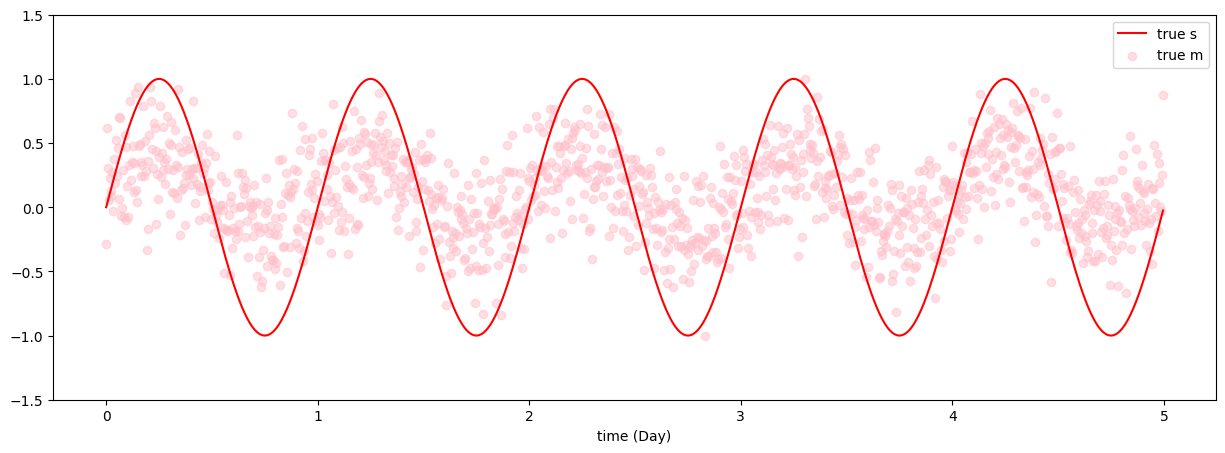

In [7]:
#testing Kalman framework
P_prime=0.25
M=1

T=24*5 ; dt=0.1; timesteps=np.arange(0,T,dt)
s, m = sm_simulation(T=T, dt=dt, P=0, M=M, theta=0)

m_rescaled = 2 * (m - np.min(m)) / (np.max(m) - np.min(m)) - 1

#PLOT 1
plt.figure(figsize=(15,5))
plt.plot(timesteps/24, np.sin(s), label='true s', color='red')
plt.scatter(timesteps/24, m_rescaled , color='pink', alpha=0.5, label='true m')
plt.xlabel('time (Day)')
plt.ylim(-1.5,1.5)

plt.legend();

### $\text{brand new start}$

In [11]:
import numpy as np
from tqdm import tqdm

np.random.seed(200)
N = 100
T = 24*20
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

mean_period = 23.5
std_period = 0.2

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 1     # measurement noise
alpha = 0.1     

# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((N, duration))
var_post = np.zeros((N, duration))
m_hat = np.zeros((N, duration))
G = np.zeros((N, duration))

# === SCN filter init ===
phase_history = np.zeros((N, duration))
psi = np.zeros(duration)
r = np.zeros(duration)

# natural frequencies
omega = np.random.normal(
    loc=2 * np.pi / mean_period,
    scale=(2 * np.pi / mean_period**2) * std_period,
    size=N
)



# intrinsic noise
kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

y_bar_history = np.zeros((N, duration))
H_history = np.zeros((N, duration))

# === Main loop ===
for t in tqdm(range(duration), desc="simulating", ncols=80):

    if t == 0:
        phases = np.random.vonmises(0, kappa=1, size=N)
        var_prior[:, t] = init_cov + var_p
    else:
        var_prior[:, t] = var_post[:, t-1] + var_p

    phase_history[:, t] = phases

    # order parameter
    order_param = np.mean(np.exp(1j * phases))
    r[t] = np.abs(order_param)
    psi[t] = np.angle(order_param)

    if t >= duration:
        break

    m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)

    H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
    H_history[:, t] = H

    sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
    G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

    gap = (m[t] - m_hat[:, t])

    var_post[:, t] = (1 - G[:, t] * H) * var_prior[:, t]

    # === Vectorized phase update ===
    phases += omega * dt + xi[:, t] + G[:, t] * gap
    # wrap phases into (-pi, pi]
    phases = (phases + np.pi) % (2 * np.pi) - np.pi


np.savez('EKF2_NC.npz', omega=omega, init_phases=phase_history[:,0], xi=xi, phase_history=phase_history)

simulating: 100%|████████████████████████| 4800/4800 [00:00<00:00, 32721.40it/s]


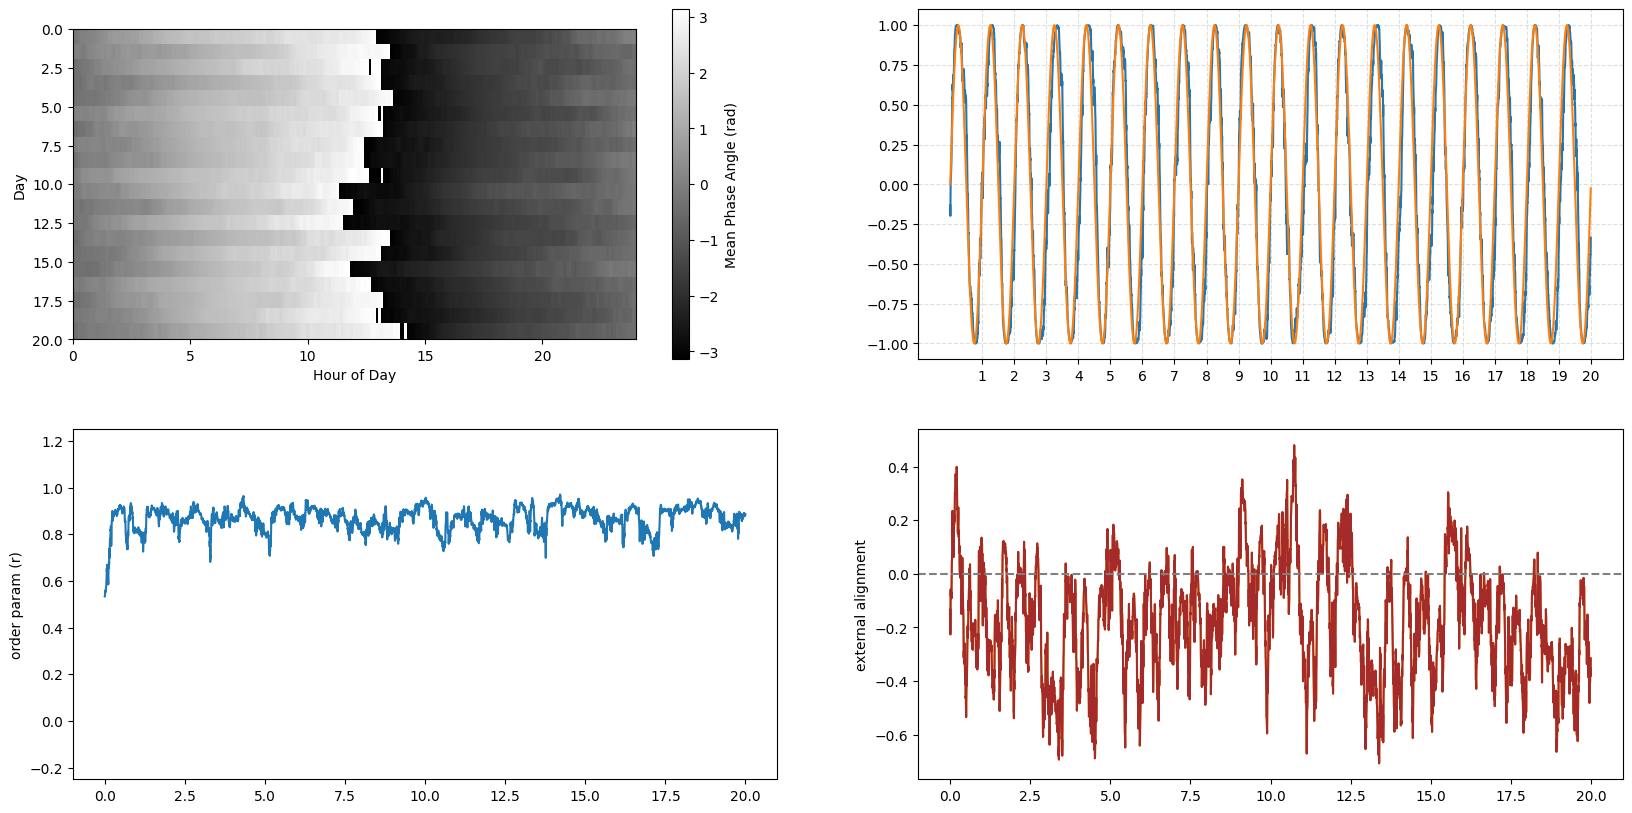

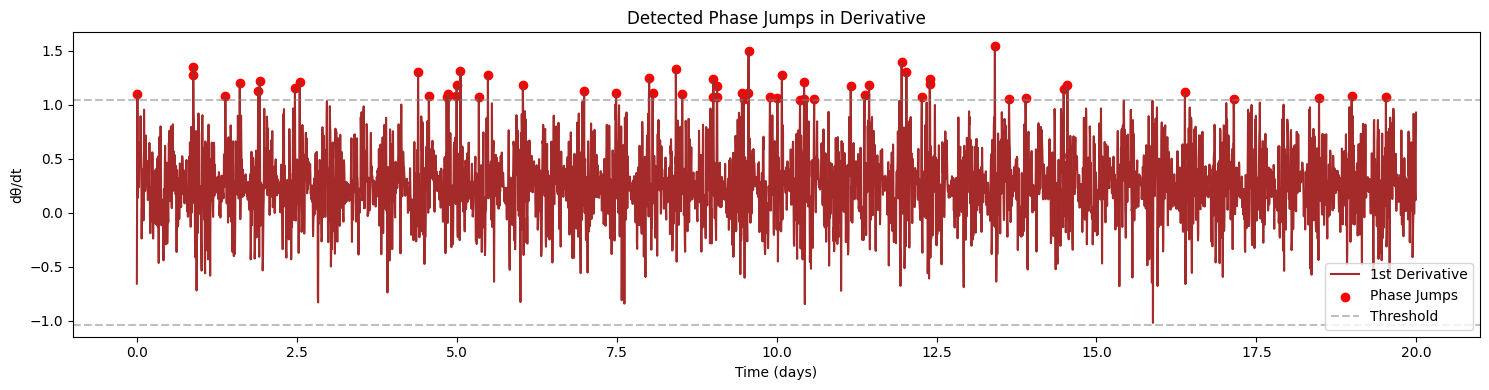

final instability: -0.0026 rad/hr, diff1_ratio: -0.0059
phase-locking loss: 0.2185 rad, 0.0348 Days, 0.8345 hrs
implausibility: 58, threshold=1


In [12]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

num_days = int(T / 24)
steps_per_day = int(24 / dt)
psi_2d = psi[:].reshape(num_days, steps_per_day)

im=axs[0,0].imshow(
    psi_2d,
    aspect=0.66,
    origin='lower',
    extent=[0, 24, 0, num_days],
    cmap='grey',  # or any other colormap 
    interpolation= 'none'  # or 'none'
)

axs[0,0].invert_yaxis()
axs[0,0].set_xlabel('Hour of Day')
axs[0,0].set_ylabel('Day')
cbar = fig.colorbar(im, ax=axs[0,0], label='Mean Phase Angle (rad)')

axs[0,1].plot(timesteps/24, np.sin(psi))
axs[0,1].plot(timesteps/24, np.sin(s))
axs[0,1].set_xticks(range(1,num_days+1))
axs[0,1].grid(True, linestyle='--', alpha=0.4)


axs[1,0].plot(timesteps/24,r)
axs[1,0].set_ylabel('order param (r)')
axs[1,0].set_ylim(-0.25,1.25)


angular_diff = np.angle(np.exp(1j * (psi - s))) 
axs[1,1].plot(timesteps/24, angular_diff, color='orange') 
axs[1,1].plot(timesteps/24, np.unwrap(psi) - np.unwrap(s), color='brown') 
axs[1,1].set_ylabel('external alignment')
#axs[1,1].set_ylim(-np.pi, np.pi)
axs[1,1].axhline(y=0, color='gray', linestyle='--')


plt.show()

fig, axs, peaks = count_phase_jumps(timesteps,  psi, summary=False)
display(fig)


phase_diff = np.unwrap(psi) - np.unwrap(s)
diff1 = np.diff(phase_diff) / dt   # rate of change per hour
total_diff1  = np.std(diff1)
window = int(duration * 0.2)
recent_diff1  = np.mean(diff1[-window:])

stability_ratio_diff = recent_diff1 / total_diff1 if total_diff1 > 0 else np.nan



locking_score = np.mean(np.abs(angular_diff))
locking_in_days = (locking_score/(2*np.pi)) # in the unit of days

n_artifact = len(peaks)

print(f"final instability: {recent_diff1:.4f} rad/hr, diff1_ratio: {stability_ratio_diff:.4f}")
print(f'phase-locking loss: {locking_score:.4f} rad, {locking_in_days:.4f} Days, {locking_in_days * 24 :.4f} hrs')
print(f'implausibility: {n_artifact}, threshold=1');

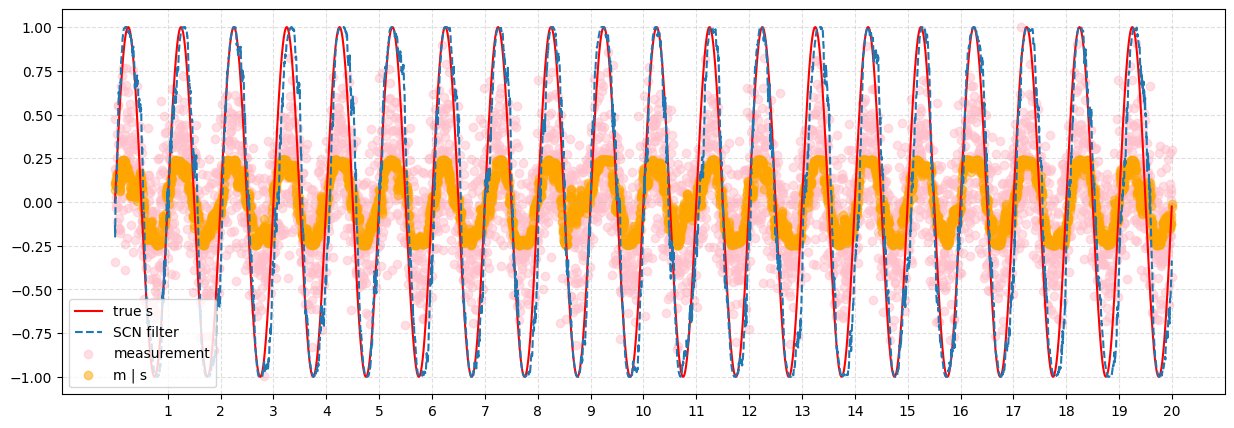

In [13]:
num_days = int(T / 24)


m_scaled = (m-np.mean(m)) * (2/(np.max(m)-np.min(m)))
m_hat_scaled = (m_hat[5] - np.mean(m_hat[5])) * (2/(np.max(m)-np.min(m)))
plt.figure(figsize=(15,5))
plt.plot(timesteps/24, np.sin(s), color='red', label='true s')
plt.plot(timesteps/24, np.sin(psi), label='SCN filter', linestyle='--')
plt.scatter(timesteps/24, m_scaled, alpha=0.5, color='pink', label='measurement')
plt.scatter(timesteps/24, m_hat_scaled, color='orange', alpha=0.5, label='m | s')
#plt.plot(timesteps/24, G[5,:], color='green', label='gain')
plt.xticks(range(1,num_days+1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show();

In [2]:
pip install git+https://github.com/bantin/jPCA

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/bantin/jPCA to /private/var/folders/3t/j8jp86293gb_vcbssnjln66h0000gp/T/pip-req-build-l45rs0p3
  Running command git clone --filter=blob:none --quiet https://github.com/bantin/jPCA /private/var/folders/3t/j8jp86293gb_vcbssnjln66h0000gp/T/pip-req-build-l45rs0p3
  Resolved https://github.com/bantin/jPCA to commit 3f8be9fa32a43a7b3090695c9e671f52f02878ac
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'jPCA' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'jPCA'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for jPCA: filename=jPCA-0.0.1-

### coupled

In [14]:
data=np.load('EKF2_NC.npz')

np.random.seed(200)
N = 100
T = 24*20
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

mean_period = 23.5
std_period = 0.2

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 1     # measurement noise
alpha = 0.1    

# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((N, duration))
var_post = np.zeros((N, duration))
m_hat = np.zeros((N, duration))
G = np.zeros((N, duration))

# === SCN filter init ===
phase_history = np.zeros((N, duration))
psi = np.zeros(duration)
r = np.zeros(duration)

# natural frequencies
omega = data['omega']

K_matrix = np.random.uniform(0, 6, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)

# intrinsic noise
kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = data['xi']

y_bar_history = np.zeros((N, duration))
H_history = np.zeros((N, duration))

# === Main loop ===
for t in tqdm(range(duration), desc="simulating", ncols=80):

    if t == 0:
        phases = np.random.vonmises(0, kappa=1, size=N)
        var_prior[:, t] = init_cov + var_p
    else:
        var_prior[:, t] = var_post[:, t-1] + var_p

    phase_history[:, t] = phases

    # order parameter
    order_param = np.mean(np.exp(1j * phases))
    r[t] = np.abs(order_param)
    psi[t] = np.angle(order_param)

    if t >= duration:
        break
        
    # ===================== Linear observation update (light input) ========================

    m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)

    H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
    H_history[:, t] = H

    sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
    G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

    gap = (m[t] - m_hat[:, t])

    var_post[:, t] = (1 - G[:, t] * H) * var_prior[:, t]

    sin_p = np.sin(phases)
    cos_p = np.cos(phases)
    sum_sin = K_matrix @ sin_p
    sum_cos = K_matrix @ cos_p
    coupling_sum = cos_p * sum_sin - sin_p * sum_cos

    # === Vectorized phase update ===
    phases += omega * dt + xi[:, t] + G[:, t] * gap + (1/N) * coupling_sum
    phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating: 100%|█████████████████████████| 4800/4800 [00:00<00:00, 8024.78it/s]


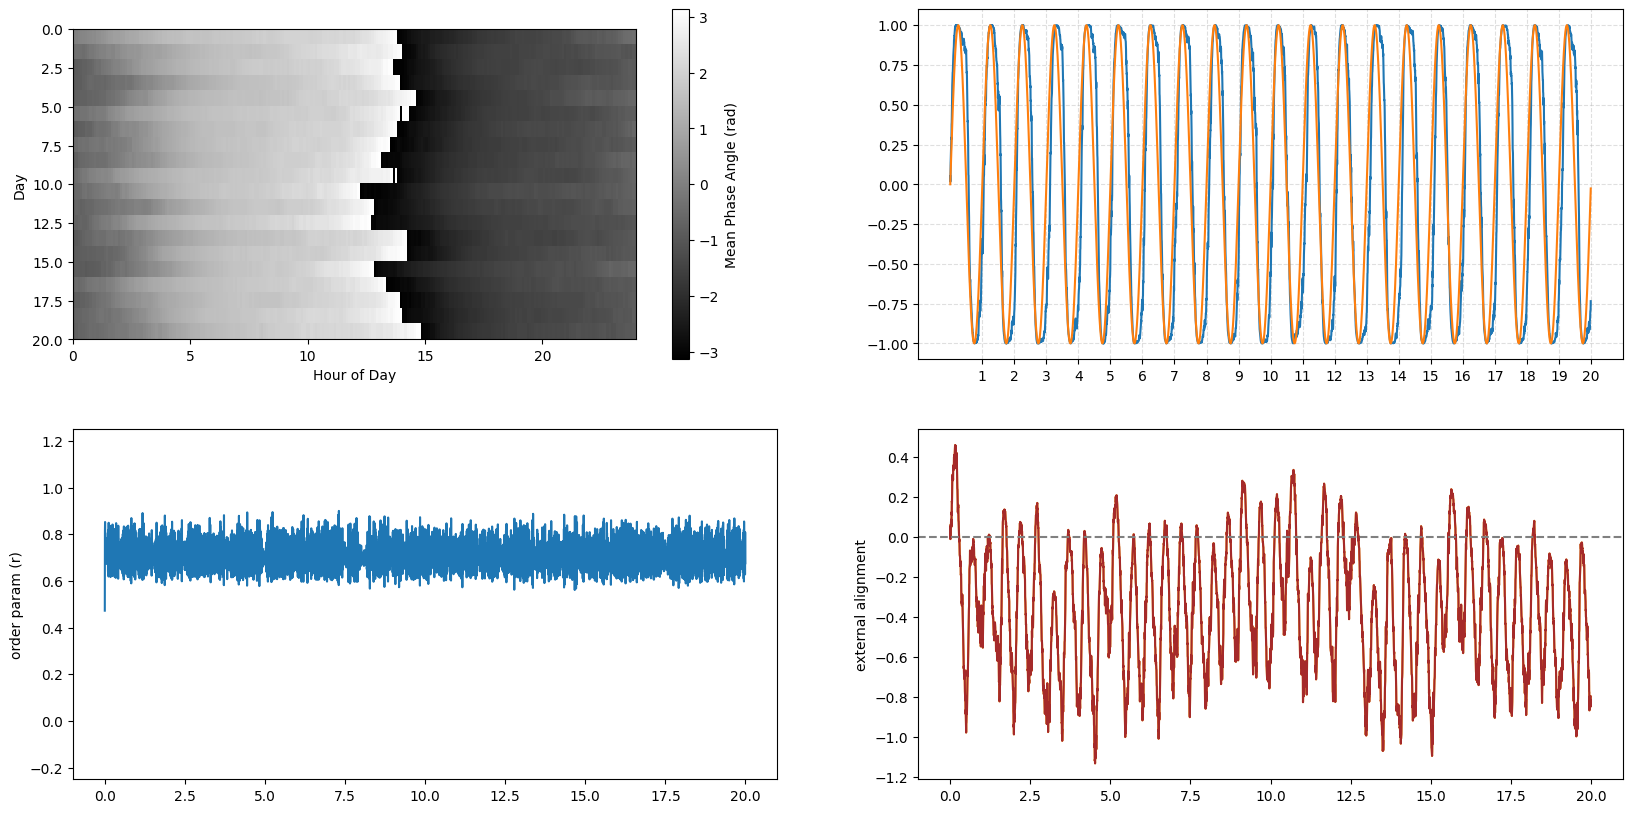

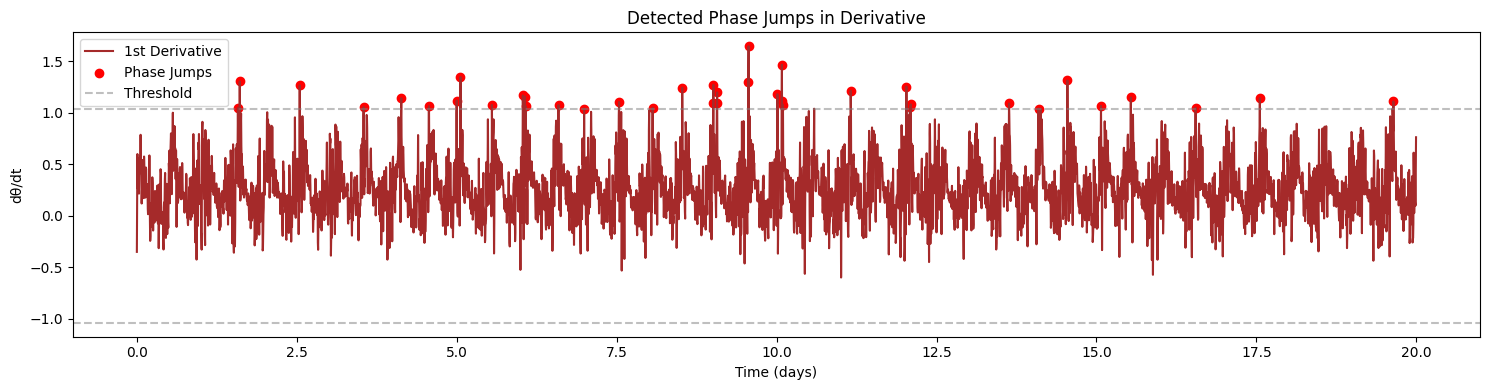

final instability: -0.0032 rad/hr, diff1_ratio: -0.0088
locking loss: 0.3883 rad, 0.0618 Days
infidelity: 39, threshold=1


In [15]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

num_days = int(T / 24)
steps_per_day = int(24 / dt)
psi_2d = psi[:].reshape(num_days, steps_per_day)

im=axs[0,0].imshow(
    psi_2d,
    aspect=0.66,
    origin='lower',
    extent=[0, 24, 0, num_days],
    cmap='grey',  # or any other colormap 
    interpolation= 'none'  # or 'none'
)

axs[0,0].invert_yaxis()
axs[0,0].set_xlabel('Hour of Day')
axs[0,0].set_ylabel('Day')
cbar = fig.colorbar(im, ax=axs[0,0], label='Mean Phase Angle (rad)')

axs[0,1].plot(timesteps/24, np.sin(psi))
axs[0,1].plot(timesteps/24, np.sin(s))
axs[0,1].set_xticks(range(1,num_days+1))
axs[0,1].grid(True, linestyle='--', alpha=0.4)


axs[1,0].plot(timesteps/24,r)
axs[1,0].set_ylabel('order param (r)')
axs[1,0].set_ylim(-0.25,1.25)


angular_diff = np.angle(np.exp(1j * (psi - s))) 
axs[1,1].plot(timesteps/24, angular_diff, color='orange') 
axs[1,1].plot(timesteps/24, np.unwrap(psi) - np.unwrap(s), color='brown') 
axs[1,1].set_ylabel('external alignment')
#axs[1,1].set_ylim(-np.pi, np.pi)
axs[1,1].axhline(y=0, color='gray', linestyle='--')


plt.show()

fig, axs, peaks = count_phase_jumps(timesteps, psi=psi , summary=False)
display(fig)


phase_diff = np.unwrap(psi) - np.unwrap(s)
diff1 = np.diff(phase_diff) / dt   # rate of change per hour
total_diff1  = np.std(diff1)
window = int(duration * 0.2)
recent_diff1  = np.mean(diff1[-window:])

stability_ratio_diff = recent_diff1 / total_diff1 if total_diff1 > 0 else np.nan



locking_score = np.mean(np.abs(angular_diff))
locking_in_hrs = (locking_score/(2*np.pi)) # in the unit of days

n_artifact = len(peaks)

print(f"final instability: {recent_diff1:.4f} rad/hr, diff1_ratio: {stability_ratio_diff:.4f}")
print(f'locking loss: {locking_score:.4f} rad, {locking_in_hrs:.4f} Days')
print(f'infidelity: {n_artifact}, threshold=1');

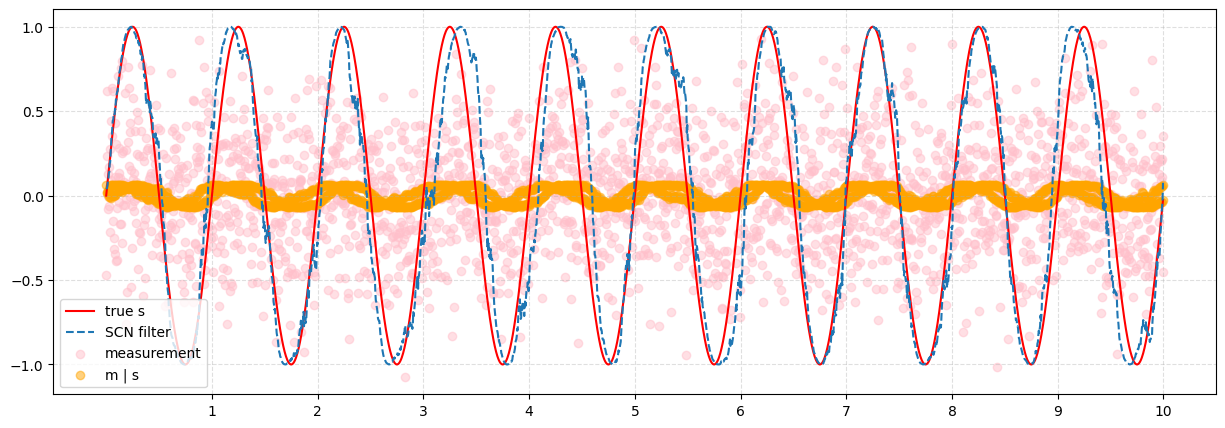

In [258]:
num_days = int(T / 24)


m_scaled = (m-np.mean(m)) * (2/(np.max(m)-np.min(m)))
m_hat_scaled = (m_hat[5] - np.mean(m_hat[5])) * (2/(np.max(m)-np.min(m)))
plt.figure(figsize=(15,5))
plt.plot(timesteps/24, np.sin(s), color='red', label='true s')
plt.plot(timesteps/24, np.sin(psi), label='SCN filter', linestyle='--')
plt.scatter(timesteps/24, m_scaled, alpha=0.5, color='pink', label='measurement')
plt.scatter(timesteps/24, m_hat_scaled, color='orange', alpha=0.5, label='m | s')
#plt.plot(timesteps/24, G[5,:], color='green', label='gain')
plt.xticks(range(1,num_days+1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show();

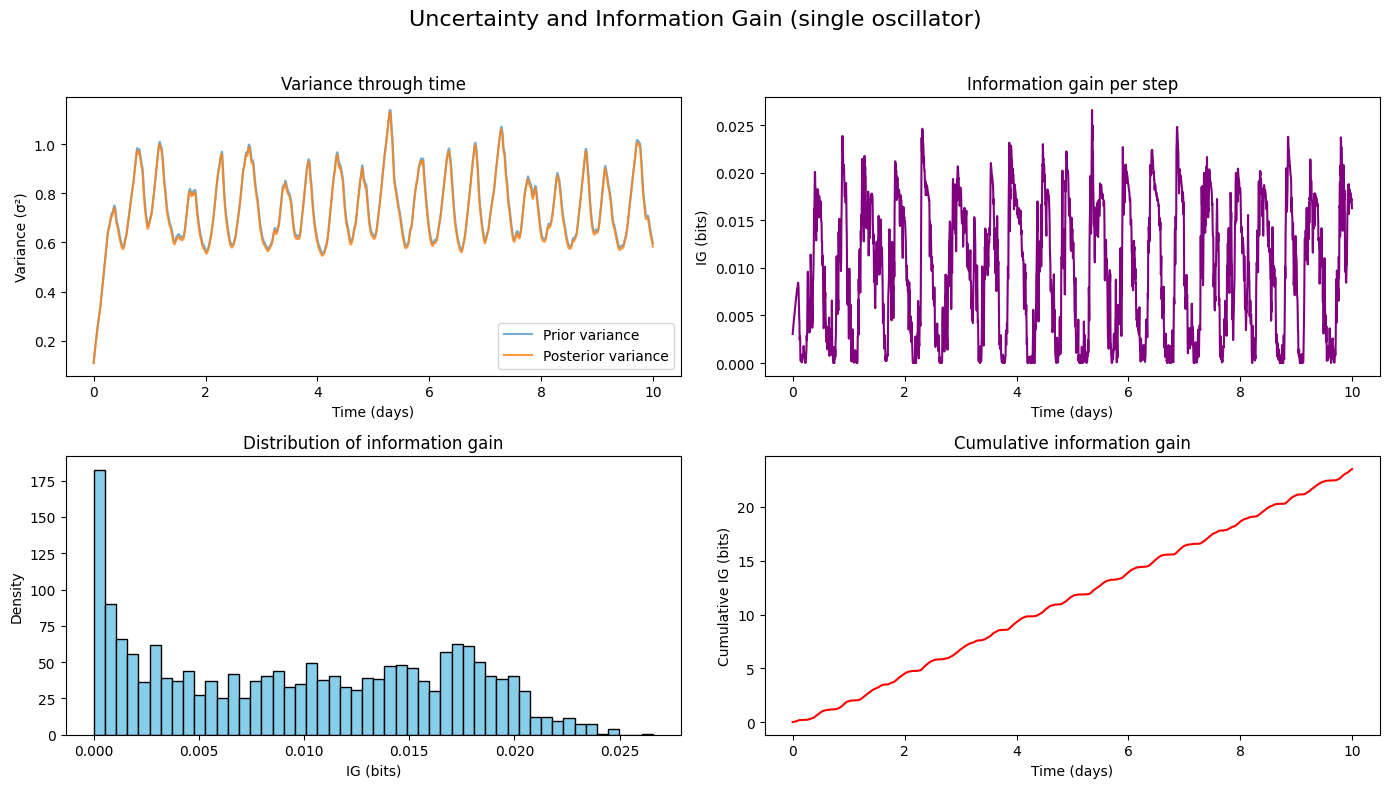

In [145]:
var_prior_i = var_prior[0, :]
var_post_i = var_post[0, :]

# --- Info gain (light vs total update) ---
IG_t = 0.5 * np.log2((var_prior_i + 1e-12) / (var_post_i + 1e-12))

# --- Cumulative info gain ---
cum_IG = np.cumsum(IG_t)

# === Plotting ===
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Uncertainty and Information Gain (single oscillator)", fontsize=16)

# (0,0) Posterior variance
axs[0,0].plot(timesteps/24, var_prior_i, label="Prior variance", alpha=0.6)
axs[0,0].plot(timesteps/24, var_post_i, label="Posterior variance", alpha=0.8)
axs[0,0].set_title("Variance through time")
axs[0,0].set_xlabel("Time (days)")
axs[0,0].set_ylabel("Variance (σ²)")
axs[0,0].legend()

# (0,1) Info gain per step
axs[0,1].plot(timesteps/24, IG_t, color="purple")
axs[0,1].set_title("Information gain per step")
axs[0,1].set_xlabel("Time (days)")
axs[0,1].set_ylabel("IG (bits)")

# (1,0) Histogram of IG
axs[1,0].hist(IG_t, bins=50, color="skyblue", edgecolor="k", density=True)
axs[1,0].set_title("Distribution of information gain")
axs[1,0].set_xlabel("IG (bits)")
axs[1,0].set_ylabel("Density")

# (1,1) Cumulative info
axs[1,1].plot(timesteps/24, cum_IG, color="red")
axs[1,1].set_title("Cumulative information gain")
axs[1,1].set_xlabel("Time (days)")
axs[1,1].set_ylabel("Cumulative IG (bits)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Freerun

In [ ]:
data=np.load('EKF2_NC.npz')

np.random.seed(200)
N = 100
T = 24*20
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

mean_period = 23.5
std_period = 0.2

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 1     # measurement noise
alpha = 0.1    

# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((N, duration))
var_post = np.zeros((N, duration))
m_hat = np.zeros((N, duration))
G = np.zeros((N, duration))

# === SCN filter init ===
phase_history = np.zeros((N, duration))
psi = np.zeros(duration)
r = np.zeros(duration)

# natural frequencies
omega = data['omega']

K_matrix = np.random.uniform(0, 6, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)

# intrinsic noise
kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = data['xi']

y_bar_history = np.zeros((N, duration))
H_history = np.zeros((N, duration))

# === Main loop ===
for t in tqdm(range(duration), desc="simulating", ncols=80):

    if t == 0:
        phases = np.random.vonmises(0, kappa=1, size=N)
        var_prior[:, t] = init_cov + var_p
    else:
        var_prior[:, t] = var_post[:, t-1] + var_p

    phase_history[:, t] = phases

    # order parameter
    order_param = np.mean(np.exp(1j * phases))
    r[t] = np.abs(order_param)
    psi[t] = np.angle(order_param)

    if t >= duration:
        break
        
    # ===================== Linear observation update (light input) ========================

    m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)

    H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
    H_history[:, t] = H

    sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
    G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

    gap = (m[t] - m_hat[:, t])

    var_post[:, t] = (1 - G[:, t] * H) * var_prior[:, t]

    sin_p = np.sin(phases)
    cos_p = np.cos(phases)
    sum_sin = K_matrix @ sin_p
    sum_cos = K_matrix @ cos_p
    coupling_sum = cos_p * sum_sin - sin_p * sum_cos

    # === Vectorized phase update ===
    phases += omega * dt + xi[:, t] + (1/N) * coupling_sum
    phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating: 100%|█████████████████████████| 4800/4800 [00:02<00:00, 2332.72it/s]


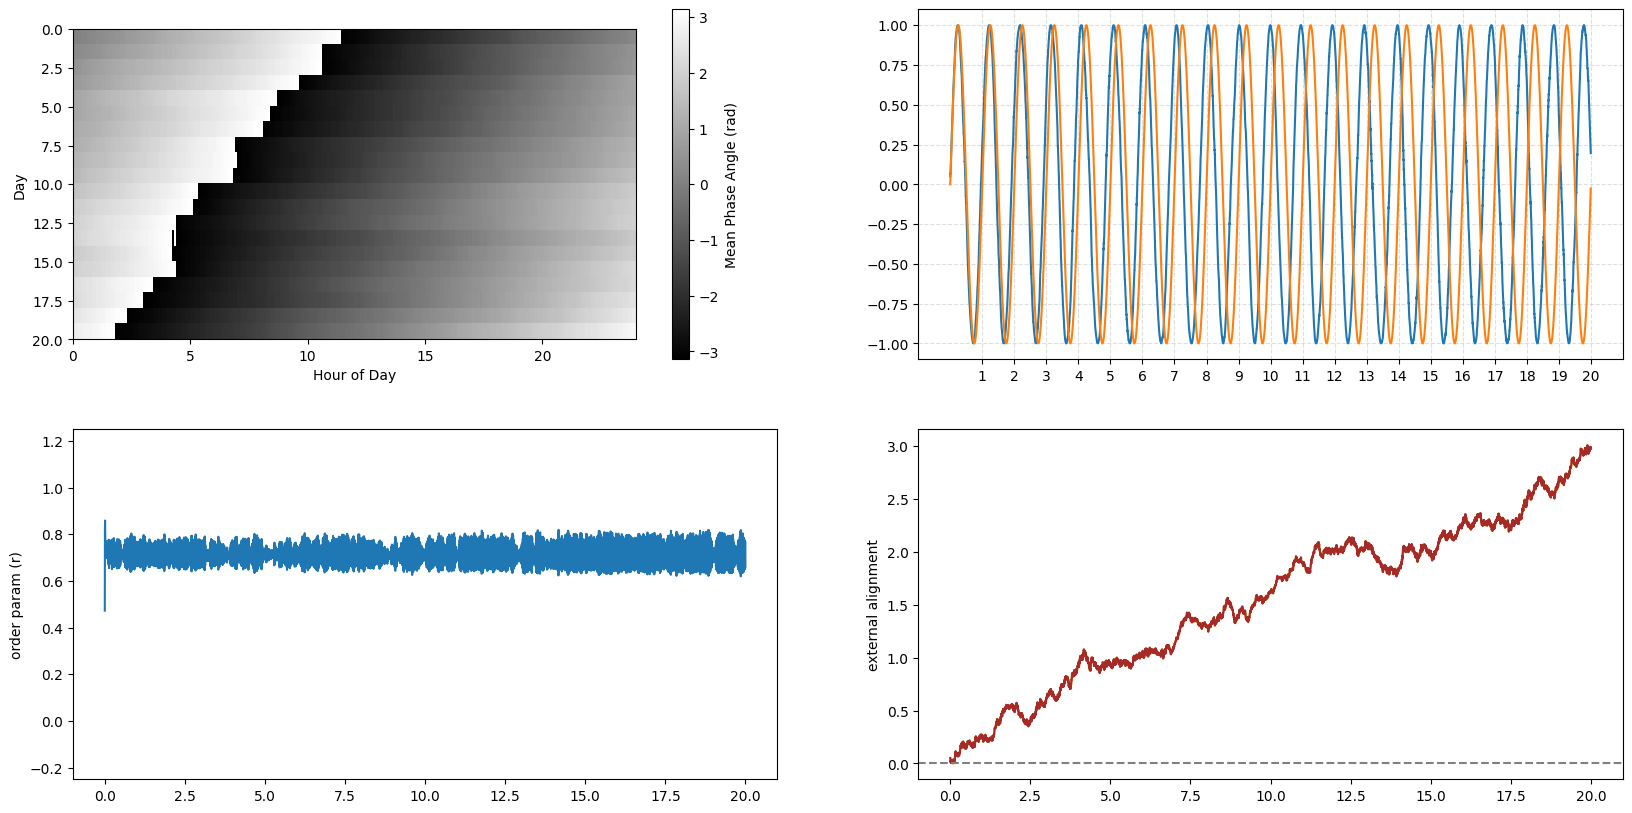

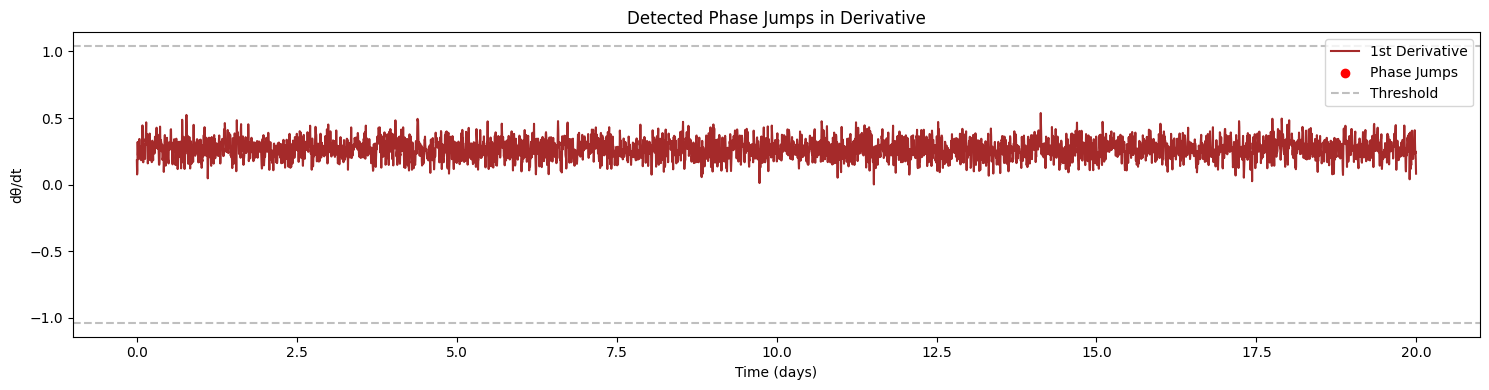

final instability: 0.0076 rad/hr, diff1_ratio: 0.0442
locking loss: 1.5372 rad, 0.2446 Days
infidelity: 0, threshold=1


In [9]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

num_days = int(T / 24)
steps_per_day = int(24 / dt)
psi_2d = psi[:].reshape(num_days, steps_per_day)

im=axs[0,0].imshow(
    psi_2d,
    aspect=0.66,
    origin='lower',
    extent=[0, 24, 0, num_days],
    cmap='grey',  # or any other colormap 
    interpolation= 'none'  # or 'none'
)

axs[0,0].invert_yaxis()
axs[0,0].set_xlabel('Hour of Day')
axs[0,0].set_ylabel('Day')
cbar = fig.colorbar(im, ax=axs[0,0], label='Mean Phase Angle (rad)')

axs[0,1].plot(timesteps/24, np.sin(psi))
axs[0,1].plot(timesteps/24, np.sin(s))
axs[0,1].set_xticks(range(1,num_days+1))
axs[0,1].grid(True, linestyle='--', alpha=0.4)


axs[1,0].plot(timesteps/24,r)
axs[1,0].set_ylabel('order param (r)')
axs[1,0].set_ylim(-0.25,1.25)


angular_diff = np.angle(np.exp(1j * (psi - s))) 
axs[1,1].plot(timesteps/24, angular_diff, color='orange') 
axs[1,1].plot(timesteps/24, np.unwrap(psi) - np.unwrap(s), color='brown') 
axs[1,1].set_ylabel('external alignment')
#axs[1,1].set_ylim(-np.pi, np.pi)
axs[1,1].axhline(y=0, color='gray', linestyle='--')


plt.show()

fig, axs, peaks = count_phase_jumps(timesteps, psi=psi , summary=False)
display(fig)


phase_diff = np.unwrap(psi) - np.unwrap(s)
diff1 = np.diff(phase_diff) / dt   # rate of change per hour
total_diff1  = np.std(diff1)
window = int(duration * 0.2)
recent_diff1  = np.mean(diff1[-window:])

stability_ratio_diff = recent_diff1 / total_diff1 if total_diff1 > 0 else np.nan



locking_score = np.mean(np.abs(angular_diff))
locking_in_hrs = (locking_score/(2*np.pi)) # in the unit of days

n_artifact = len(peaks)

print(f"final instability: {recent_diff1:.4f} rad/hr, diff1_ratio: {stability_ratio_diff:.4f}")
print(f'locking loss: {locking_score:.4f} rad, {locking_in_hrs:.4f} Days')
print(f'infidelity: {n_artifact}, threshold=1');

## $\text{Main Effect}$

### $\text{1. K sweep}$

#### big scale 1~20

In [278]:
data=np.load('EKF2_NC.npz')
np.random.seed(200)

acc = np.arange(0, 20, 0.1)

N = 100
T = 24*10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

mean_period = 23.5
std_period = 0.2

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 5     # measurement noise
alpha = 0.1     

# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((len(acc), N, duration))
var_post = np.zeros((len(acc), N, duration))
m_hat = np.zeros((len(acc), N, duration))
G = np.zeros((len(acc), N, duration))

# === SCN filter init ===
phase_history = np.zeros((len(acc), N, duration))
psi = np.zeros((len(acc), duration))
r = np.zeros((len(acc), duration))

# natural frequencies
omega = data['omega']

xi=data['xi']


for n, k in enumerate(acc):

    K_matrix = np.random.uniform(0, k, (N, N))
    K_matrix = (K_matrix + K_matrix.T) / 2
    np.fill_diagonal(K_matrix, 0)

    # === Main loop ===
    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t == 0:
            phases = np.random.vonmises(0, kappa=1, size=N)
            var_prior[n, :, t] = init_cov + var_p
        else:
            var_prior[n, :, t] = var_post[n, :, t-1] + var_p

        phase_history[n, :, t] = phases

        # order parameter
        order_param = np.mean(np.exp(1j * phases))
        r[n, t] = np.abs(order_param)
        psi[n, t] = np.angle(order_param)

        if t > duration:
            break
            
        # ===================== Linear observation update (light input) ========================

        m_hat[n, :, t] = sigmoid(np.sin(phases + omega), theta=theta)

        H = alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]) * np.cos(phases + omega)

        sigma2_obs_eff = ((alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]))**2) * (M**2)
        G[n, :, t] = (H * var_prior[n, :, t]) / (H * var_prior[n, :, t] * H + sigma2_obs_eff + 1e-8)

        gap = (m[t] - m_hat[n, :, t])

        var_post[n, :, t] = (1 - G[n, :, t] * H) * var_prior[n, :, t]

        phase_diff = phases[None, :] - phases[:, None]           # broadcast differences φ_j - φ_i
        coupling_sum = np.sum(K_matrix * np.sin(phase_diff), axis=1)  # same as sin(phases[j] - phases[i])

        # Update
        phases += omega * dt + xi[:, t] + G[n, :, t] * gap + (1/N) * coupling_sum

        phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating200/200: 100%|██████████████████| 2400/2400 [00:00<00:00, 8936.72it/s]


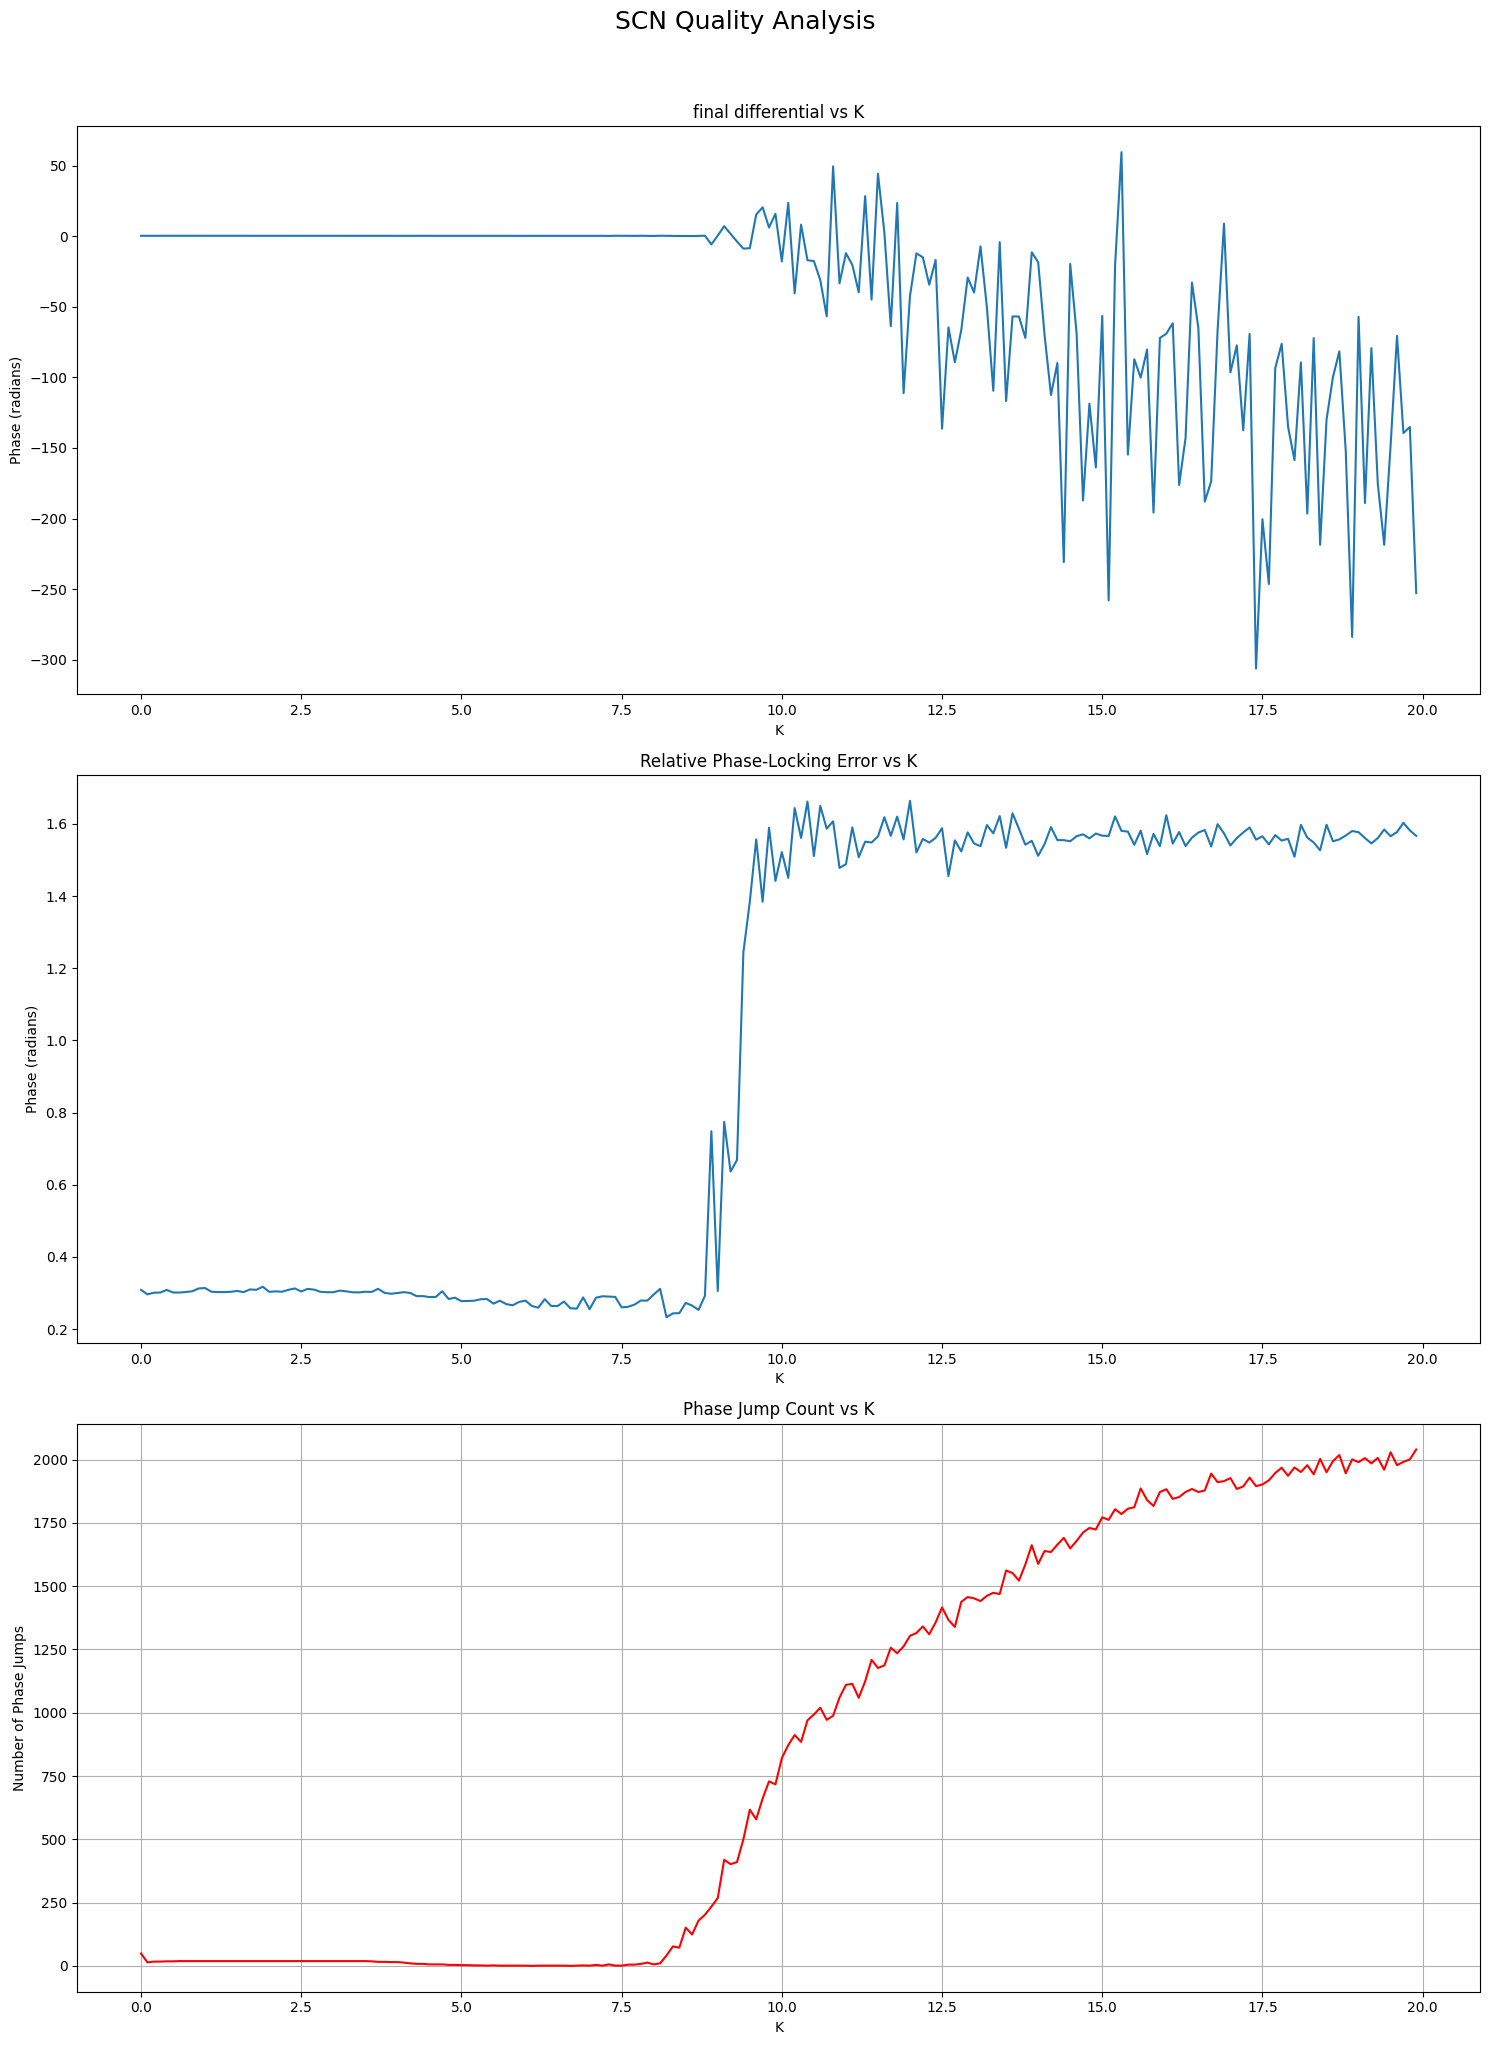

In [280]:
fig, axs = plt.subplots(3, 1, figsize=(15,20))
fig.suptitle("SCN Quality Analysis", fontsize=18, y=1.02)

total_diff = np.zeros(len(acc))

for n in range(len(acc)):
    window = int(duration * 0.2)
    phase_diff = np.unwrap(psi[n]) - np.unwrap(s)
    total_diff[n] = np.mean(phase_diff[-window:])

axs[0].plot(acc, total_diff)
axs[0].set_title("final differential vs K")
axs[0].set_xlabel("K")
axs[0].set_ylabel("Phase (radians)")
#axs[0].axhline(y=0, color='gray', linestyle='--')



angular_diff = np.zeros((len(acc), duration))
locking_score= np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n]=np.angle(np.exp(1j * (psi[n] - s))) 
    locking_score[n] = np.mean(np.abs(angular_diff[n]))

axs[1].plot(acc, locking_score)
axs[1].set_title("Relative Phase-Locking Error vs K")
axs[1].set_xlabel("K")
axs[1].set_ylabel("Phase (radians)")
#axs[1].axhline(y=0, color='gray', linestyle='--')




angular_diff = np.zeros((len(acc), duration))
n_spikes=np.zeros(len(acc))

for n in range(len(acc)):
    color = cmap(norm(acc[n]))
    angular_diff[n] = np.angle(np.exp(1j * (psi[n] - s)))

for n in range(len(acc)):
    _ , _, spikes = count_phase_jumps(timesteps, angular_diff[n])
    n_spikes[n] = len(spikes)


axs[2].plot(acc, n_spikes, color='red')
axs[2].set_title("Phase Jump Count vs K")
axs[2].set_xlabel("K")
axs[2].set_ylabel("Number of Phase Jumps")
plt.grid(True)

plt.tight_layout()

plt.show();

#### micro:1-9

In [314]:
np.random.seed(200)

acc = np.arange(0, 8, 0.1)

N = 100
T = 24*10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

mean_period = 23.5
std_period = 0.2

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 5     # measurement noise
alpha = 0.1     

# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((len(acc), N, duration))
var_post = np.zeros((len(acc), N, duration))
m_hat = np.zeros((len(acc), N, duration))
G = np.zeros((len(acc), N, duration))

# === SCN filter init ===
phase_history = np.zeros((len(acc), N, duration))
psi = np.zeros((len(acc), duration))
r = np.zeros((len(acc), duration))

# natural frequencies
omega = data['omega']

xi=data['xi']


for n, k in enumerate(acc):

    K_matrix = np.random.uniform(0, k, (N, N))
    K_matrix = (K_matrix + K_matrix.T) / 2
    np.fill_diagonal(K_matrix, 0)

    # === Main loop ===
    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t == 0:
            phases = np.random.vonmises(0, kappa=1, size=N)
            var_prior[n, :, t] = init_cov + var_p
        else:
            var_prior[n, :, t] = var_post[n, :, t-1] + var_p

        phase_history[n, :, t] = phases

        # order parameter
        order_param = np.mean(np.exp(1j * phases))
        r[n, t] = np.abs(order_param)
        psi[n, t] = np.angle(order_param)

        if t > duration:
            break
            
        # ===================== Linear observation update (light input) ========================

        m_hat[n, :, t] = sigmoid(np.sin(phases + omega), theta=theta)

        H = alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]) * np.cos(phases + omega)

        sigma2_obs_eff = ((alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]))**2) * (M**2)
        G[n, :, t] = (H * var_prior[n, :, t]) / (H * var_prior[n, :, t] * H + sigma2_obs_eff + 1e-8)

        gap = (m[t] - m_hat[n, :, t])

        var_post[n, :, t] = (1 - G[n, :, t] * H) * var_prior[n, :, t]

        phase_diff = phases[None, :] - phases[:, None]           # broadcast differences φ_j - φ_i
        coupling_sum = np.sum(K_matrix * np.sin(phase_diff), axis=1)  # same as sin(phases[j] - phases[i])

        # Update
        phases += omega * dt + xi[:, t] + G[n, :, t] * gap + (1/N) * coupling_sum

        phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating80/80: 100%|████████████████████| 2400/2400 [00:00<00:00, 8906.10it/s]


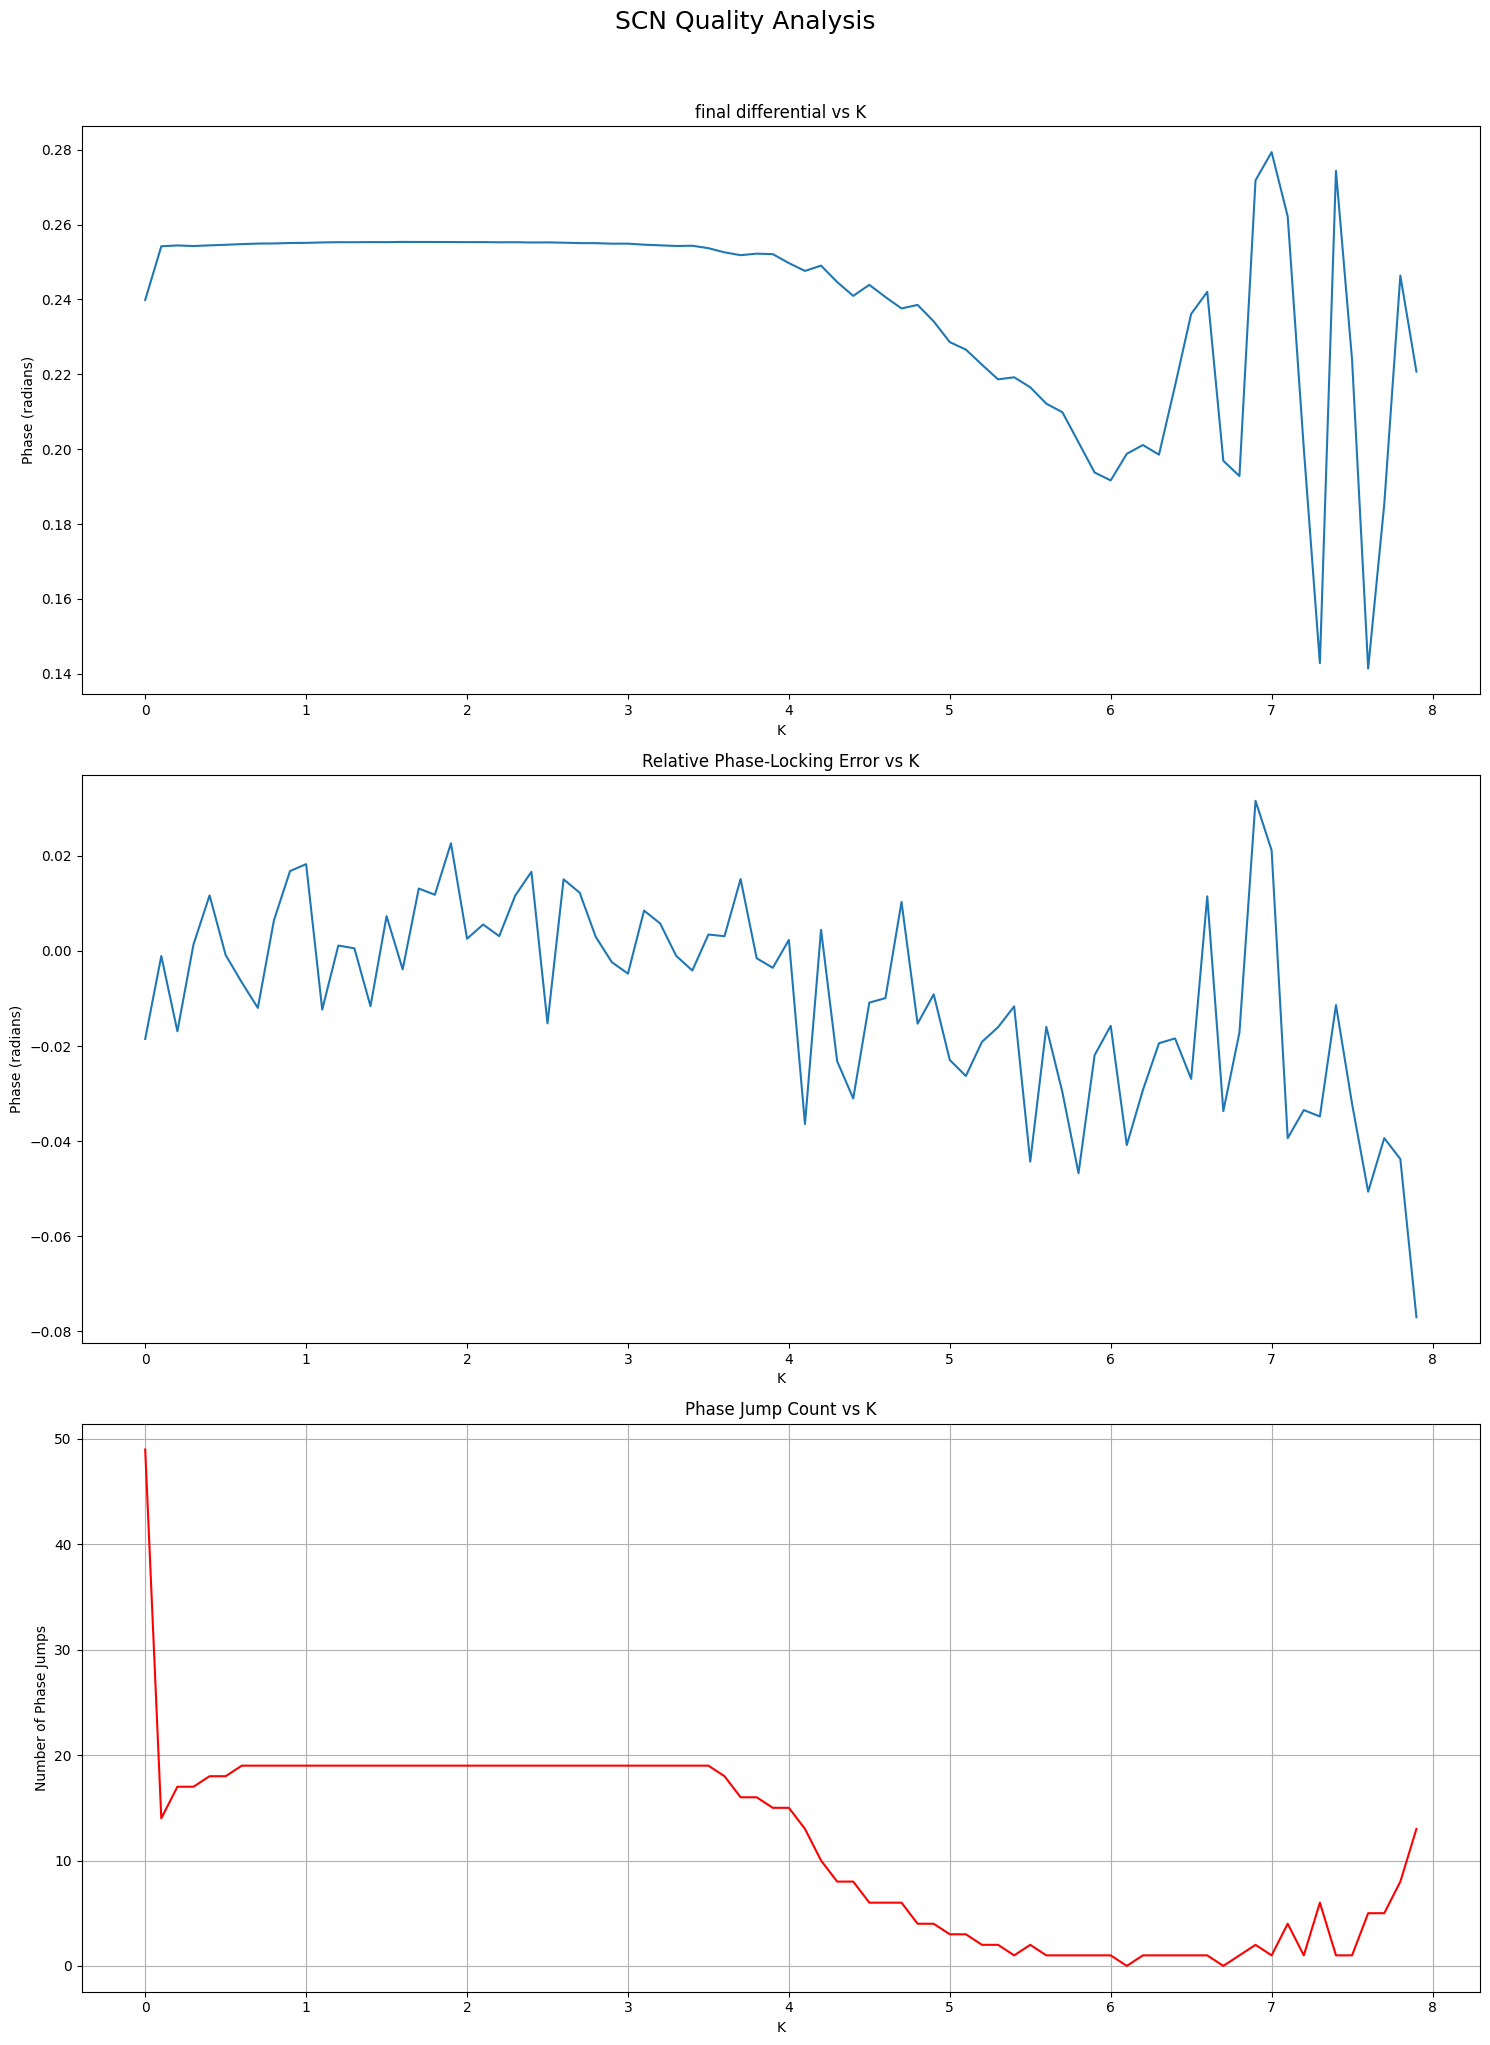

In [316]:
fig, axs = plt.subplots(3, 1, figsize=(15,20))
fig.suptitle("SCN Quality Analysis", fontsize=18, y=1.02)

total_diff = np.zeros(len(acc))

for n in range(len(acc)):
    window = int(duration * 0.2)
    phase_diff = np.unwrap(psi[n]) - np.unwrap(s)
    total_diff[n] = np.mean(phase_diff[-window:])

axs[0].plot(acc, total_diff)
axs[0].set_title("final differential vs K")
axs[0].set_xlabel("K")
axs[0].set_ylabel("Phase (radians)")
#axs[0].axhline(y=0, color='gray', linestyle='--')



angular_diff = np.zeros((len(acc), duration))
locking_score= np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n]=np.angle(np.exp(1j * (psi[n] - s))) 
    locking_score[n] = np.mean(angular_diff[n])

axs[1].plot(acc, locking_score)
axs[1].set_title("Relative Phase-Locking Error vs K")
axs[1].set_xlabel("K")
axs[1].set_ylabel("Phase (radians)")
#axs[1].axhline(y=0, color='gray', linestyle='--')




angular_diff = np.zeros((len(acc), duration))
n_spikes=np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n] = np.angle(np.exp(1j * (psi[n] - s)))

for n in range(len(acc)):
    _ , _, spikes = count_phase_jumps(timesteps, angular_diff[n])
    n_spikes[n] = len(spikes)


axs[2].plot(acc, n_spikes, color='red')
axs[2].set_title("Phase Jump Count vs K")
axs[2].set_xlabel("K")
axs[2].set_ylabel("Number of Phase Jumps")
plt.grid(True)

plt.tight_layout()

plt.show();

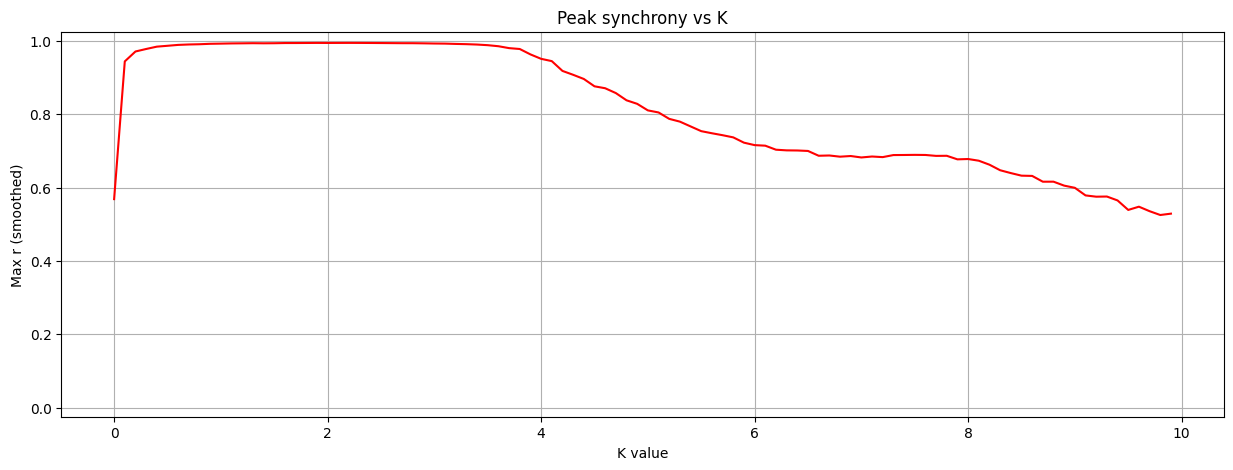

In [284]:
window = 5

mask = (acc >= 0) & (acc <= 10000)

r_max = np.zeros(len(acc))
for n in range(len(acc)):
    if mask[n]:
        color = cmap(norm(acc[n]))
        
        # smooth r[n]
        r_smooth = uniform_filter1d(r[n], size=window)
        
        # compute max after smoothing
        r_max[n] = np.mean(r_smooth)
        
# === summary plot of max r vs noise ===

plt.figure(figsize=(15,5))
plt.plot(acc, r_max, color='red')
plt.xlabel('K value')
plt.ylabel("Max r (smoothed)")
plt.title("Peak synchrony vs K")
plt.ylim(-0.025, 1.025)
plt.grid(True)
plt.show()

#print(r_max)

### $\text{2. mean period sweep}$

In [290]:
np.random.seed(200)

acc = np.arange(14, 33.5, 0.1)

N = 100
T = 24*10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 5     # measurement noise
alpha = 0.1     


# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((len(acc), N, duration))
var_post = np.zeros((len(acc), N, duration))
m_hat = np.zeros((len(acc), N, duration))
G = np.zeros((len(acc), N, duration))

# === SCN filter init ===
phase_history = np.zeros((len(acc), N, duration))
psi = np.zeros((len(acc), duration))
r = np.zeros((len(acc), duration))


K_matrix = np.random.uniform(0, 6, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)


for n, mu in enumerate(acc):

    mean_period = mu
    std_period = 0.2

    # natural frequencies
    omega = np.random.normal(
        loc=2 * np.pi / mean_period,
        scale=(2 * np.pi / mean_period**2) * std_period,
        size=N
    )

    # intrinsic noise
    xi = data['xi']


    # === Main loop ===
    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t == 0:
            phases = np.random.vonmises(0, kappa=1, size=N)
            var_prior[n, :, t] = init_cov + var_p
        else:
            var_prior[n, :, t] = var_post[n, :, t-1] + var_p

        phase_history[n, :, t] = phases

        # order parameter
        order_param = np.mean(np.exp(1j * phases))
        r[n, t] = np.abs(order_param)
        psi[n, t] = np.angle(order_param)

        if t > duration:
            break
            
        # ===================== Linear observation update (light input) ========================

        m_hat[n, :, t] = sigmoid(np.sin(phases + omega), theta=theta)

        H = alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]) * np.cos(phases + omega)

        sigma2_obs_eff = ((alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]))**2) * (M**2)
        G[n, :, t] = (H * var_prior[n, :, t]) / (H * var_prior[n, :, t] * H + sigma2_obs_eff + 1e-8)

        gap = (m[t] - m_hat[n, :, t])

        var_post[n, :, t] = (1 - G[n, :, t] * H) * var_prior[n, :, t]

        phase_diff = phases[None, :] - phases[:, None]           # broadcast differences φ_j - φ_i
        coupling_sum = np.sum(K_matrix * np.sin(phase_diff), axis=1)  # same as sin(phases[j] - phases[i])

        phases += omega * dt + xi[:, t] + G[n, :, t] * gap + (1/N) * coupling_sum

        # wrap phases into (-pi, pi]
        phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating195/195: 100%|█████████████████| 2400/2400 [00:00<00:00, 11834.73it/s]


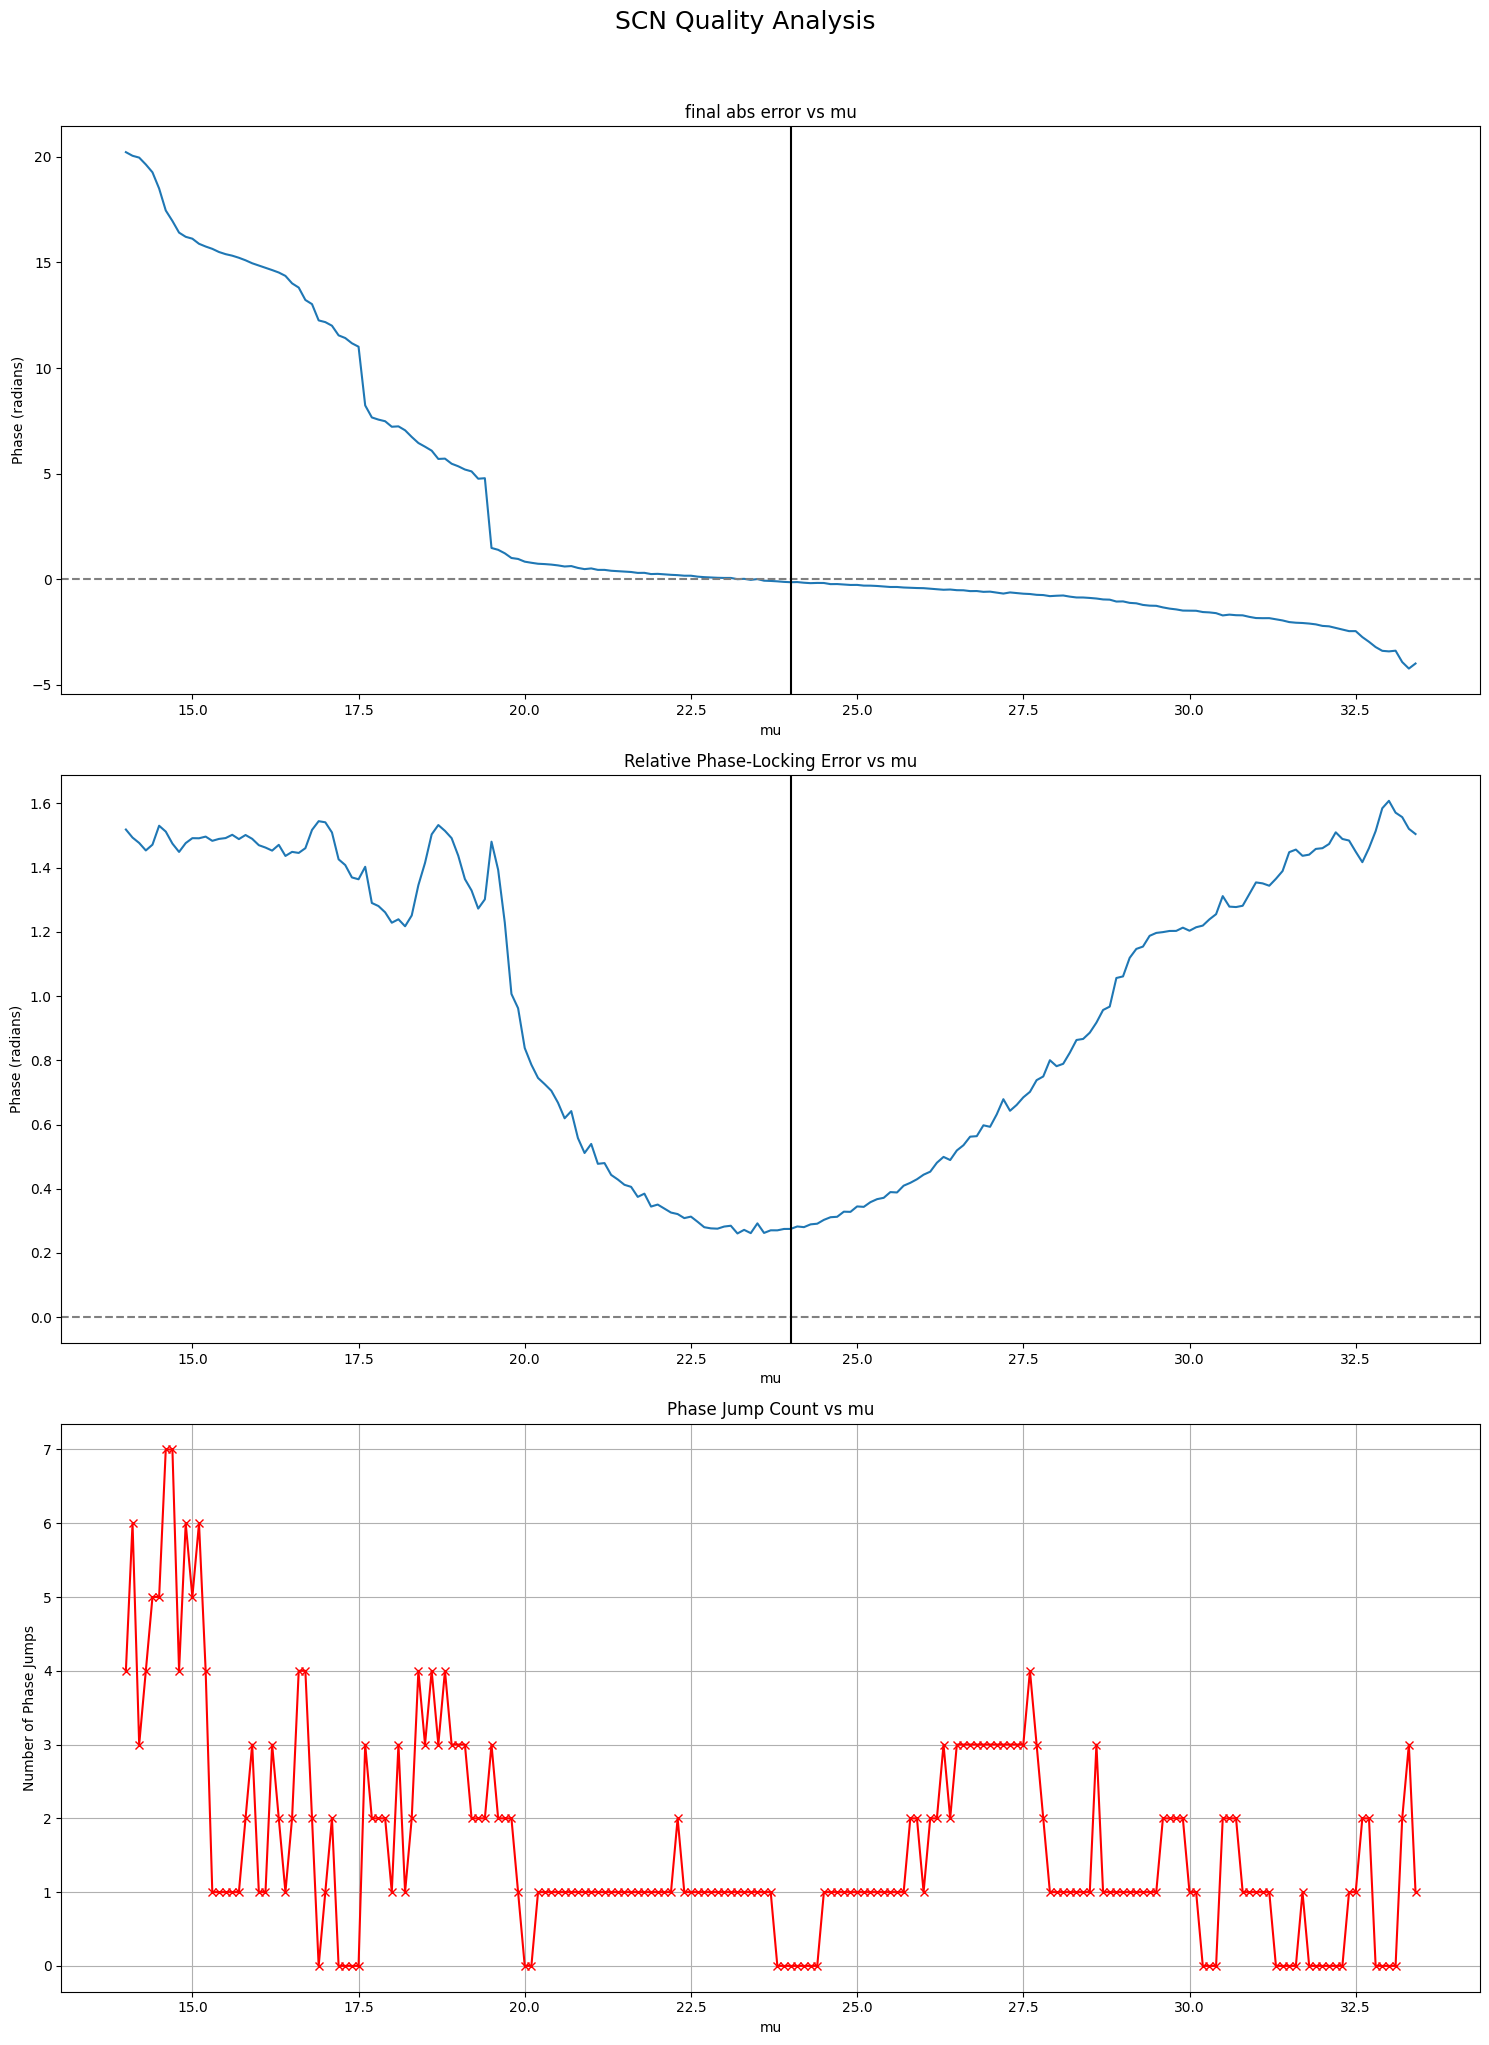

phase error min = 0.0028 at : [23.2]
locking error min = 0.2608 at: [23.2]
spike count min = 0.0000 at : [16.9 17.2 17.3 17.4 17.5 20.  20.1 23.8 23.9 24.  24.1 24.2 24.3 24.4
 30.2 30.3 30.4 31.3 31.4 31.5 31.6 31.8 31.9 32.  32.1 32.2 32.3 32.8
 32.9 33.  33.1]


In [305]:
fig, axs = plt.subplots(3, 1, figsize=(15,20))
fig.suptitle("SCN Quality Analysis", fontsize=18, y=1.02)

total_diff = np.zeros(len(acc))
recent_diff = np.zeros(len(acc))
stability_ratio_diff = np.zeros(len(acc))

for n in range(len(acc)):
    window = int(duration * 0.2)
    phase_diff = np.unwrap(psi[n]) - np.unwrap(s)
    total_diff[n] = np.mean( phase_diff )

axs[0].plot(acc, total_diff)
axs[0].set_title("final abs error vs mu")
axs[0].set_xlabel("mu")
axs[0].set_ylabel("Phase (radians)")
axs[0].axhline(y=0, color='gray', linestyle='--')
axs[0].axvline(x=24, color='black')


angular_diff = np.zeros((len(acc), duration))
locking_score= np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n]=np.angle(np.exp(1j * (psi[n] - s))) 
    locking_score[n] = np.mean(np.abs(angular_diff[n]))

axs[1].plot(acc, locking_score)
axs[1].set_title("Relative Phase-Locking Error vs mu")
axs[1].set_xlabel("mu")
axs[1].set_ylabel("Phase (radians)")
axs[1].axhline(y=0, color='gray', linestyle='--')
axs[1].axvline(x=24, color='black')



angular_diff = np.zeros((len(acc), duration))
n_spikes=np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n] = np.angle(np.exp(1j * (psi[n] - s)))

for n in range(len(acc)):
    _ , _, spikes = count_phase_jumps(timesteps, angular_diff[n])
    n_spikes[n] = len(spikes)


axs[2].plot(acc, n_spikes, color='red', marker='x')
axs[2].set_title("Phase Jump Count vs mu")
axs[2].set_xlabel("mu")
axs[2].set_ylabel("Number of Phase Jumps")
plt.grid(True)
plt.tight_layout()

plt.show()

# Tolerance for numerical equality (since floats aren't exact)
tol = 1e-8

min_total = np.min(np.abs(total_diff))
min_lock = np.min(np.abs(locking_score))
min_spikes = np.min(n_spikes)

idx_total = np.where(np.isclose(np.abs(total_diff), min_total, atol=tol))[0]
idx_lock = np.where(np.isclose(np.abs(locking_score), min_lock, atol=tol))[0]
idx_spikes = np.where(np.isclose(n_spikes, min_spikes, atol=tol))[0]

mu_min_error = acc[idx_total]
mu_min_locking = acc[idx_lock]
mu_min_spikes = acc[idx_spikes]

print(f"phase error min = {min_total:.4f} at : {mu_min_error}")
print(f"locking error min = {min_lock:.4f} at: {mu_min_locking}")
print(f"spike count min = {min_spikes:.4f} at : {mu_min_spikes}")


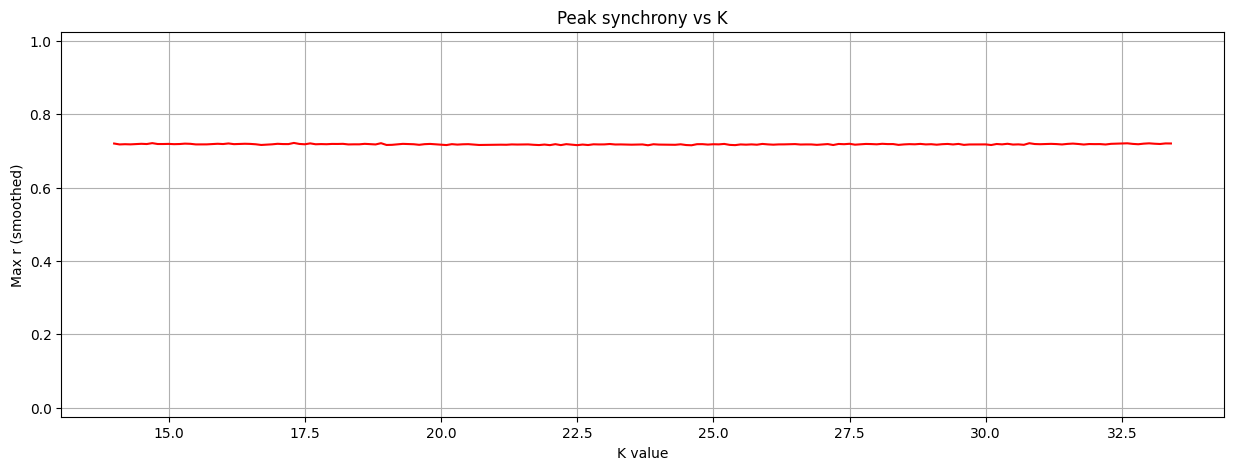

In [304]:

window = 1

mask = (acc >= 0) & (acc <= 10000)

r_max = np.zeros(len(acc))
for n in range(len(acc)):
    if mask[n]:
        color = cmap(norm(acc[n]))
        
        # smooth r[n]
        r_smooth = uniform_filter1d(r[n], size=window)
        
        # compute max after smoothing
        r_max[n] = np.mean(r_smooth)
        
# === summary plot of max r vs noise ===

plt.figure(figsize=(15,5))
plt.plot(acc, r_max, color='red')
plt.xlabel('K value')
plt.ylabel("Max r (smoothed)")
plt.title("Peak synchrony vs K")
plt.ylim(-0.025, 1.025)
plt.grid(True)
plt.show()

#print(r_max)

### $\text{Sweep sigma}$

In [317]:
np.random.seed(200)

acc = np.arange(0, 24.5, 0.5)

N = 100
T = 24*10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

init_cov = 0.1
P_prime = 0.1   # process noise for phase
P = 0
M = 5     # measurement noise
alpha = 0.1     

# === Simulate light signal ===
s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

# === Variances ===
var_p = np.ones(N) * P_prime**2
var_m = M**2

theta = 0
var_prior = np.zeros((len(acc), N, duration))
var_post = np.zeros((len(acc), N, duration))
m_hat = np.zeros((len(acc), N, duration))
G = np.zeros((len(acc), N, duration))

# === SCN filter init ===
phase_history = np.zeros((len(acc), N, duration))
psi = np.zeros((len(acc), duration))
r = np.zeros((len(acc), duration))


K_matrix = np.random.uniform(0, 6, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)


for n, spread in enumerate(acc):

    mean_period = 23.5
    std_period = spread 

    # natural frequencies
    omega = np.random.normal(
        loc=2 * np.pi / mean_period,
        scale=(2 * np.pi / mean_period**2) * std_period,
        size=N
    )

    # intrinsic noise
    kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
    xi = data['xi']

    # === Main loop ===
    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t == 0:
            phases = np.random.vonmises(0, kappa=1, size=N)
            var_prior[n, :, t] = init_cov + var_p
        else:
            var_prior[n, :, t] = var_post[n, :, t-1] + var_p

        phase_history[n, :, t] = phases

        # order parameter
        order_param = np.mean(np.exp(1j * phases))
        r[n, t] = np.abs(order_param)
        psi[n, t] = np.angle(order_param)

        if t > duration:
            break
            
        # ===================== Linear observation update (light input) ========================

        m_hat[n, :, t] = sigmoid(np.sin(phases + omega), theta=theta)

        H = alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]) * np.cos(phases + omega)

        sigma2_obs_eff = ((alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]))**2) * (M**2)
        G[n, :, t] = (H * var_prior[n, :, t]) / (H * var_prior[n, :, t] * H + sigma2_obs_eff + 1e-8)

        gap = (m[t] - m_hat[n, :, t])
        linear_correction = G[n, :, t] * gap

        var_post[n, :, t] = (1 - G[n, :, t] * H) * var_prior[n, :, t]

        phase_diff = phases[None, :] - phases[:, None]           # broadcast differences φ_j - φ_i
        coupling_sum = np.sum(K_matrix * np.sin(phase_diff), axis=1)  # same as sin(phases[j] - phases[i])

        phases += omega * dt + xi[:, t] + G[n, :, t] * gap + (1/N) * coupling_sum

        # wrap phases into (-pi, pi]
        phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating49/49: 100%|███████████████████| 2400/2400 [00:00<00:00, 11250.27it/s]


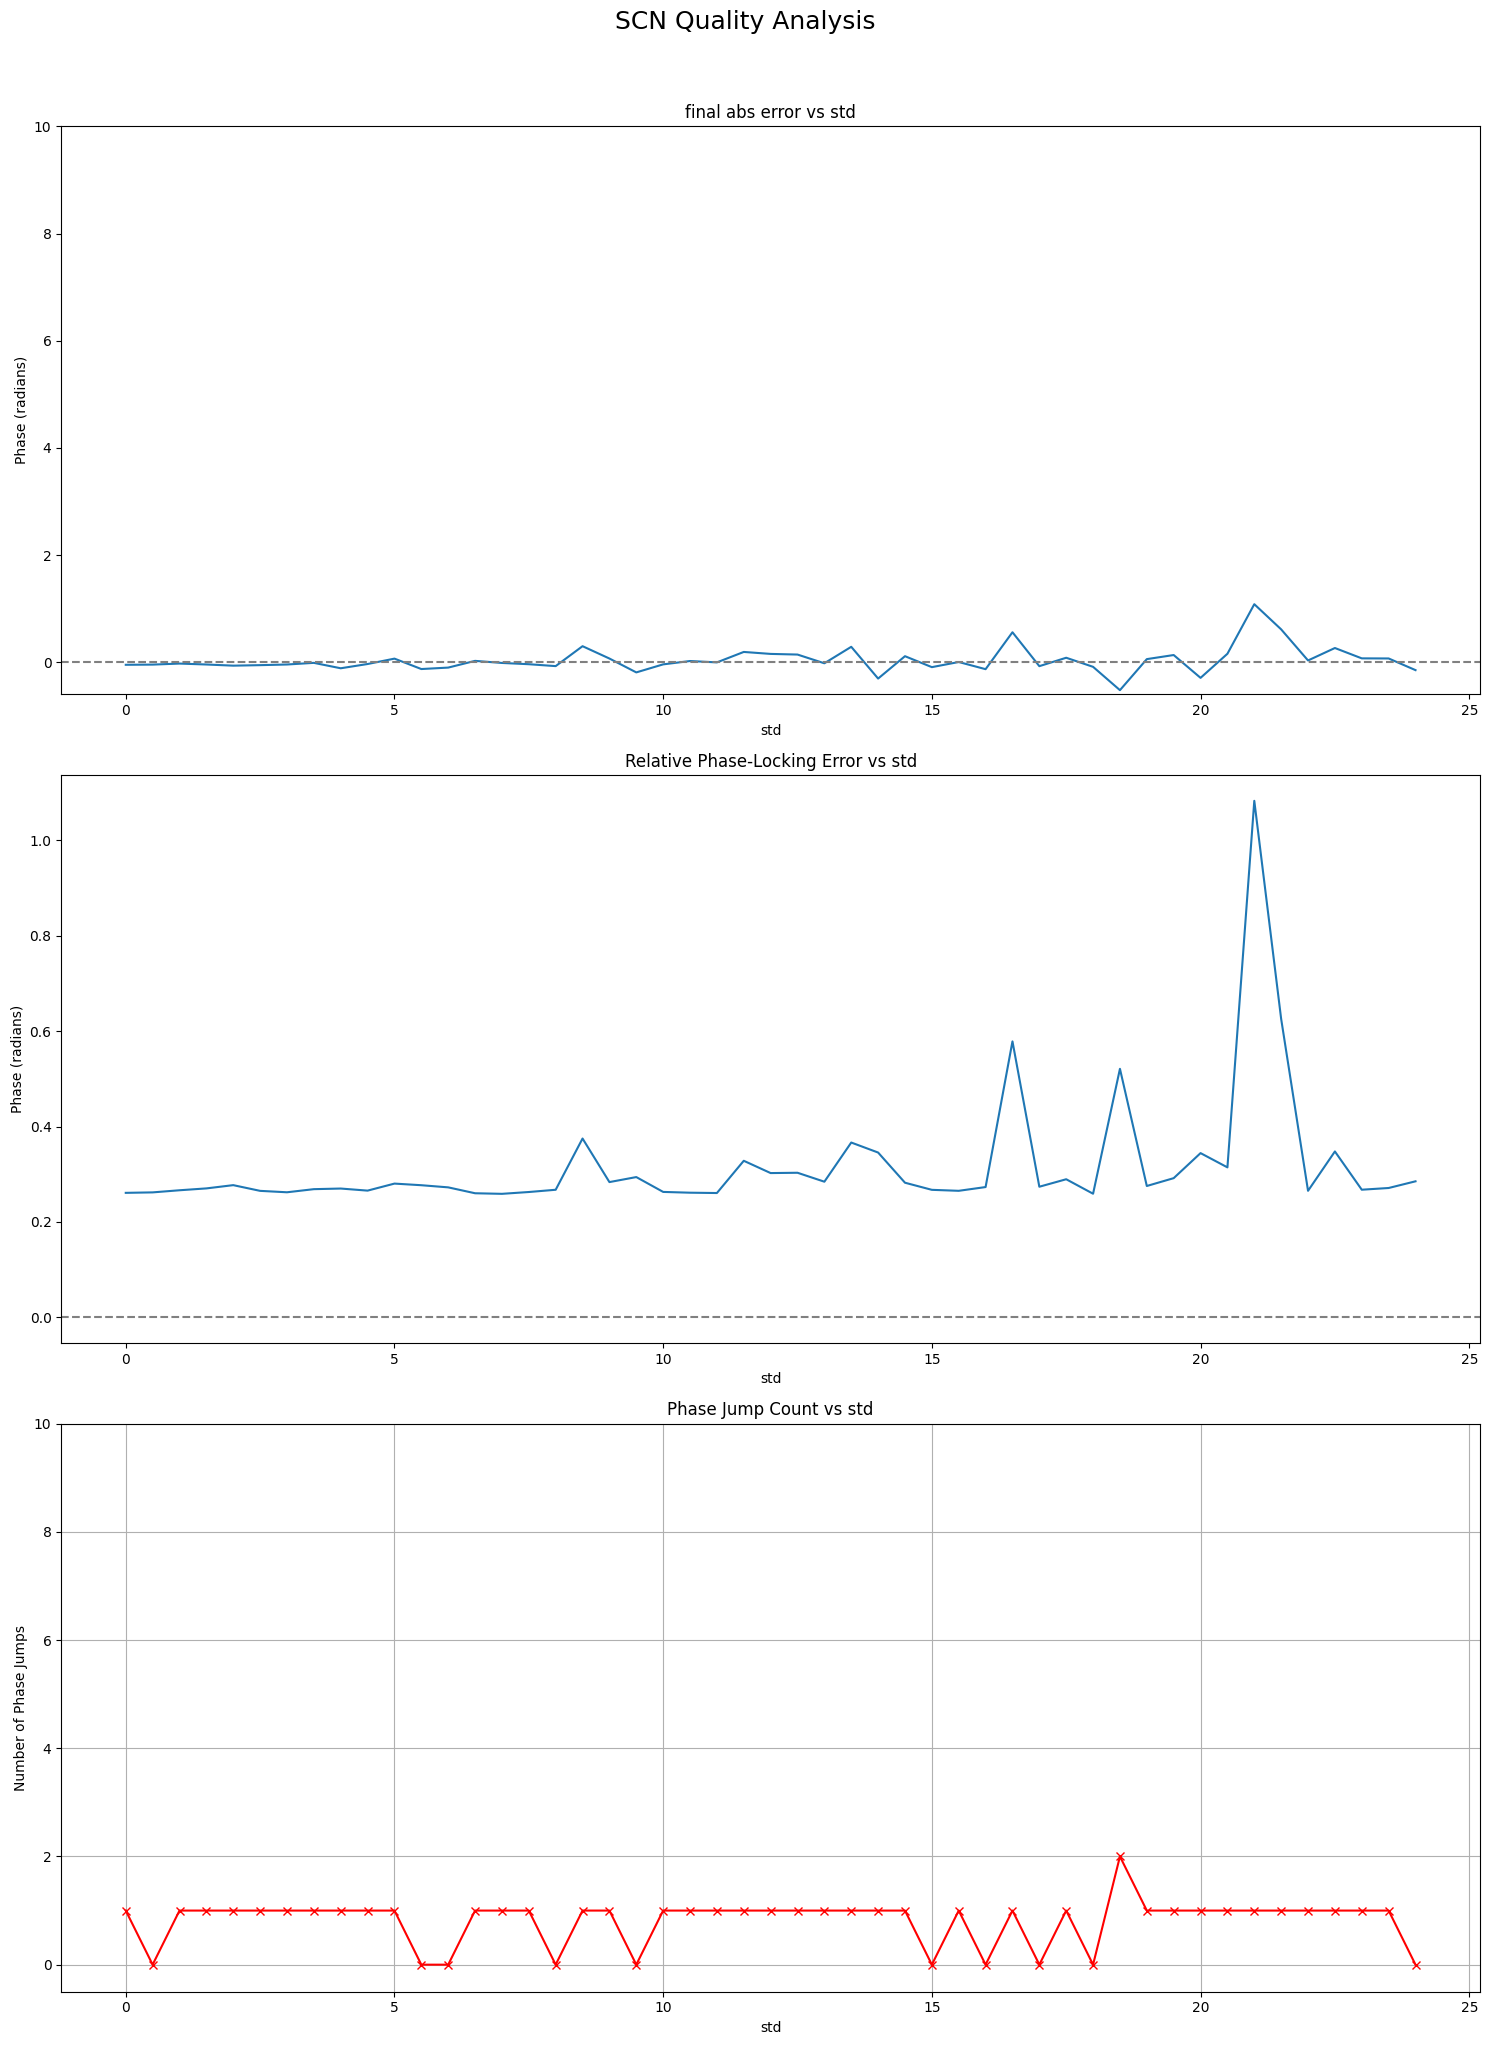

phase error min = 0.0028 at : [11.]
locking error min = 0.2588 at: [7.]
spike count min = 0.0000 at : [ 0.5  5.5  6.   8.   9.5 15.  16.  17.  18.  24. ]


In [320]:
fig, axs = plt.subplots(3, 1, figsize=(15,20))
fig.suptitle("SCN Quality Analysis", fontsize=18, y=1.02)

total_diff = np.zeros(len(acc))
recent_diff = np.zeros(len(acc))
stability_ratio_diff = np.zeros(len(acc))

for n in range(len(acc)):
    window = int(duration * 0.2)
    phase_diff = np.unwrap(psi[n]) - np.unwrap(s)
    total_diff[n] = np.mean( phase_diff )

axs[0].plot(acc, total_diff)
axs[0].set_title("final abs error vs std")
axs[0].set_xlabel("std")
axs[0].set_ylabel("Phase (radians)")
axs[0].set_ylim(-0.6, 10)
axs[0].axhline(y=0, color='gray', linestyle='--')


angular_diff = np.zeros((len(acc), duration))
locking_score= np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n]=np.angle(np.exp(1j * (psi[n] - s))) 
    locking_score[n] = np.mean(np.abs(angular_diff[n]))

axs[1].plot(acc, locking_score)
axs[1].set_title("Relative Phase-Locking Error vs std")
axs[1].set_xlabel("std")
axs[1].set_ylabel("Phase (radians)")
axs[1].axhline(y=0, color='gray', linestyle='--')



angular_diff = np.zeros((len(acc), duration))
n_spikes=np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n] = np.angle(np.exp(1j * (psi[n] - s)))

for n in range(len(acc)):
    _ , _, spikes = count_phase_jumps(timesteps, angular_diff[n])
    n_spikes[n] = len(spikes)


axs[2].plot(acc, n_spikes, color='red', marker='x')
axs[2].set_title("Phase Jump Count vs std")
axs[2].set_xlabel("std")
axs[2].set_ylabel("Number of Phase Jumps")
axs[2].set_ylim(-0.5, 10)
plt.grid(True)
plt.tight_layout()

plt.show()

# Tolerance for numerical equality (since floats aren't exact)
tol = 1e-8

min_total = np.min(np.abs(total_diff))
min_lock = np.min(np.abs(locking_score))
min_spikes = np.min(n_spikes)

idx_total = np.where(np.isclose(np.abs(total_diff), min_total, atol=tol))[0]
idx_lock = np.where(np.isclose(np.abs(locking_score), min_lock, atol=tol))[0]
idx_spikes = np.where(np.isclose(n_spikes, min_spikes, atol=tol))[0]

mu_min_error = acc[idx_total]
mu_min_locking = acc[idx_lock]
mu_min_spikes = acc[idx_spikes]

print(f"phase error min = {min_total:.4f} at : {mu_min_error}")
print(f"locking error min = {min_lock:.4f} at: {mu_min_locking}")
print(f"spike count min = {min_spikes:.4f} at : {mu_min_spikes}")


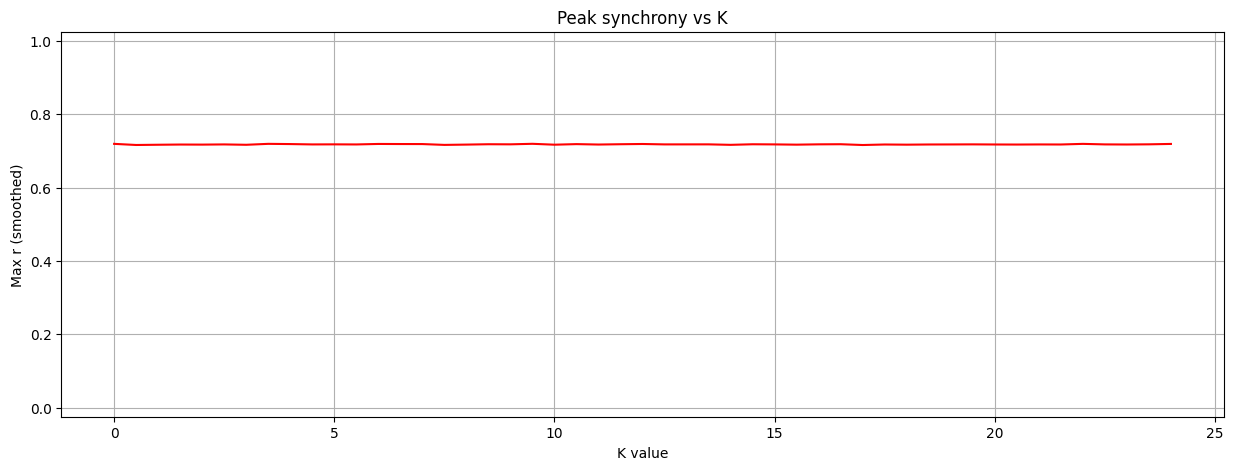

In [309]:

window = 1

mask = (acc >= 0) & (acc <= 10000)

r_max = np.zeros(len(acc))
for n in range(len(acc)):
    if mask[n]:
        color = cmap(norm(acc[n]))
        
        # smooth r[n]
        r_smooth = uniform_filter1d(r[n], size=window)
        
        # compute max after smoothing
        r_max[n] = np.mean(r_smooth)
        
# === summary plot of max r vs noise ===

plt.figure(figsize=(15,5))
plt.plot(acc, r_max, color='red')
plt.xlabel('K value')
plt.ylabel("Max r (smoothed)")
plt.title("Peak synchrony vs K")
plt.ylim(-0.025, 1.025)
plt.grid(True)
plt.show()

#print(r_max)

### m_noise

In [310]:
np.random.seed(200)

acc = np.arange(0, 20, 0.5)

N = 100
T = 24*10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

init_cov = 0.1
alpha = 0.1 


theta = 0
var_prior = np.zeros((len(acc), N, duration))
var_post = np.zeros((len(acc), N, duration))
m_hat = np.zeros((len(acc), N, duration))
G = np.zeros((len(acc), N, duration))

# === SCN filter init ===
phase_history = np.zeros((len(acc), N, duration))
psi = np.zeros((len(acc), duration))
r = np.zeros((len(acc), duration))

mean_period = 23.5
std_period = 0.2

# natural frequencies
omega = data['omega']


K_matrix = np.random.uniform(0, 6, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)


for n, mn in enumerate(acc):

    P_prime = 0.1  
    P = 0
    M = mn  


    # === Variances ===
    var_p = np.ones(N) * P_prime**2
    var_m = M**2

    
    # === Simulate light signal ===
    s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

    # intrinsic noise
    xi = data['xi']


    # === Main loop ===
    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t == 0:
            phases = np.random.vonmises(0, kappa=1, size=N)
            var_prior[n, :, t] = init_cov + var_p
        else:
            var_prior[n, :, t] = var_post[n, :, t-1] + var_p

        phase_history[n, :, t] = phases

        # order parameter
        order_param = np.mean(np.exp(1j * phases))
        r[n, t] = np.abs(order_param)
        psi[n, t] = np.angle(order_param)

        if t > duration:
            break
            
        # ===================== Linear observation update (light input) ========================

        m_hat[n, :, t] = sigmoid(np.sin(phases + omega), theta=theta)

        H = alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]) * np.cos(phases + omega)

        sigma2_obs_eff = ((alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]))**2) * (M**2)
        G[n, :, t] = (H * var_prior[n, :, t]) / (H * var_prior[n, :, t] * H + sigma2_obs_eff + 1e-8)

        gap = (m[t] - m_hat[n, :, t])

        var_post[n, :, t] = (1 - G[n, :, t] * H) * var_prior[n, :, t]

        phase_diff = phases[None, :] - phases[:, None]           # broadcast differences φ_j - φ_i
        coupling_sum = np.sum(K_matrix * np.sin(phase_diff), axis=1)  # same as sin(phases[j] - phases[i])

        phases += omega * dt + xi[:, t] + G[n, :, t] * gap + (1/N) * coupling_sum

        # wrap phases into (-pi, pi]
        phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating40/40: 100%|████████████████████| 2400/2400 [00:00<00:00, 9773.97it/s]


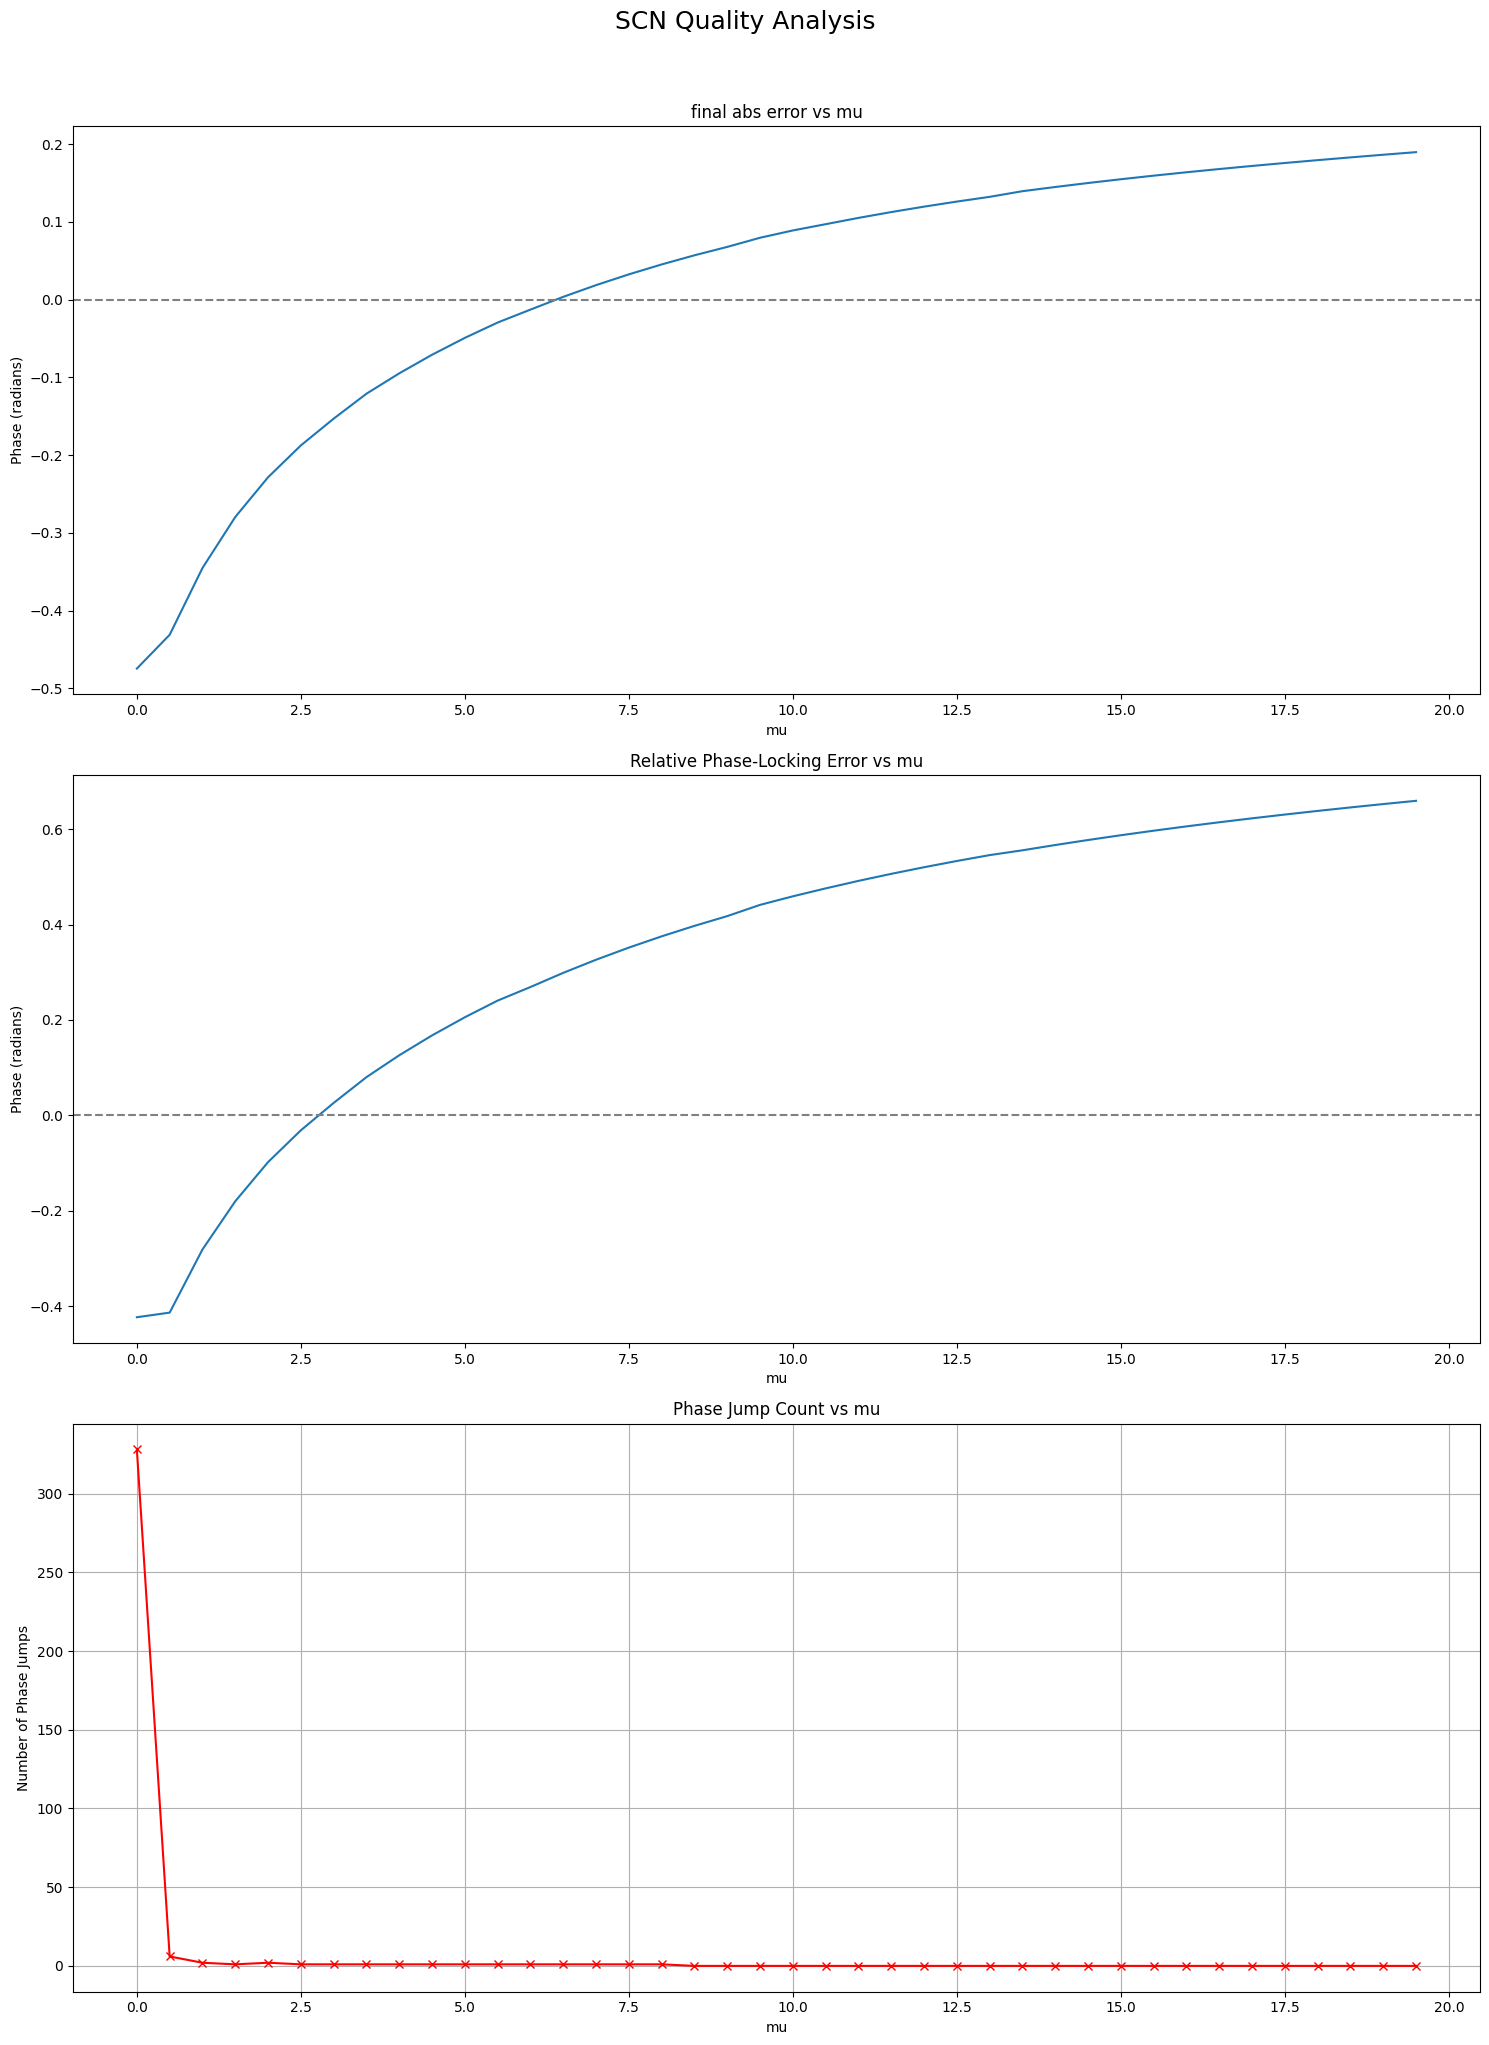

phase error min = 0.0035 at : [6.5]
locking error min = 0.0263 at: [3.]
spike count min = 0.0000 at : [ 8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.  14.5 15.
 15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5]


In [313]:
fig, axs = plt.subplots(3, 1, figsize=(15,20))
fig.suptitle("SCN Quality Analysis", fontsize=18, y=1.02)

total_diff = np.zeros(len(acc))
recent_diff = np.zeros(len(acc))
stability_ratio_diff = np.zeros(len(acc))

for n in range(len(acc)):
    window = int(duration * 0.2)
    phase_diff = np.unwrap(psi[n]) - np.unwrap(s)
    total_diff[n] = np.mean( phase_diff )

axs[0].plot(acc, total_diff)
axs[0].set_title("final abs error vs mu")
axs[0].set_xlabel("mu")
axs[0].set_ylabel("Phase (radians)")
axs[0].axhline(y=0, color='gray', linestyle='--')


angular_diff = np.zeros((len(acc), duration))
locking_score= np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n]=np.angle(np.exp(1j * (psi[n] - s))) 
    locking_score[n] = np.mean(angular_diff[n, -window:])

axs[1].plot(acc, locking_score)
axs[1].set_title("Relative Phase-Locking Error vs mu")
axs[1].set_xlabel("mu")
axs[1].set_ylabel("Phase (radians)")
axs[1].axhline(y=0, color='gray', linestyle='--')



angular_diff = np.zeros((len(acc), duration))
n_spikes=np.zeros(len(acc))

for n in range(len(acc)):
    angular_diff[n] = np.angle(np.exp(1j * (psi[n] - s)))

for n in range(len(acc)):
    _ , _, spikes = count_phase_jumps(timesteps, angular_diff[n])
    n_spikes[n] = len(spikes)


axs[2].plot(acc, n_spikes, color='red', marker='x')
axs[2].set_title("Phase Jump Count vs mu")
axs[2].set_xlabel("mu")
axs[2].set_ylabel("Number of Phase Jumps")
plt.grid(True)
plt.tight_layout()

plt.show()

# Tolerance for numerical equality (since floats aren't exact)
tol = 1e-8

min_total = np.min(np.abs(total_diff))
min_lock = np.min(np.abs(locking_score))
min_spikes = np.min(n_spikes)

idx_total = np.where(np.isclose(np.abs(total_diff), min_total, atol=tol))[0]
idx_lock = np.where(np.isclose(np.abs(locking_score), min_lock, atol=tol))[0]
idx_spikes = np.where(np.isclose(n_spikes, min_spikes, atol=tol))[0]

mu_min_error = acc[idx_total]
mu_min_locking = acc[idx_lock]
mu_min_spikes = acc[idx_spikes]

print(f"phase error min = {min_total:.4f} at : {mu_min_error}")
print(f"locking error min = {min_lock:.4f} at: {mu_min_locking}")
print(f"spike count min = {min_spikes:.4f} at : {mu_min_spikes}")



### $\text{process noise}$

In [111]:
np.random.seed(200)

acc = np.arange(0, 1, 0.01)

N = 100
T = 24*10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

init_cov = 0.1
alpha = 0.1     
gamma = 0.1      # scale circular correction


theta = 0
var_prior = np.zeros((len(acc), N, duration))
var_post = np.zeros((len(acc), N, duration))
m_hat = np.zeros((len(acc), N, duration))
G = np.zeros((len(acc), N, duration))

# === SCN filter init ===
phase_history = np.zeros((len(acc), N, duration))
psi = np.zeros((len(acc), duration))
r = np.zeros((len(acc), duration))

mean_period = 23.5
std_period = 0.2

# natural frequencies
omega = np.random.normal(
    loc=2 * np.pi / mean_period,
    scale=(2 * np.pi / mean_period**2) * std_period,
    size=N
)


K = 1


for n, PP in enumerate(acc):

    P_prime = PP  
    P = 0
    M = 5  

    # === Variances ===
    var_p = np.ones(N) * P_prime**2
    var_m = M**2

    # === Simulate light signal ===
    s, m = sm_simulation(T=T, dt=dt, P=P, M=M, tau=0.2)  # no beta returned

    # intrinsic noise
    kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
    xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))


    # === Main loop ===
    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t == 0:
            phases = np.random.vonmises(0, kappa=1, size=N)
            var_prior[n, :, t] = init_cov + var_p
        else:
            var_prior[n, :, t] = var_post[n, :, t-1] + var_p

        phase_history[n, :, t] = phases

        # order parameter
        order_param = np.mean(np.exp(1j * phases))
        r[n, t] = np.abs(order_param)
        psi[n, t] = np.angle(order_param)

        if t > duration:
            break
            
        # ===================== Linear observation update (light input) ========================

        m_hat[n, :, t] = sigmoid(np.sin(phases + omega), theta=theta)

        H = alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]) * np.cos(phases + omega)

        sigma2_obs_eff = ((alpha * m_hat[n, :, t] * (1 - m_hat[n, :, t]))**2) * (M**2)
        G[n, :, t] = (H * var_prior[n, :, t]) / (H * var_prior[n, :, t] * H + sigma2_obs_eff + 1e-8)

        gap = (m[t] - m_hat[n, :, t])
        linear_correction = G[n, :, t] * gap

        var_post_linear = (1 - G[n, :, t] * H) * var_prior[n, :, t]

        # ================ Circular coupling update (population mean phase ψ) ====================
        delta = psi[n, t] - phases
        delta = (delta + np.pi) % (2 * np.pi) - np.pi  # wrap into (-pi, pi]

        # Prior concentration from linear posterior variance
        kappa_p = 1.0 / (var_post_linear + 1e-8)

        # Effective measurement concentration for mean-field
        kappa_m = (N * r[n, t]) / (2 * (1 - r[n, t] + 1e-8))

        circ_correction = np.arctan2(
            kappa_m * np.sin(delta),
            kappa_p + kappa_m * np.cos(delta)
        )

        # Apply circular correction
        phases += omega * dt + xi[:, t] + G[n, :, t] * gap + K * circ_correction

        # Update variance using posterior concentration formula
        kappa_post = np.sqrt(
            kappa_p**2 + kappa_m**2 + 2 * kappa_p * kappa_m * np.cos(delta)
        )
        var_post[n, :, t] = 1.0 / (kappa_post + 1e-8)

    # wrap phases into (-pi, pi]
    phases = (phases + np.pi) % (2 * np.pi) - np.pi

simulating100/100: 100%|█████████████████| 2400/2400 [00:00<00:00, 11883.12it/s]


/var/folders/3t/j8jp86293gb_vcbssnjln66h0000gp/T/ipykernel_93620/3127501926.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('plasma')  # Choose any perceptual colormap


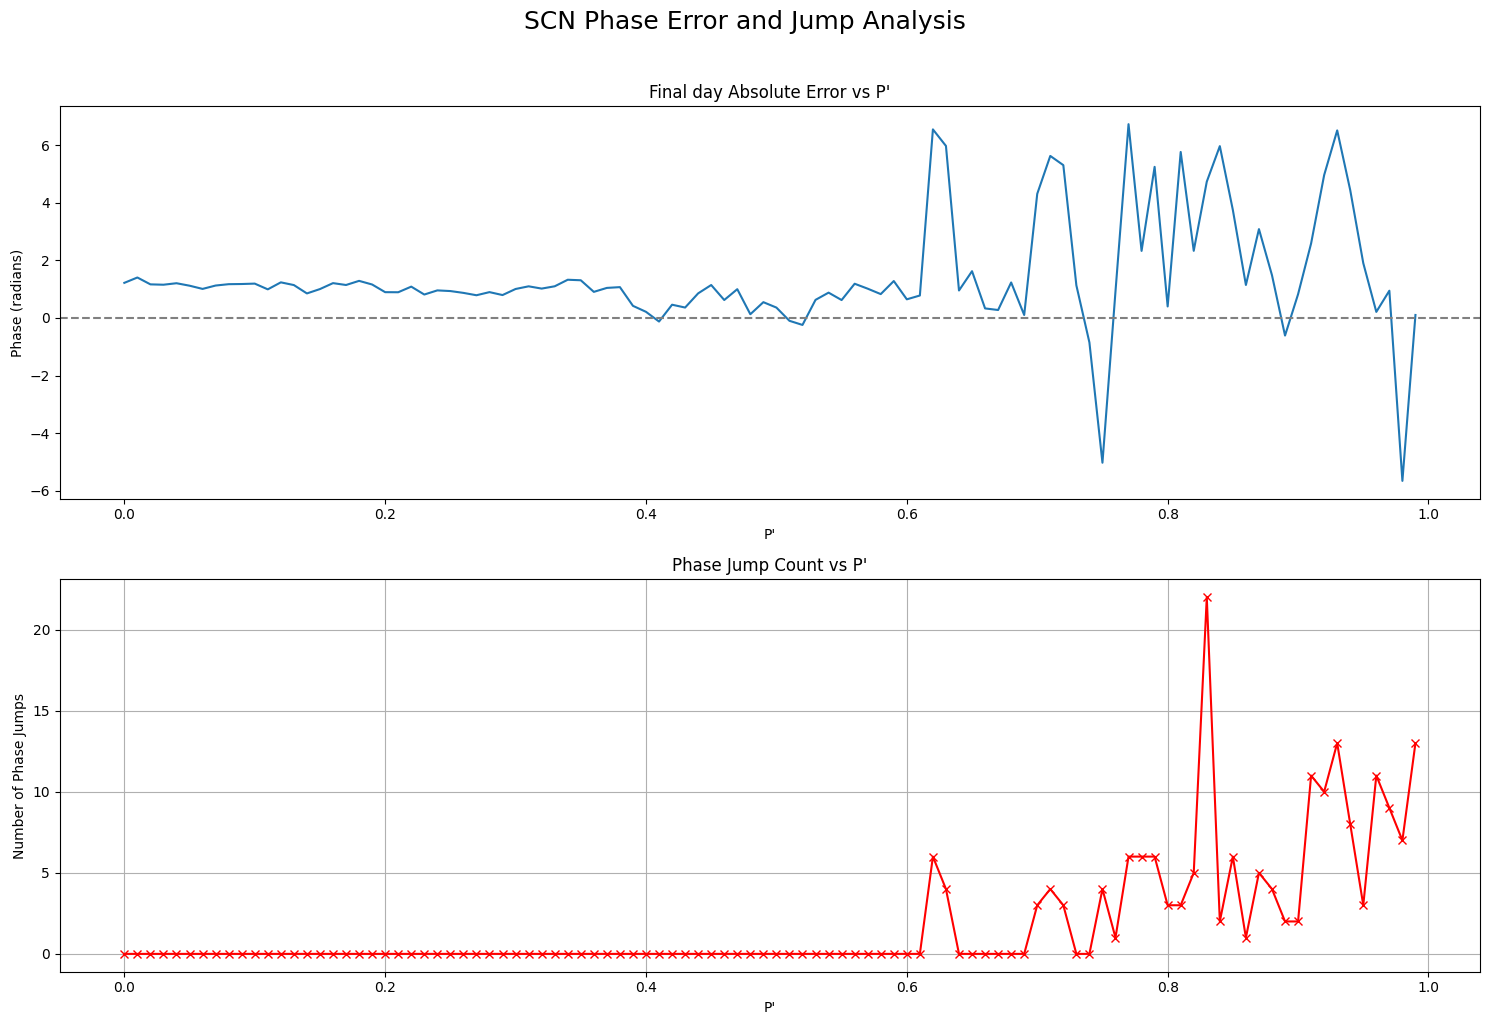

In [113]:
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle("SCN Phase Error and Jump Analysis", fontsize=18, y=1.02)

# === Gradient setup ===
cmap = get_cmap('plasma')  # Choose any perceptual colormap
norm = Normalize(vmin=min(acc), vmax=max(acc))

raw_err = np.zeros(len(acc))
scalar_err = np.zeros(len(acc))


for n in range(len(acc)):
    scalar_err[n]=np.mean(   np.abs(np.unwrap(psi[n]) - np.unwrap(s))[-240:]   )
    raw_err[n]=np.mean(  (np.unwrap(psi[n]) - np.unwrap(s))[-240:]   )
axs[0].plot(acc, raw_err)
#axs[0].plot(acc, scalar_err, color='lightblue', linestyle='--')
axs[0].set_title("Final day Absolute Error vs P'")
axs[0].set_xlabel("P'")
axs[0].set_ylabel("Phase (radians)")
axs[0].axhline(y=0, color='gray', linestyle='--')


angular_diff = np.zeros((len(acc), duration))
n_spikes=np.zeros(len(acc))

for n in range(len(acc)):
    color = cmap(norm(acc[n]))
    angular_diff[n] = np.angle(np.exp(1j * (psi[n] - s)))

for n in range(len(acc)):
    _ , _, spikes = count_phase_jumps(timesteps, angular_diff[n])
    n_spikes[n] = len(spikes)


axs[1].plot(acc, n_spikes, color='red', marker='x')
axs[1].set_title("Phase Jump Count vs P'")
axs[1].set_xlabel("P'")
axs[1].set_ylabel("Number of Phase Jumps")
plt.grid(True)

plt.tight_layout()

plt.show();

## $\text{Interaction Effect}$

### K * M * sig (Pending)

In [4]:
# === Parameters ===
N = 100
T = 24 * 10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

theta = 0.0
alpha = 0.2
P_prime = 0.25
init_cov = 0.1

mean_period = 24.0          # fixed μ

# === Sweep axes ===
M_values = np.arange(0, 1.05, 0.05)             # ← outer sweep: measurement noise
std_period_values = np.arange(0, 25, 1)         # σ
K_values = np.arange(0, 4.6, 0.1)               # K

# === Storage ===
psi_all = np.zeros((len(M_values), len(K_values), len(std_period_values), duration))
r_all = np.zeros_like(psi_all)
phase_history_all = np.zeros((len(M_values), len(K_values), len(std_period_values), N, duration))

# === Sweep ===
total_trials = len(M_values) * len(K_values) * len(std_period_values)
trial = 0

for iM, M in enumerate(M_values):
    for iK, K in enumerate(K_values):
        for iSig, sigma in enumerate(std_period_values):

            trial += 1
            desc = f"Trial {trial}/{total_trials} (M={M:.2f}, K={K:.2f}, σ={sigma:.1f})"
            omega = np.random.normal(loc=2 * np.pi / mean_period,
                                     scale=(2 * np.pi / (mean_period ** 2)) * sigma,
                                     size=N)

            # === Init ===
            var_p = np.ones(N) * P_prime ** 2
            var_m = M ** 2
            kappa_p_prime = 1 / P_prime ** 2 if P_prime > 0 else 0
            xi = np.random.vonmises(mu=0, kappa=kappa_p_prime,
                                    size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

            var_prior = np.zeros((N, duration))
            var_post = np.zeros((N, duration))
            m_hat = np.zeros((N, duration))
            G = np.zeros((N, duration))

            psi = np.zeros(duration)
            r = np.zeros(duration)

            phases = np.random.vonmises(0, kappa=1, size=N)

            for t in tqdm(range(duration), desc=desc, ncols=80):
                if t == 0:
                    var_prior[:, t] = init_cov + var_p
                else:
                    var_prior[:, t] = var_post[:, t - 1] + var_p

                order_param = np.mean(np.exp(1j * phases))
                r[t] = np.abs(order_param)
                psi[t] = np.angle(order_param)

                # === Observation ===
                m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
                H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
                sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t])) ** 2) * var_m
                G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

                m_t = sigmoid(np.sin(phases + omega) + np.random.normal(0, np.sqrt(var_m), size=N), theta=theta)
                gap = m_t - m_hat[:, t]
                linear_correction = G[:, t] * gap
                var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

                # === Circular Correction ===
                delta = psi[t] - phases
                delta = (delta + np.pi) % (2 * np.pi) - np.pi
                kappa_p = 1.0 / (var_post_linear + 1e-8)
                kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
                circ_correction = np.arctan2(kappa_m * np.sin(delta),
                                             kappa_p + kappa_m * np.cos(delta))

                # === Phase update ===
                if t < duration - 1:
                    phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                    var_post[:, t] = 1.0 / (np.sqrt(kappa_p**2 + kappa_m**2 +
                                                    2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8)
                    phases = (phases + np.pi) % (2 * np.pi) - np.pi

                phase_history_all[iM, iK, iSig, :, t] = phases

            psi_all[iM, iK, iSig, :] = psi
            r_all[iM, iK, iSig, :] = r


Trial 1/24150 (M=0.00, K=0.00, σ=0.0): 100%|█| 2400/2400 [00:00<00:00, 10395.20i
Trial 2/24150 (M=0.00, K=0.00, σ=1.0): 100%|█| 2400/2400 [00:00<00:00, 10548.34i
Trial 3/24150 (M=0.00, K=0.00, σ=2.0): 100%|█| 2400/2400 [00:00<00:00, 10434.70i
Trial 4/24150 (M=0.00, K=0.00, σ=3.0): 100%|█| 2400/2400 [00:00<00:00, 10561.99i
Trial 5/24150 (M=0.00, K=0.00, σ=4.0): 100%|█| 2400/2400 [00:00<00:00, 10550.98i
Trial 6/24150 (M=0.00, K=0.00, σ=5.0): 100%|█| 2400/2400 [00:00<00:00, 10387.40i
Trial 7/24150 (M=0.00, K=0.00, σ=6.0): 100%|█| 2400/2400 [00:00<00:00, 10647.25i
Trial 8/24150 (M=0.00, K=0.00, σ=7.0): 100%|█| 2400/2400 [00:00<00:00, 9619.51it
Trial 9/24150 (M=0.00, K=0.00, σ=8.0): 100%|█| 2400/2400 [00:00<00:00, 10783.51i
Trial 10/24150 (M=0.00, K=0.00, σ=9.0): 100%|█| 2400/2400 [00:00<00:00, 10803.56
Trial 11/24150 (M=0.00, K=0.00, σ=10.0): 100%|█| 2400/2400 [00:00<00:00, 10805.3
Trial 12/24150 (M=0.00, K=0.00, σ=11.0): 100%|█| 2400/2400 [00:00<00:00, 10767.6
Trial 13/24150 (M=0.00, K=0.

KeyboardInterrupt: 

### K*sig

In [123]:
# === Parameters ===
N = 100
T = 24 * 10
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

theta = 0.0
alpha = 0.2
P_prime = 0.25
init_cov = 0.1

mean_period = 24.0          # fixed μ
M = 2.5                    # fixed M

# === Sweep axes ===
std_period_values = np.arange(0, 25, 1)   # σ
K_values = np.arange(0, 3.6, 0.1)    # K

# === Storage ===
psi_all = np.zeros((len(K_values), len(std_period_values), duration))
r_all = np.zeros_like(psi_all)
phase_history_all = np.zeros((len(K_values), len(std_period_values), N, duration))

# === Sweep ===
total_trials = len(K_values) * len(std_period_values)
trial = 0

for iK, K in enumerate(K_values):
    for iSig, sigma in enumerate(std_period_values):

        trial += 1
        desc = f"Trial {trial}/{total_trials} (K={K:.2f}, σ={sigma:.1f})"
        omega = np.random.normal(loc=2 * np.pi / mean_period,
                                 scale=(2 * np.pi / (mean_period ** 2)) * sigma,
                                 size=N)

        # === Init ===
        var_p = np.ones(N) * P_prime ** 2
        var_m = M ** 2
        kappa_p_prime = 1 / P_prime ** 2 if P_prime > 0 else 0
        xi = np.random.vonmises(mu=0, kappa=kappa_p_prime,
                                size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

        var_prior = np.zeros((N, duration))
        var_post = np.zeros((N, duration))
        m_hat = np.zeros((N, duration))
        G = np.zeros((N, duration))

        psi = np.zeros(duration)
        r = np.zeros(duration)

        phases = np.random.vonmises(0, kappa=1, size=N)

        for t in tqdm(range(duration), desc=desc, ncols=80):
            if t == 0:
                var_prior[:, t] = init_cov + var_p
            else:
                var_prior[:, t] = var_post[:, t - 1] + var_p

            order_param = np.mean(np.exp(1j * phases))
            r[t] = np.abs(order_param)
            psi[t] = np.angle(order_param)

            # === Observation ===
            m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
            H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
            sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t])) ** 2) * var_m
            G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

            m_t = sigmoid(np.sin(phases + omega) + np.random.normal(0, np.sqrt(var_m), size=N), theta=theta)
            gap = m_t - m_hat[:, t]
            linear_correction = G[:, t] * gap
            var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

            # === Circular Correction ===
            delta = psi[t] - phases
            delta = (delta + np.pi) % (2 * np.pi) - np.pi
            kappa_p = 1.0 / (var_post_linear + 1e-8)
            kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
            circ_correction = np.arctan2(kappa_m * np.sin(delta),
                                         kappa_p + kappa_m * np.cos(delta))

            # === Phase update ===
            if t < duration - 1:
                phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                var_post[:, t] = 1.0 / (np.sqrt(kappa_p**2 + kappa_m**2 +
                                                2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8)
                phases = (phases + np.pi) % (2 * np.pi) - np.pi

            phase_history_all[iK, iSig, :, t] = phases

        psi_all[iK, iSig, :] = psi
        r_all[iK, iSig, :] = r


Trial 900/900 (K=3.50, σ=24.0): 100%|████| 2400/2400 [00:00<00:00, 10389.83it/s]


In [124]:
circ_errors = np.zeros((len(std_period_values), len(K_values)))
spike_counts = np.zeros_like(circ_errors)

# === Loop through configs ===
for iSig, sigma in enumerate(tqdm(std_period_values)):
    for iK, K in enumerate(K_values):
        psi_traj = psi_all[iK, iSig, :]
        
        # Wrapped circular error
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
        circ_errors[iSig, iK] = np.mean(np.abs(circ_err_traj[-240:]))

        # Spike count from angular derivative
        _, _, spikes = count_phase_jumps(timesteps, circ_err_traj)
        spike_counts[iSig, iK] = len(spikes)

100%|██████████| 25/25 [00:34<00:00,  1.40s/it]


In [141]:
# === Preallocate ===
circ_errors = np.zeros((len(std_period_values), len(K_values)))
abs_errors  = np.zeros_like(circ_errors)

# === Loop through configs ===
for iSig, sigma in enumerate(std_period_values):
    for iK, K in enumerate(K_values):
        psi_traj = psi_all[iK, iSig, :]

        # Wrapped circular error
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
        circ_errors[iSig, iK] = np.mean(circ_err_traj)

        # Absolute (unwrapped) error
        abs_err_traj = np.unwrap(psi_traj) - np.unwrap(s)
        abs_errors[iSig, iK] = np.mean(abs_err_traj[-240:])

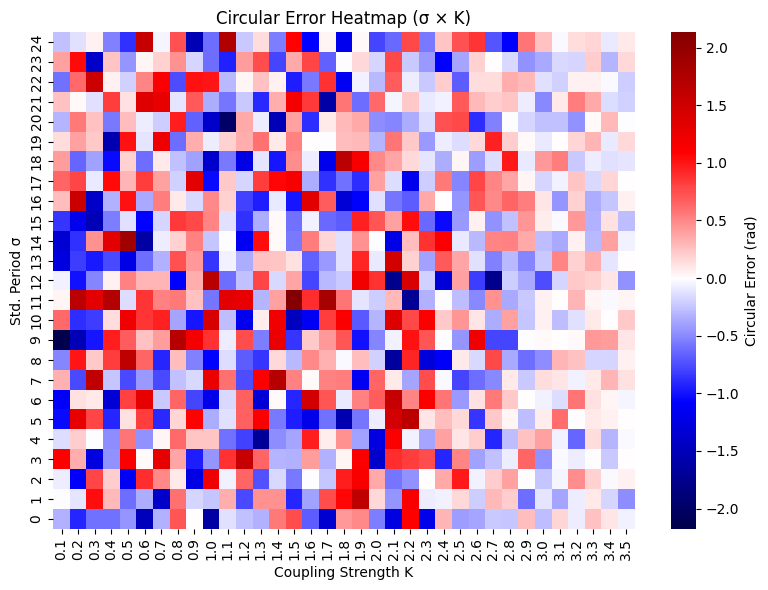

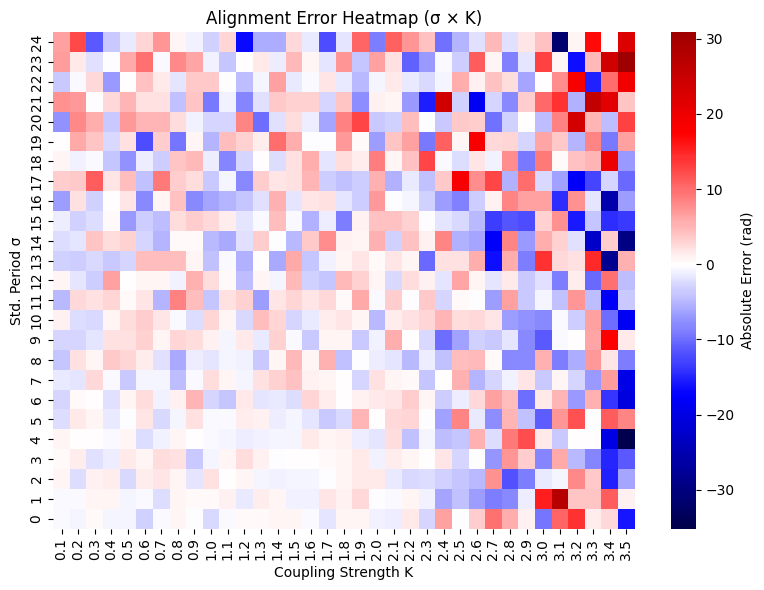

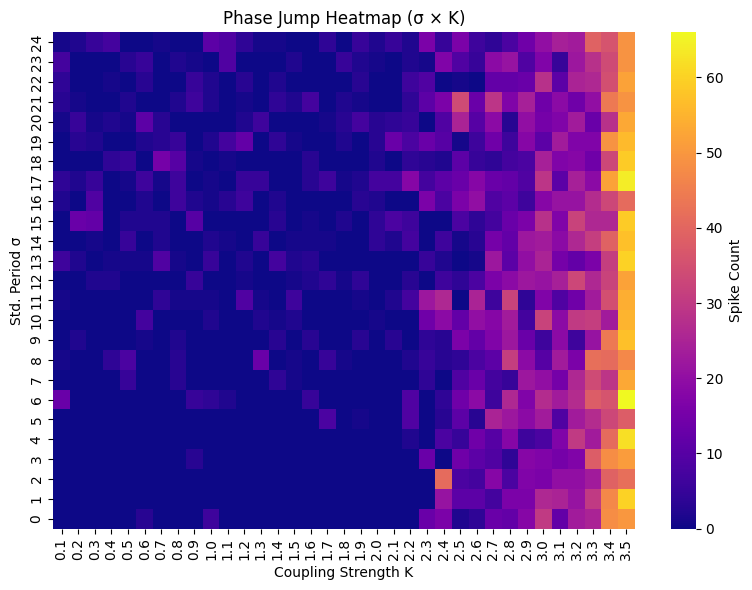

In [142]:
# === Heatmap: Circular Error ===
plt.figure(figsize=(8, 6))
sns.heatmap(circ_errors[:,1:],
            xticklabels=np.round(K_values[1:], 2),
            yticklabels=np.round(std_period_values, 2),
            center=0,
            cmap="seismic",
            cbar_kws={"label": "Circular Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("Coupling Strength K")
plt.ylabel("Std. Period σ")
plt.title("Circular Error Heatmap (σ × K)")
plt.tight_layout()
plt.show()

# === Heatmap: Absolute Error ===
plt.figure(figsize=(8, 6))
sns.heatmap(abs_errors[:,1:],
            xticklabels=np.round(K_values[1:], 2),
            yticklabels=np.round(std_period_values, 2),
            cmap="seismic", center=0,
            cbar_kws={"label": "Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("Coupling Strength K")
plt.ylabel("Std. Period σ")
plt.title("Alignment Error Heatmap (σ × K)")
plt.tight_layout()
plt.show()

# === Heatmap: Spike Counts ===
plt.figure(figsize=(8, 6))
sns.heatmap(spike_counts[:,1:],
            xticklabels=np.round(K_values[1:], 2),
            yticklabels=np.round(std_period_values, 2),
            cmap="plasma",
            cbar_kws={"label": "Spike Count"})
plt.gca().invert_yaxis()
plt.xlabel("Coupling Strength K")
plt.ylabel("Std. Period σ")
plt.title("Phase Jump Heatmap (σ × K)")
plt.tight_layout()
plt.show()


### $\text{M x } \sigma$

In [78]:
# === Parameters ===
N = 100                      # number of oscillators
T = 24 * 10                  # total time (e.g., 10 days)
dt = 0.1
timesteps = np.arange(0, T, dt)
duration = len(timesteps)

theta = 0.0
alpha = 0.2
P_prime = 0.25
init_cov = 0.1

mean_period = 24.0          # ← fixed μ
K = 1.0                     # ← fixed K

# === Sweeping axes ===
std_period_values = np.arange(0, 25, 1)      # σ
M_values = np.arange(0, 0.05, 0.001)   # M_noise

# === Storage ===
psi_all = np.zeros((len(std_period_values), len(M_values), duration))
r_all = np.zeros_like(psi_all)
phase_history_all = np.zeros((len(std_period_values), len(M_values), N, duration))

# === Sweep ===
total_trials = len(std_period_values) * len(M_values)
trial = 0

for iSig, sigma in enumerate(std_period_values):
    for iM, M in enumerate(M_values):

        trial += 1
        desc = f"Trial {trial}/{total_trials} (σ={sigma:.1f}, M={M:.2f})"
        omega = np.random.normal(loc=2 * np.pi / mean_period,
                                 scale=(2 * np.pi / (mean_period ** 2)) * sigma,
                                 size=N)

        # === Init ===
        var_p = np.ones(N) * P_prime ** 2
        var_m = M ** 2
        kappa_p_prime = 1 / P_prime ** 2 if P_prime > 0 else 0
        xi = np.random.vonmises(mu=0, kappa=kappa_p_prime,
                                size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

        var_prior = np.zeros((N, duration))
        var_post = np.zeros((N, duration))
        m_hat = np.zeros((N, duration))
        G = np.zeros((N, duration))

        psi = np.zeros(duration)
        r = np.zeros(duration)

        phases = np.random.vonmises(0, kappa=1, size=N)

        for t in tqdm(range(duration), desc=desc, ncols=80):
            if t == 0:
                var_prior[:, t] = init_cov + var_p
            else:
                var_prior[:, t] = var_post[:, t - 1] + var_p

            order_param = np.mean(np.exp(1j * phases))
            r[t] = np.abs(order_param)
            psi[t] = np.angle(order_param)

            # === Observation ===
            m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
            H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
            sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t])) ** 2) * var_m
            G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

            m_t = sigmoid(np.sin(phases + omega) + np.random.normal(0, np.sqrt(var_m), size=N), theta=theta)
            gap = m_t - m_hat[:, t]
            linear_correction = G[:, t] * gap
            var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

            # === Circular Correction ===
            delta = psi[t] - phases
            delta = (delta + np.pi) % (2 * np.pi) - np.pi
            kappa_p = 1.0 / (var_post_linear + 1e-8)
            kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
            circ_correction = np.arctan2(kappa_m * np.sin(delta),
                                         kappa_p + kappa_m * np.cos(delta))

            # === Phase update ===
            if t < duration - 1:
                phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                var_post[:, t] = 1.0 / (np.sqrt(kappa_p**2 + kappa_m**2 +
                                                2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8)
                phases = (phases + np.pi) % (2 * np.pi) - np.pi

            phase_history_all[iSig, iM, :, t] = phases

        psi_all[iSig, iM, :] = psi
        r_all[iSig, iM, :] = r


Trial 1250/1250 (σ=24.0, M=0.05): 100%|██| 2400/2400 [00:00<00:00, 11001.60it/s]


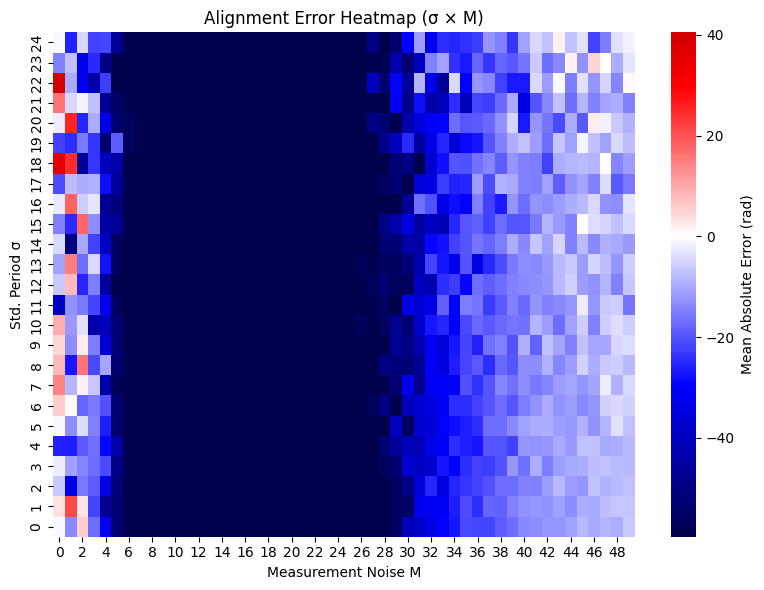

In [95]:
# --- Precompute alignment errors ---
align_errors = np.zeros((len(std_period_values), len(M_values)))

for iSig, sigma in enumerate(std_period_values):
    for iM, M in enumerate(M_values):
        psi_traj = psi_all[iSig, iM, :]
        abs_err = np.unwrap(psi_traj) - np.unwrap(s)
        align_errors[iSig, iM] = np.mean(abs_err[-240:])  # avg over last 24h

# --- Plot alignment heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(align_errors,
            yticklabels=np.round(std_period_values, 2),
            cmap="seismic", center=0,
            cbar_kws={"label": "Mean Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("Measurement Noise M")
plt.ylabel("Std. Period σ")
plt.title("Alignment Error Heatmap (σ × M)")
plt.tight_layout()
plt.show()

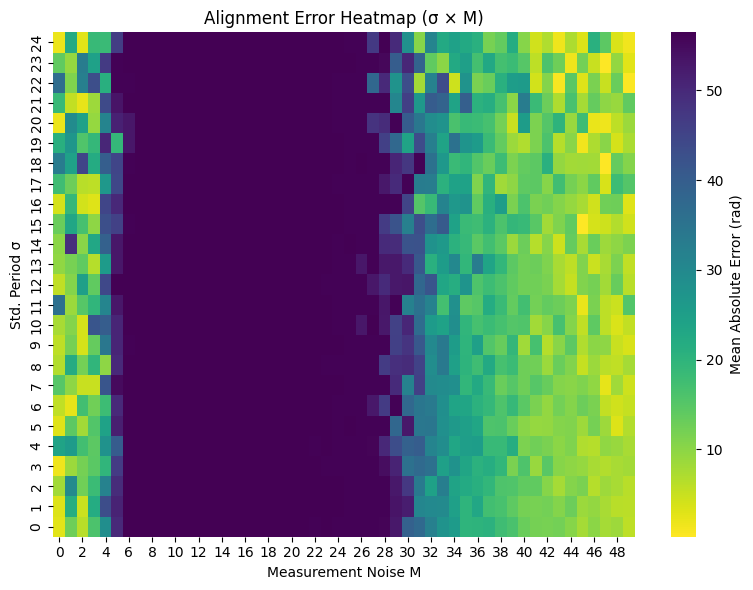

In [91]:
# --- Precompute alignment errors ---
align_errors = np.zeros((len(std_period_values), len(M_values)))

for iSig, sigma in enumerate(std_period_values):
    for iM, M in enumerate(M_values):
        psi_traj = psi_all[iSig, iM, :]
        abs_err = np.abs(np.unwrap(psi_traj) - np.unwrap(s))
        align_errors[iSig, iM] = np.mean(abs_err[-480:])  # avg over last 24h

# --- Plot alignment heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(align_errors,
            yticklabels=np.round(std_period_values, 2),
            cmap="viridis_r", #center=0,
            cbar_kws={"label": "Mean Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("Measurement Noise M")
plt.ylabel("Std. Period σ")
plt.title("Alignment Error Heatmap (σ × M)")
plt.tight_layout()
plt.show()



100%|██████████| 25/25 [00:44<00:00,  1.77s/it]


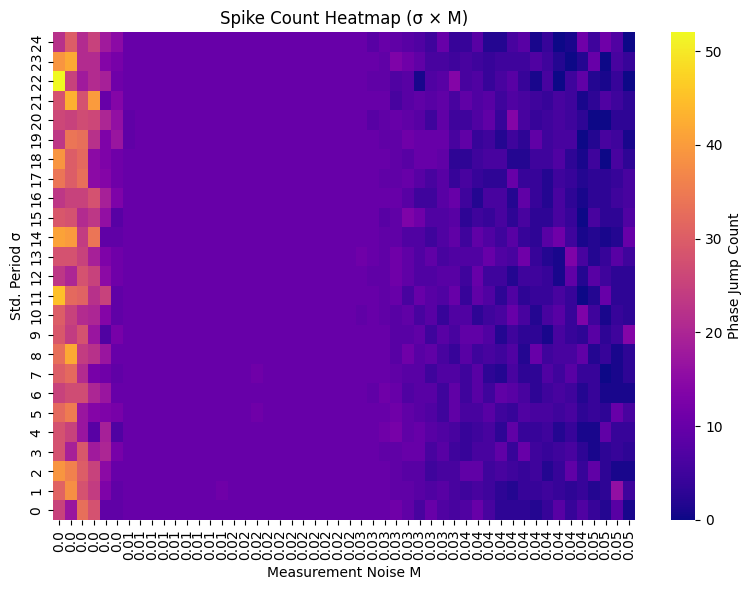

In [93]:
# --- Precompute spike counts ---
spike_counts = np.zeros((len(std_period_values), len(M_values)))

for iSig, sigma in enumerate(tqdm(std_period_values)):
    for iM, M in enumerate(M_values):
        psi_traj = psi_all[iSig, iM, :]
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
        _, _, spikes = count_phase_jumps(timesteps, circ_err_traj)
        spike_counts[iSig, iM] = len(spikes)

# --- Plot spike count heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(spike_counts,
            xticklabels=np.round(M_values, 2),
            yticklabels=np.round(std_period_values, 2),
            cmap="plasma",
            cbar_kws={"label": "Phase Jump Count"})
plt.gca().invert_yaxis()
plt.xlabel("Measurement Noise M")
plt.ylabel("Std. Period σ")
plt.title("Spike Count Heatmap (σ × M)")
plt.tight_layout()
plt.show()


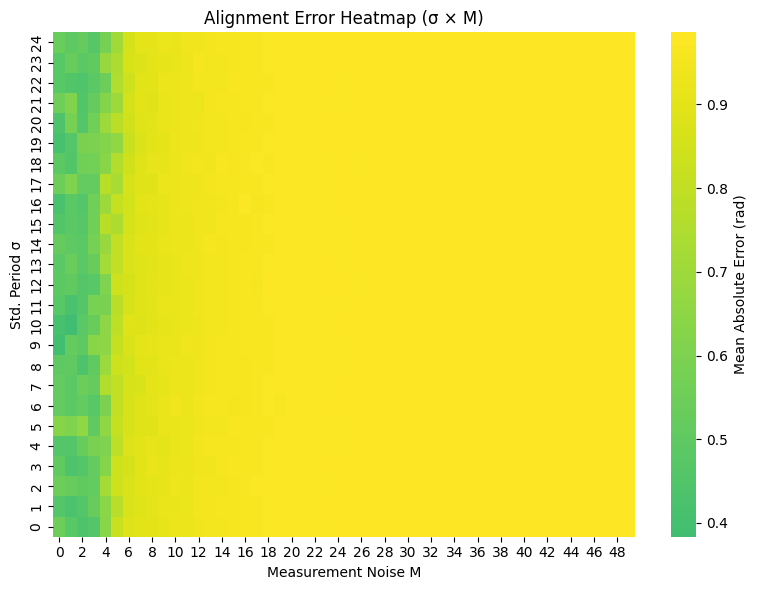

In [99]:
# --- Precompute alignment errors ---
R = np.zeros((len(std_period_values), len(M_values)))

for iSig, sigma in enumerate(std_period_values):
    for iM, M in enumerate(M_values):
        rr = r_all[iSig, iM, :]

        R[iSig, iM] = np.max(rr)

# --- Plot alignment heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(R,
            #np.max(r_all, axis = 2),
            yticklabels=np.round(std_period_values, 2),
            cmap="viridis", center=0,
            cbar_kws={"label": "Mean Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("Measurement Noise M")
plt.ylabel("Std. Period σ")
plt.title("Alignment Error Heatmap (σ × M)")
plt.tight_layout()
plt.show()

### $m_{noise}\text{ x K}$

In [62]:
# === Parameter sweeps ===
K_values = np.arange(0, 4.25, 0.25)       # sweep coupling
M_values = np.arange(0, 1, 0.005)         # sweep measurement noise
mu = 23.5                              # fixed mean period
sigma = 0.2                            # fixed std dev
P_prime = 0.25

# === Storage for raw results ===
# shape: (len(K), len(M), duration)
psi_all  = np.zeros((len(K_values), len(M_values), duration))
r_all    = np.zeros((len(K_values), len(M_values), duration))
phase_history_all = np.zeros((len(K_values), len(M_values), N, duration))

total_trials = len(K_values) * len(M_values)
trial = 0

# === Sweep ===
for iK, K in enumerate(K_values):
    for iM, M in enumerate(M_values):

        # natural frequencies fixed by μ, σ
        omega = np.random.normal(
            loc=2 * np.pi / mu,
            scale=(2 * np.pi / (mu**2)) * sigma,
            size=N
        )

        # noise parameters (depends on M)
        var_p = np.ones(N) * P_prime**2
        var_m = M**2

        kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
        xi = np.random.vonmises(mu=0, kappa=kappa_p_prime,
                                size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

        var_prior = np.zeros((N, duration))
        var_post  = np.zeros((N, duration))
        m_hat     = np.zeros((N, duration))
        G         = np.zeros((N, duration))

        psi = np.zeros(duration)
        r   = np.zeros(duration)

        phases = np.random.vonmises(0, kappa=1, size=N)

        trial += 1
        desc = f"Trial {trial}/{total_trials} (K={K:.2f}, M={M:.2f})"
        for t in tqdm(range(duration), desc=desc, ncols=80):

            if t == 0:
                var_prior[:, t] = init_cov + var_p
            else:
                var_prior[:, t] = var_post[:, t-1] + var_p

            # order parameter
            order_param = np.mean(np.exp(1j * phases))
            r[t] = np.abs(order_param)
            psi[t] = np.angle(order_param)

            # observation update
            m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
            H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
            sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
            G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

            gap = (m[t] - m_hat[:, t])
            linear_correction = G[:, t] * gap
            var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

            # circular correction
            delta = psi[t] - phases
            delta = (delta + np.pi) % (2 * np.pi) - np.pi
            kappa_p = 1.0 / (var_post_linear + 1e-8)
            kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
            circ_correction = np.arctan2(
                kappa_m * np.sin(delta),
                kappa_p + kappa_m * np.cos(delta)
            )

            # update phases
            if t < duration - 1:
                phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                var_post[:, t] = 1.0 / (
                    np.sqrt(kappa_p**2 + kappa_m**2 + 2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8
                )
                phases = (phases + np.pi) % (2 * np.pi) - np.pi

            phase_history_all[iK, iM, :, t] = phases

        psi_all[iK, iM, :] = psi
        r_all[iK, iM, :] = r

# === At this point ===
# psi_all -> mean phase trajectory
# r_all -> coherence trajectory
# phase_history_all -> full per-oscillator phases


Trial 3400/3400 (K=4.00, M=0.99): 100%|██| 2400/2400 [00:00<00:00, 11011.84it/s]


sweeping M: 100%|█████████████████████████████| 200/200 [02:08<00:00,  1.56it/s]


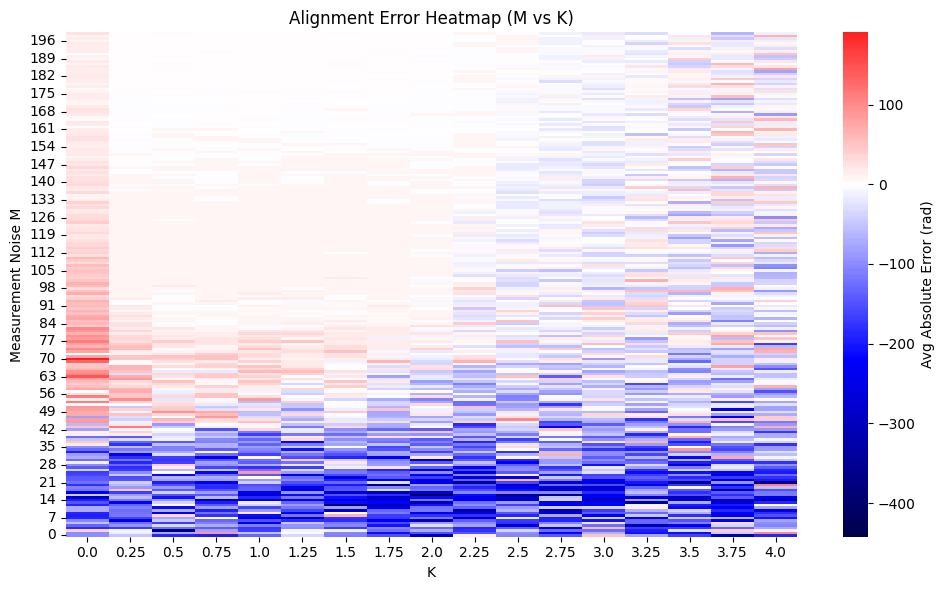

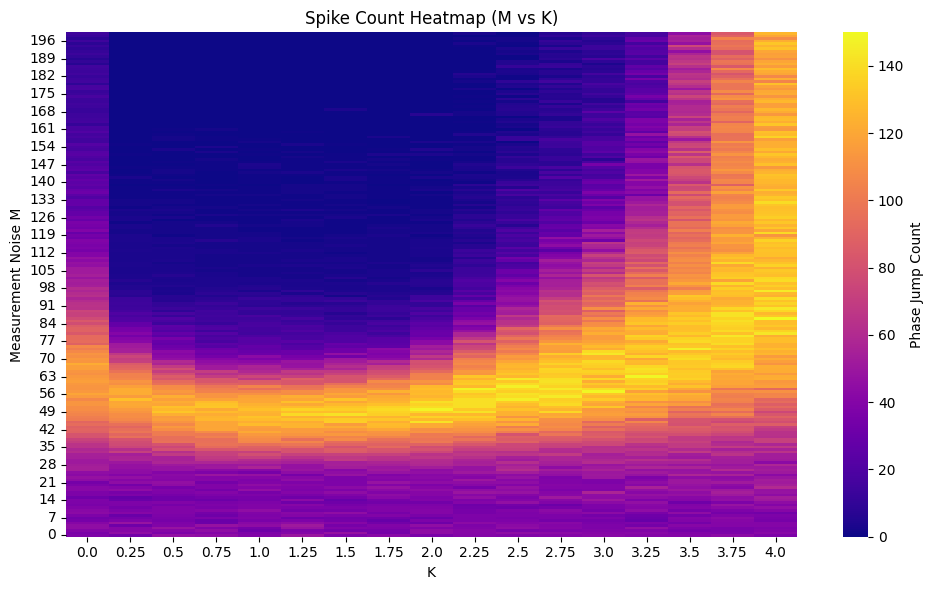

In [63]:
align_errors = np.zeros((len(M_values), len(K_values)))
spike_counts = np.zeros((len(M_values), len(K_values)))

for iM, M in enumerate(tqdm(M_values, desc="sweeping M", ncols=80)):
    for iK, K in enumerate(K_values):
        psi_traj = psi_all[iK, iM, :]   # trajectory for this (K, M)

        # --- Alignment error (absolute, unwrapped) ---
        abs_err = np.unwrap(psi_traj) - np.unwrap(s)
        align_errors[iM, iK] = np.mean(abs_err[-240:])   # steady-state window

        # --- Spike counts ---
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
        _, _, spikes = count_phase_jumps(timesteps, circ_err_traj)
        spike_counts[iM, iK] = len(spikes)

# --- Plot Alignment Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(align_errors,
            xticklabels=np.round(K_values,2),
            #yticklabels=M_values,
            cmap="seismic",
            center=0,
            cbar_kws={"label": "Avg Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Measurement Noise M")
plt.title("Alignment Error Heatmap (M vs K)")
plt.tight_layout()
plt.show()

# --- Plot Spike Count Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(spike_counts,
            xticklabels=np.round(K_values,2),
            #yticklabels=M_values,
            cmap="plasma",
            cbar_kws={"label": "Phase Jump Count"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Measurement Noise M")
plt.title("Spike Count Heatmap (M vs K)")
plt.tight_layout()
plt.show()


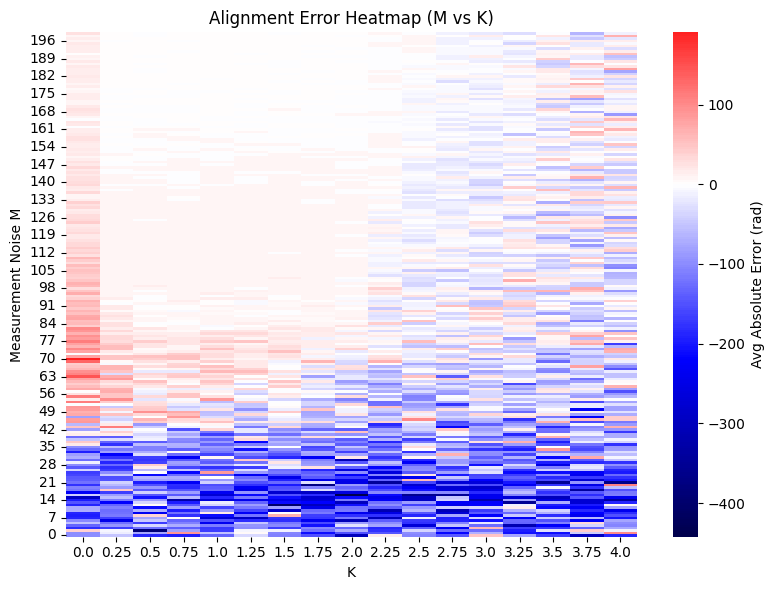

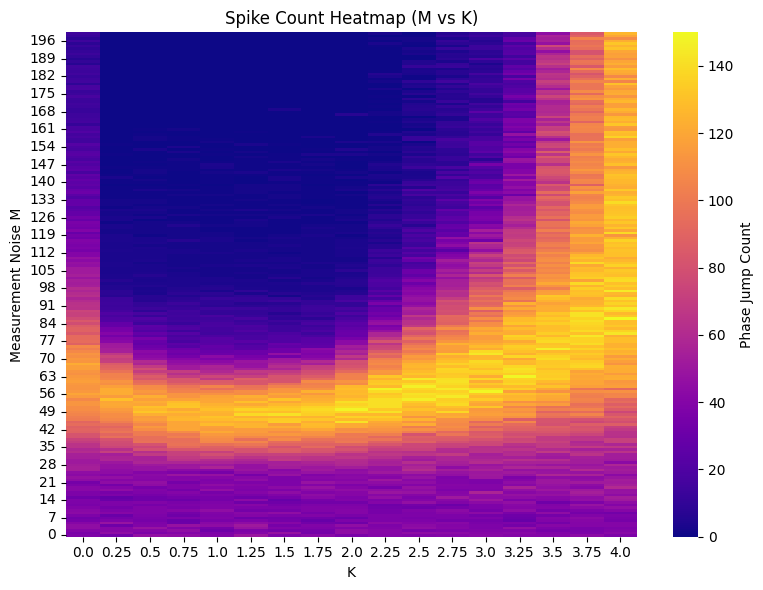

In [64]:
# --- Plot Alignment Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(align_errors,
            xticklabels=np.round(K_values,2),
            #yticklabels=M_values,
            cmap="seismic",
            center=0,
            cbar_kws={"label": "Avg Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Measurement Noise M")
plt.title("Alignment Error Heatmap (M vs K)")
plt.tight_layout()
plt.show()

# --- Plot Spike Count Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(spike_counts,
            xticklabels=np.round(K_values,2),
            #yticklabels=M_values,
            cmap="plasma",
            cbar_kws={"label": "Phase Jump Count"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Measurement Noise M")
plt.title("Spike Count Heatmap (M vs K)")
plt.tight_layout()
plt.show()


### $\text{3D sweep}$

In [286]:
# === Parameter sweeps ===
K_values = np.arange(0, 5, 0.25)
P_prime_values = np.arange(0.1, 1, 0.1)
M_values = np.arange(1, 11)

# === Storage for raw results ===
# shape: (len(K), len(P_prime), len(M), duration)
psi_all = np.zeros((len(K_values), len(P_prime_values), len(M_values), duration))
r_all   = np.zeros((len(K_values), len(P_prime_values), len(M_values), duration))
phase_history_all = np.zeros((len(K_values), len(P_prime_values), len(M_values), N, duration))


total_trials = len(K_values) * len(P_prime_values) * len(M_values)
trial = 0
# === Sweep ===
for iK, K in enumerate(K_values):
    for iP, P_prime in enumerate(P_prime_values):
        for iM, M in enumerate(M_values):

            var_p = np.ones(N) * P_prime**2
            var_m = M**2

            kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
            xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

            var_prior = np.zeros((N, duration))
            var_post = np.zeros((N, duration))
            m_hat = np.zeros((N, duration))
            G = np.zeros((N, duration))

            psi = np.zeros(duration)
            r = np.zeros(duration)

            phases = np.random.vonmises(0, kappa=1, size=N)


            trial += 1
            desc = f"Trial {trial}/{total_trials}"
            for t in tqdm(range(duration), desc=desc, ncols=80):

                if t == 0:
                    var_prior[:, t] = init_cov + var_p
                else:
                    var_prior[:, t] = var_post[:, t-1] + var_p

                # order parameter
                order_param = np.mean(np.exp(1j * phases))
                r[t] = np.abs(order_param)
                psi[t] = np.angle(order_param)

                # observation update
                m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
                H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
                sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
                G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

                gap = (m[t] - m_hat[:, t])
                linear_correction = G[:, t] * gap
                var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

                # circular correction
                delta = psi[t] - phases
                delta = (delta + np.pi) % (2 * np.pi) - np.pi
                kappa_p = 1.0 / (var_post_linear + 1e-8)
                kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
                circ_correction = np.arctan2(kappa_m * np.sin(delta), kappa_p + kappa_m * np.cos(delta))

                # update phases
                if t < duration - 1:
                    phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                    var_post[:, t] = 1.0 / (np.sqrt(kappa_p**2 + kappa_m**2 + 2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8)
                    phases = (phases + np.pi) % (2 * np.pi) - np.pi

                phase_history_all[iK, iP, iM, :, t] = phases

            psi_all[iK, iP, iM, :] = psi
            r_all[iK, iP, iM, :] = r

# === At this point ===
# psi_all -> mean phase trajectory
# r_all -> coherence trajectory
# phase_history_all -> full per-oscillator phases


Trial 1800/1800: 100%|███████████████████| 2400/2400 [00:00<00:00, 10732.69it/s]


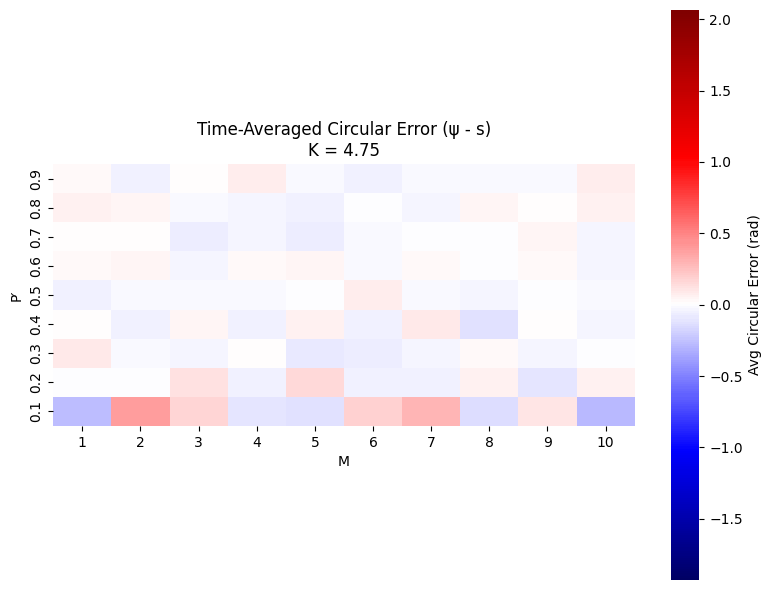

In [324]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Precompute global min/max for constant scaling ---
all_vals = []
for iK in range(len(K_values)):
    for iP in range(len(P_prime_values)):
        for iM in range(len(M_values)):
            psi_traj = psi_all[iK, iP, iM, :]
            abs_err_traj = np.unwrap(psi_traj)-np.unwrap(s)
            circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
            val = np.mean(circ_err_traj[480:])
            all_vals.append(val)

vmin = min(all_vals)
vmax = max(all_vals)

# --- Animate over K ---
for iK, K in enumerate(K_values):

    alignment_grid = np.zeros((len(P_prime_values), len(M_values)))
    for iP, P_prime in enumerate(P_prime_values):
        for iM, M in enumerate(M_values):
            psi_traj = psi_all[iK, iP, iM, :]
            circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
            alignment_grid[iP, iM] = np.mean(circ_err_traj[480:])

    plt.figure(figsize=(8,6))
    ax=sns.heatmap(alignment_grid,
                xticklabels=M_values,
                yticklabels=np.round(P_prime_values,2),
                cmap="seismic",
                center=0,         # force midpoint at 0
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Avg Circular Error (rad)"})
    plt.gca().invert_yaxis()
    ax.set_aspect(0.5) 
    plt.xlabel("M")
    plt.ylabel("P′")
    plt.title(f"Time-Averaged Circular Error (ψ - s)\nK = {K:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(0.5)
    clear_output(wait=True)


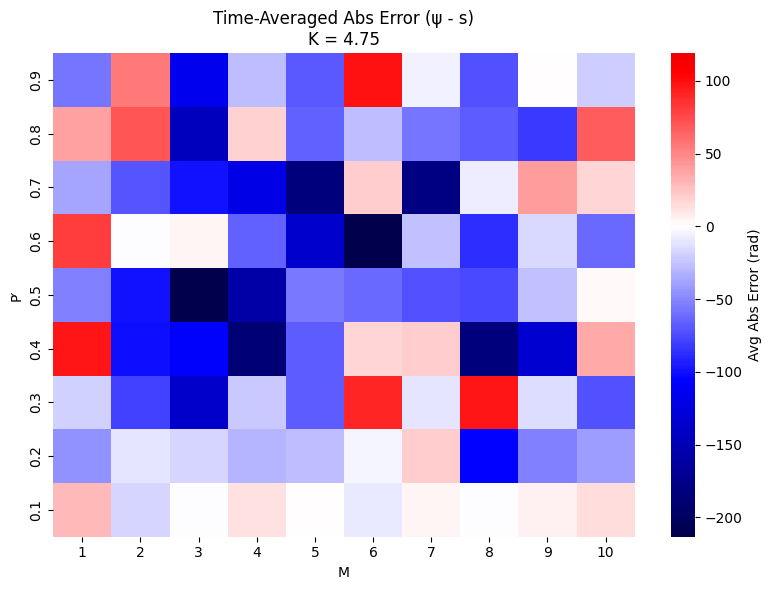

In [350]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Precompute global min/max for constant scaling ---
all_vals = []
for iK in range(len(K_values)):
    for iP in range(len(P_prime_values)):
        for iM in range(len(M_values)):
            psi_traj = psi_all[iK, iP, iM, :]
            abs_err_traj = np.unwrap(psi_traj)-np.unwrap(s)
            val = np.mean(abs_err_traj[480:])
            all_vals.append(val)

vmin = min(all_vals)
vmax = max(all_vals)

# --- Animate over K ---
for iK, K in enumerate(K_values):

    alignment_grid = np.zeros((len(P_prime_values), len(M_values)))
    for iP, P_prime in enumerate(P_prime_values):
        for iM, M in enumerate(M_values):
            psi_traj = psi_all[iK, iP, iM, :]
            abs_err_traj = np.unwrap(psi_traj)-np.unwrap(s)
            alignment_grid[iP, iM] = np.mean(abs_err_traj[-240:])

    plt.figure(figsize=(8,6))
    ax = sns.heatmap(alignment_grid,
                xticklabels=M_values,
                yticklabels=np.round(P_prime_values,2),
                cmap="seismic",
                center=0,         # force midpoint at 0
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Avg Abs Error (rad)"})
    plt.gca().invert_yaxis()
    #ax.set_aspect(0.5) 
    plt.xlabel("M")
    plt.ylabel("P′")
    plt.title(f"Time-Averaged Abs Error (ψ - s)\nK = {K:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)


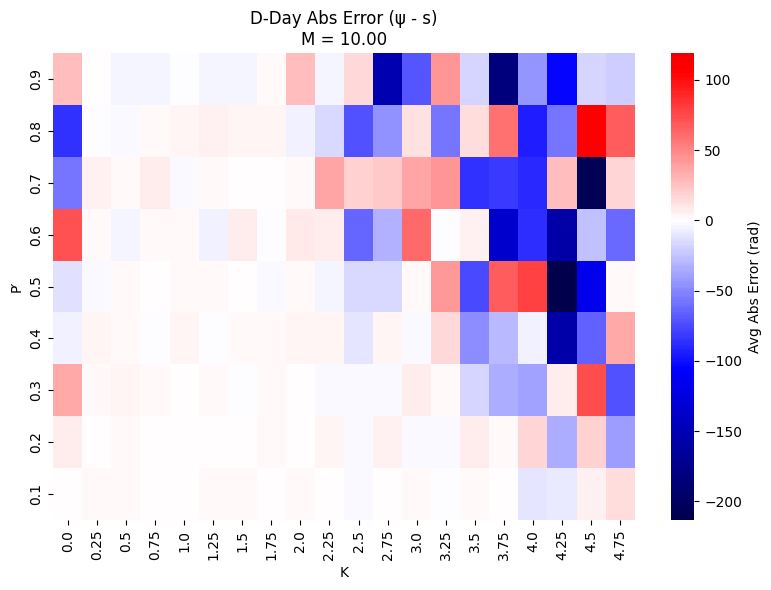

In [365]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Precompute global min/max for constant scaling ---
all_vals = []
for iK in range(len(K_values)):
    for iP in range(len(P_prime_values)):
        for iM in range(len(M_values)):
            psi_traj = psi_all[iK, iP, iM, :]
            abs_err_traj = np.unwrap(psi_traj)-np.unwrap(s)
            val = np.mean(abs_err_traj[480:])
            all_vals.append(val)

vmin = min(all_vals)
vmax = max(all_vals)

# --- Animate over K ---
for iM, M in enumerate(M_values):

    alignment_grid = np.zeros((len(P_prime_values), len(K_values)))
    for iP, P_prime in enumerate(P_prime_values):
        for iK, K in enumerate(K_values):
            psi_traj = psi_all[iK, iP, iM, :]
            abs_err_traj = np.unwrap(psi_traj)-np.unwrap(s)
            alignment_grid[iP, iK] = np.mean(abs_err_traj[-240:])

    plt.figure(figsize=(8,6))
    ax = sns.heatmap(alignment_grid,
                xticklabels=K_values,
                yticklabels=np.round(P_prime_values,2),
                cmap="seismic",
                center=0,         # force midpoint at 0
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Avg Abs Error (rad)"})
    plt.gca().invert_yaxis()
    #ax.set_aspect() 
    plt.xlabel("K")
    plt.ylabel("P′")
    plt.title(f"D-Day Abs Error (ψ - s)\nM = {M:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)


In [308]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Precompute spike counts for all configs ---
spike_counts = np.zeros((len(K_values), len(P_prime_values), len(M_values)))

for iK, K in enumerate(tqdm(K_values, desc="K sweep")):
    for iP, P_prime in enumerate(P_prime_values):
        for iM, M in enumerate(M_values):
            psi_traj = psi_all[iK, iP, iM, :]
            circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
            _, _, spikes = count_phase_jumps(timesteps, circ_err_traj)
            spike_counts[iK, iP, iM] = len(spikes)

K sweep: 100%|██████████| 20/20 [01:06<00:00,  3.30s/it]


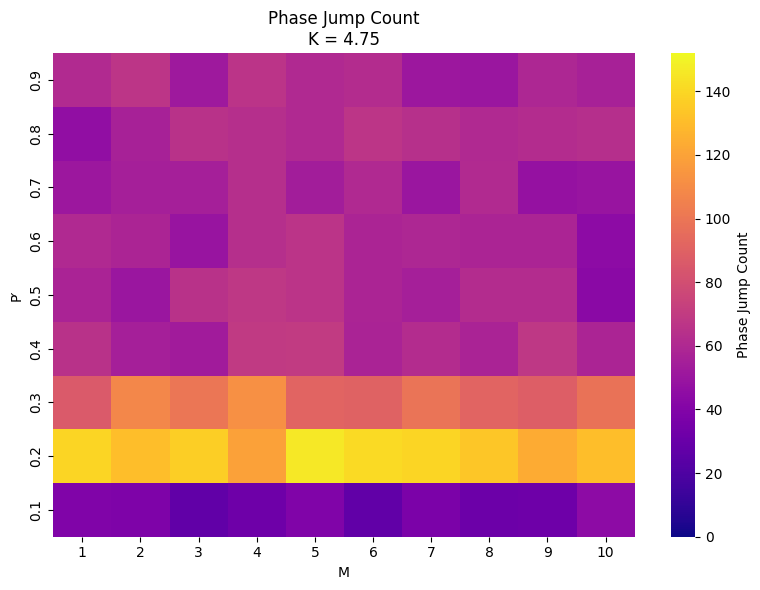

In [321]:
# --- Fix color range globally ---
vmin = np.min(spike_counts)
vmax = np.max(spike_counts)

# --- Animate over K ---
for iK, K in enumerate(K_values):

    plt.figure(figsize=(8,6))
    sns.heatmap(spike_counts[iK],
                xticklabels=M_values,
                yticklabels=np.round(P_prime_values,2),
                cmap="plasma",
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Phase Jump Count"})
    plt.gca().invert_yaxis()
    plt.xlabel("M")
    plt.ylabel("P′")
    plt.title(f"Phase Jump Count\nK = {K:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)

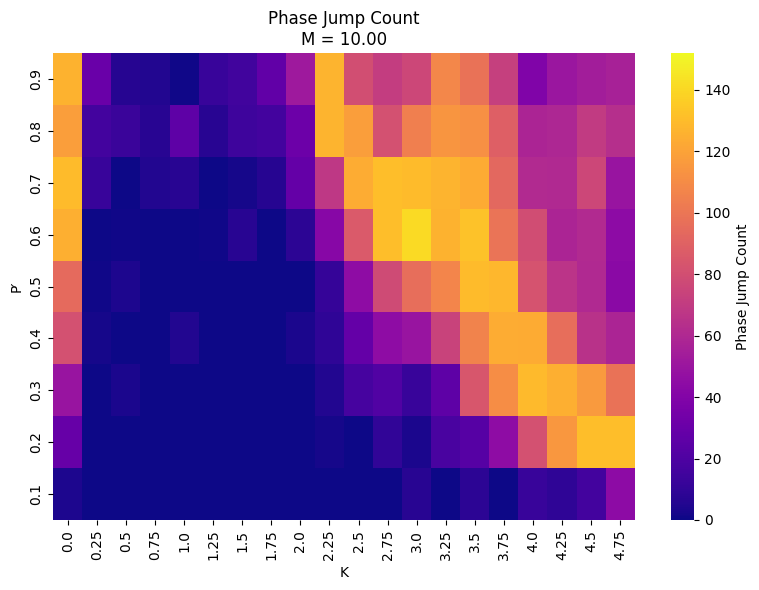

In [372]:
# --- Fix color range globally ---
vmin = np.min(spike_counts)
vmax = np.max(spike_counts)

# --- Animate over M ---
for iM, M in enumerate(M_values):

    plt.figure(figsize=(8,6))
    sns.heatmap(spike_counts[:,:, iM].T,
                xticklabels=K_values,
                yticklabels=np.round(P_prime_values,2),
                cmap="plasma",
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Phase Jump Count"})
    plt.gca().invert_yaxis()
    plt.xlabel("K")
    plt.ylabel("P′")
    plt.title(f"Phase Jump Count\nM = {M:.2f}")
    plt.tight_layout()
    plt.show()
    time.sleep(1)
    clear_output(wait=True)

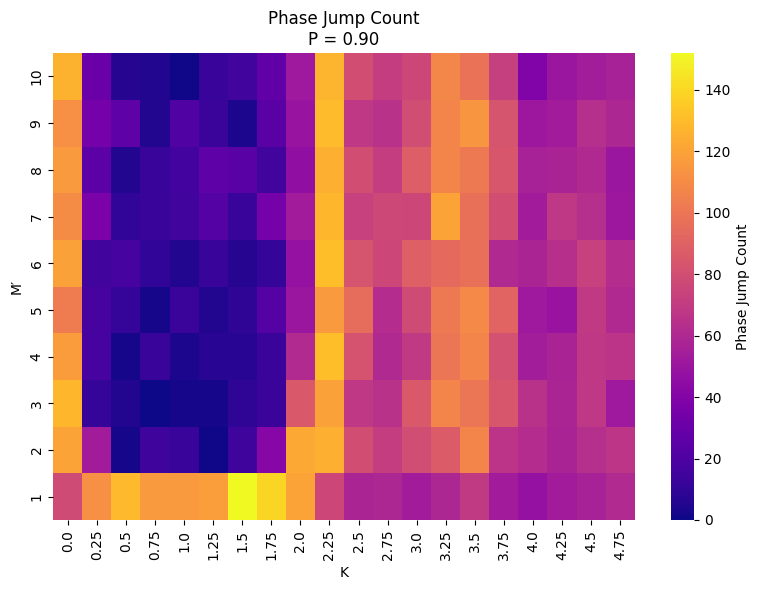

In [335]:
# --- Fix color range globally ---
vmin = np.min(spike_counts)
vmax = np.max(spike_counts)

# --- Animate over M ---
for iP, P in enumerate(P_prime_values):

    plt.figure(figsize=(8,6))
    sns.heatmap(spike_counts[:, iP, :].T,
                xticklabels=K_values,
                yticklabels=np.round(M_values,2),
                cmap="plasma",
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Phase Jump Count"})
    plt.gca().invert_yaxis()
    plt.xlabel("K")
    plt.ylabel("M′")
    plt.title(f"Phase Jump Count\nP = {P:.2f}")
    plt.tight_layout()
    plt.show()
    time.sleep(1)
    clear_output(wait=True)

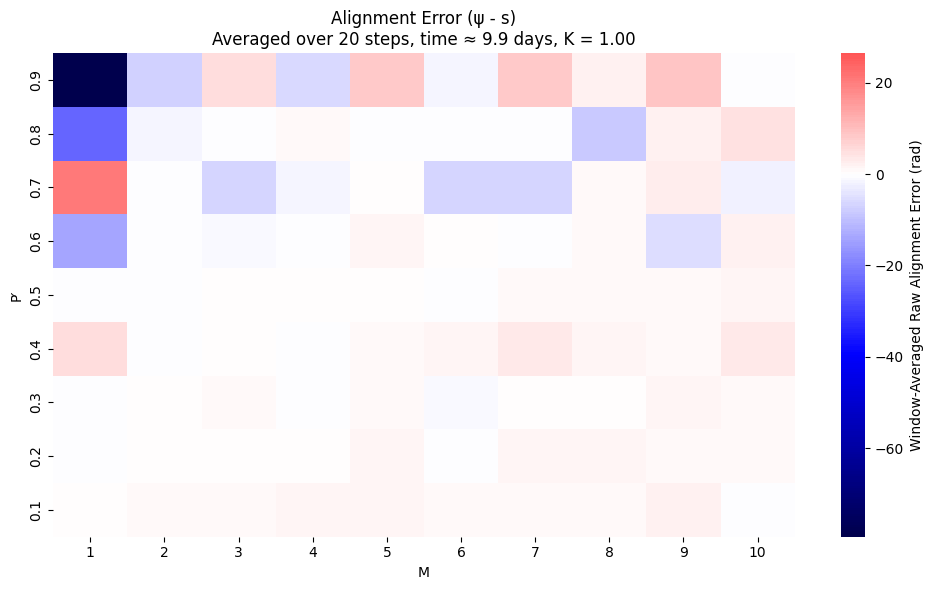

In [345]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Choose exact K value (must exist in K_values) ---
K_fixed = 1
iK_fixed = list(K_values).index(K_fixed)

# --- Compute raw unwrapped errors for all PxM across time ---
alignment_raw = np.zeros((len(P_prime_values), len(M_values), duration))
for iP, P_prime in enumerate(P_prime_values):
    for iM, M in enumerate(M_values):
        psi_traj = psi_all[iK_fixed, iP, iM, :]
        alignment_raw[iP, iM, :] = np.unwrap(psi_traj) - np.unwrap(s)

# --- Average over time windows ---
window = 20   # in timesteps
n_windows = duration // window
alignment_windowed = np.zeros((len(P_prime_values), len(M_values), n_windows))

for w in range(n_windows):
    start = w * window
    end = start + window
    alignment_windowed[:, :, w] = np.mean(alignment_raw[:, :, start:end], axis=2)

# --- Fix color scale globally ---
vmin = np.min(alignment_windowed)
vmax = np.max(alignment_windowed)

# --- Animate over windows ---
for w in range(n_windows):
    t_days = (w * window * dt) / 24  # approximate day label
    plt.figure(figsize=(10,6))
    ax = sns.heatmap(alignment_windowed[:, :, w],
                     xticklabels=M_values,
                     yticklabels=np.round(P_prime_values, 2),
                     cmap="seismic",
                     center=0,
                     vmin=vmin, vmax=vmax,
                     cbar_kws={"label": "Window-Averaged Raw Alignment Error (rad)"})
    plt.gca().invert_yaxis()
    plt.xlabel("M")
    plt.ylabel("P′")
    plt.title(f"Alignment Error (ψ - s)\nAveraged over {window} steps, time ≈ {t_days:.1f} days, K = {K_fixed:.2f}")
    ax.set_aspect("auto")

    plt.tight_layout()
    plt.show()

    time.sleep(0.2)
    clear_output(wait=True)


### $\text{K x }\mu_{period}$

In [ ]:
# === Parameter sweeps ===
K_values = np.arange(0, 5, 0.25)
mean_period_values = np.arange(15, 30.5, 0.5)   # sweep μ
sigma = 0.2                                     # fixed std dev

# === Storage for raw results ===
# shape: (len(K), len(mean_period), duration)
psi_all  = np.zeros((len(K_values), len(mean_period_values), duration))
r_all    = np.zeros((len(K_values), len(mean_period_values), duration))
phase_history_all = np.zeros((len(K_values), len(mean_period_values), N, duration))

total_trials = len(K_values) * len(mean_period_values)      
trial = 0

# === Sweep ===
for iK, K in enumerate(K_values):
    for iMu, mu in enumerate(mean_period_values):

        # natural frequencies depend on mean period only
        omega = np.random.normal(
            loc=2 * np.pi / mu,
            scale=(2 * np.pi / (mu**2)) * sigma,
            size=N
        )

        # noise parameters (fixed)
        var_p = np.ones(N) * P_prime**2
        var_m = M**2

        kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
        xi = np.random.vonmises(mu=0, kappa=kappa_p_prime,
                                size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

        var_prior = np.zeros((N, duration))
        var_post  = np.zeros((N, duration))
        m_hat     = np.zeros((N, duration))
        G         = np.zeros((N, duration))

        psi = np.zeros(duration)
        r   = np.zeros(duration)

        phases = np.random.vonmises(0, kappa=1, size=N)

        trial += 1
        desc = f"Trial {trial}/{total_trials} (K={K:.2f}, μ={mu:.2f})"
        for t in tqdm(range(duration), desc=desc, ncols=80):

            if t == 0:
                var_prior[:, t] = init_cov + var_p
            else:
                var_prior[:, t] = var_post[:, t-1] + var_p

            # order parameter
            order_param = np.mean(np.exp(1j * phases))
            r[t] = np.abs(order_param)
            psi[t] = np.angle(order_param)

            # observation update
            m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
            H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
            sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
            G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

            gap = (m[t] - m_hat[:, t])
            linear_correction = G[:, t] * gap
            var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

            # circular correction
            delta = psi[t] - phases
            delta = (delta + np.pi) % (2 * np.pi) - np.pi
            kappa_p = 1.0 / (var_post_linear + 1e-8)
            kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
            circ_correction = np.arctan2(kappa_m * np.sin(delta),
                                         kappa_p + kappa_m * np.cos(delta))

            # update phases
            if t < duration - 1:
                phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                var_post[:, t] = 1.0 / (np.sqrt(kappa_p**2 + kappa_m**2 +
                                     2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8)
                phases = (phases + np.pi) % (2 * np.pi) - np.pi

            phase_history_all[iK, iMu, :, t] = phases

        psi_all[iK, iMu, :] = psi
        r_all[iK, iMu, :] = r

# === At this point ===
# psi_all -> mean phase trajectory
# r_all -> coherence trajectory
# phase_history_all -> full per-oscillator phases


Trial 620/620 (K=4.75, μ=30.00): 100%|███| 2400/2400 [00:00<00:00, 10275.38it/s]


sweeping μ: 100%|██████████████████████████████| 31/31 [00:00<00:00, 189.90it/s]


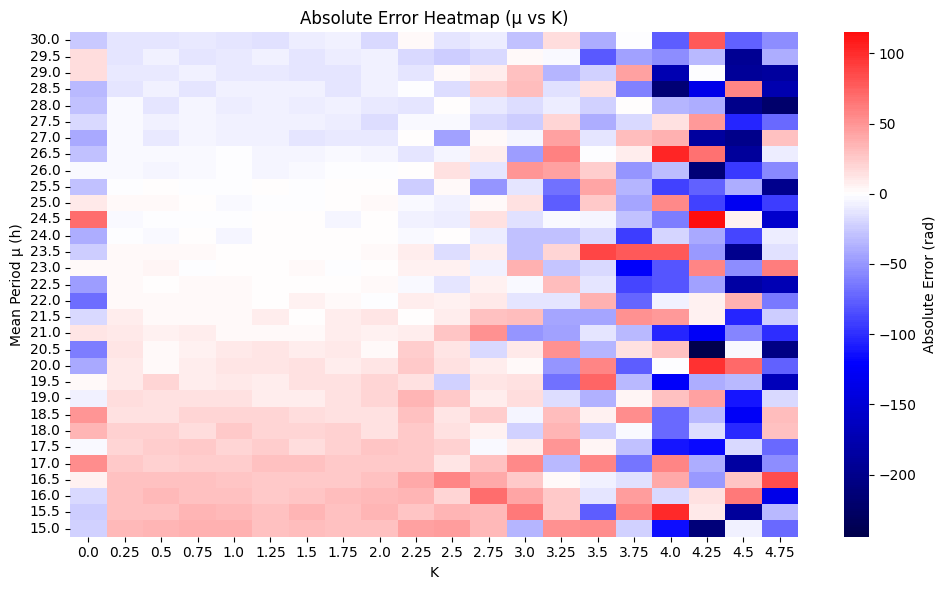

In [50]:
# --- Precompute circular alignment errors ---
align_errors = np.zeros((len(mean_period_values), len(K_values)))

for iMu, mu in enumerate(tqdm(mean_period_values, desc="sweeping μ", ncols=80)):
    for iK, K in enumerate(K_values):
        psi_traj = psi_all[iK, iMu, :]   # trajectory for this (K, μ)

        # circular error = wrapped difference between psi and true signal s
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
        abs_err=np.unwrap(psi_traj)-np.unwrap(s)
        align_errors[iMu, iK] = np.mean(abs_err[-240:])
# --- Plot heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(align_errors,
            xticklabels=np.round(K_values,2),
            yticklabels=np.round(mean_period_values,2),
            cmap="seismic",
            center=0,               # 0 = perfect alignment
            cbar_kws={"label": "Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Mean Period μ (h)")
plt.title("Absolute Error Heatmap (μ vs K)")
plt.tight_layout()
plt.show()


sweeping μ: 100%|██████████████████████████████| 31/31 [00:00<00:00, 312.14it/s]


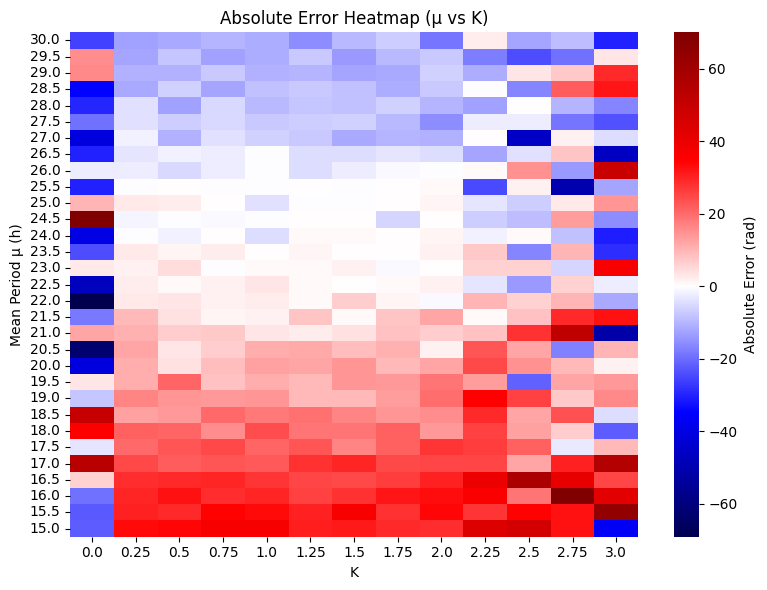

In [51]:
# --- Precompute circular alignment errors ---
align_errors = np.zeros((len(mean_period_values), len(np.arange(0, 3.25, 0.25))))

for iMu, mu in enumerate(tqdm(mean_period_values, desc="sweeping μ", ncols=80)):
    for iK, K in enumerate(np.arange(0, 3.25, 0.25)):
        psi_traj = psi_all[iK, iMu, :]   # trajectory for this (K, μ)

        # circular error = wrapped difference between psi and true signal s
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
        abs_err=np.unwrap(psi_traj)-np.unwrap(s)
        align_errors[iMu, iK] = np.mean(abs_err[-240:])
# --- Plot heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(align_errors,
            xticklabels=np.round(np.arange(0, 3.25, 0.25),2),
            yticklabels=np.round(mean_period_values,2),
            cmap="seismic",
            center=0,               # 0 = perfect alignment
            cbar_kws={"label": "Absolute Error (rad)"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Mean Period μ (h)")
plt.title("Absolute Error Heatmap (μ vs K)")
plt.tight_layout()
plt.show()

sweeping μ: 100%|███████████████████████████████| 31/31 [00:21<00:00,  1.42it/s]


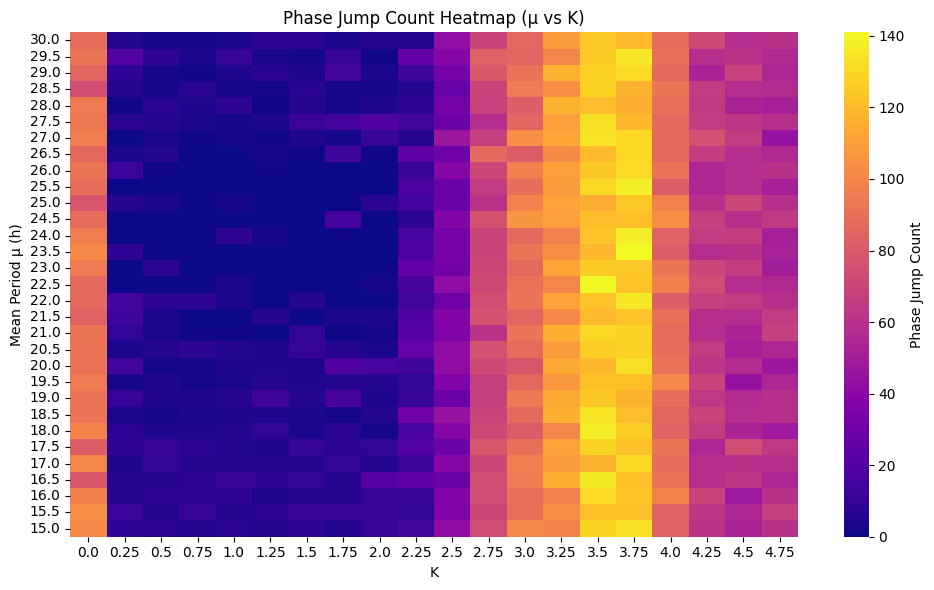

In [ ]:
# --- Precompute spike counts ---
spike_counts = np.zeros((len(mean_period_values), len(K_values)))

for iMu, mu in enumerate(tqdm(mean_period_values, desc="sweeping μ", ncols=80)):
    for iK, K in enumerate(K_values):
        psi_traj = psi_all[iK, iMu, :]   # trajectory for this (K, μ)

        # circular error trajectory (wrapped difference)
        circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))

        # count spikes
        _, _, spikes = count_phase_jumps(timesteps, circ_err_traj)
        spike_counts[iMu, iK] = len(spikes)

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(spike_counts,
            xticklabels=np.round(K_values,2),
            yticklabels=np.round(mean_period_values,2),
            cmap="plasma",
            cbar_kws={"label": "Phase Jump Count"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Mean Period μ (h)")
plt.title("Phase Jump Count Heatmap (μ vs K)")
plt.tight_layout()
plt.show()


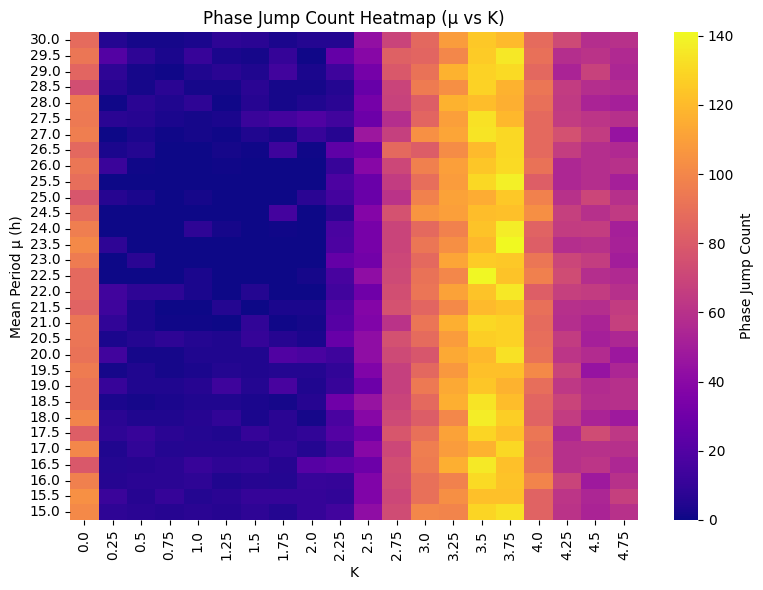

In [53]:
# --- Plot heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(spike_counts,
            xticklabels=np.round(K_values,2),
            yticklabels=np.round(mean_period_values,2),
            cmap="plasma",
            cbar_kws={"label": "Phase Jump Count"})
plt.gca().invert_yaxis()
plt.xlabel("K")
plt.ylabel("Mean Period μ (h)")
plt.title("Phase Jump Count Heatmap (μ vs K)")
plt.tight_layout()
plt.show()


### $\text{K x }\mu_{period}\text{ x }\sigma_{period}$

In [6]:
# === Parameter sweeps ===
K_values = np.arange(0, 5, 0.25)
mean_period_values = np.arange(15, 30.5, 0.5)   # example: 22.5 to 24.5 h
std_period_values  = np.arange(0, 5, 0.5)     # example: 0.1 to 1.0 h

# === Storage for raw results ===
# shape: (len(K), len(mean_period), len(std_period), duration)
psi_all  = np.zeros((len(K_values), len(mean_period_values), len(std_period_values), duration))
r_all    = np.zeros((len(K_values), len(mean_period_values), len(std_period_values), duration))
phase_history_all = np.zeros((len(K_values), len(mean_period_values), len(std_period_values), N, duration))

total_trials = len(K_values) * len(mean_period_values) * len(std_period_values)
trial = 0

# === Sweep ===
for iK, K in enumerate(K_values):
    for iMu, mu in enumerate(mean_period_values):
        for iSigma, sigma in enumerate(std_period_values):

            # natural frequencies depend on mean & std
            omega = np.random.normal(
                loc=2 * np.pi / mu,
                scale=(2 * np.pi / (mu**2)) * sigma,
                size=N
            )

            # noise parameters fixed here (or you can sweep later if needed)
            var_p = np.ones(N) * P_prime**2
            var_m = M**2

            kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
            xi = np.random.vonmises(mu=0, kappa=kappa_p_prime,
                                    size=(N, duration)) if P_prime > 0 else np.zeros((N, duration))

            var_prior = np.zeros((N, duration))
            var_post  = np.zeros((N, duration))
            m_hat     = np.zeros((N, duration))
            G         = np.zeros((N, duration))

            psi = np.zeros(duration)
            r   = np.zeros(duration)

            phases = np.random.vonmises(0, kappa=1, size=N)

            trial += 1
            desc = f"Trial {trial}/{total_trials} (K={K:.2f}, μ={mu:.2f}, σ={sigma:.2f})"
            for t in tqdm(range(duration), desc=desc, ncols=80):

                if t == 0:
                    var_prior[:, t] = init_cov + var_p
                else:
                    var_prior[:, t] = var_post[:, t-1] + var_p

                # order parameter
                order_param = np.mean(np.exp(1j * phases))
                r[t] = np.abs(order_param)
                psi[t] = np.angle(order_param)

                # observation update
                m_hat[:, t] = sigmoid(np.sin(phases + omega), theta=theta)
                H = alpha * m_hat[:, t] * (1 - m_hat[:, t]) * np.cos(phases + omega)
                sigma2_obs_eff = ((alpha * m_hat[:, t] * (1 - m_hat[:, t]))**2) * (M**2)
                G[:, t] = (H * var_prior[:, t]) / (H * var_prior[:, t] * H + sigma2_obs_eff + 1e-8)

                gap = (m[t] - m_hat[:, t])
                linear_correction = G[:, t] * gap
                var_post_linear = (1 - G[:, t] * H) * var_prior[:, t]

                # circular correction
                delta = psi[t] - phases
                delta = (delta + np.pi) % (2 * np.pi) - np.pi
                kappa_p = 1.0 / (var_post_linear + 1e-8)
                kappa_m = (N * r[t]) / (2 * (1 - r[t] + 1e-8))
                circ_correction = np.arctan2(kappa_m * np.sin(delta),
                                             kappa_p + kappa_m * np.cos(delta))

                # update phases
                if t < duration - 1:
                    phases += omega * dt + xi[:, t] + linear_correction + K * circ_correction
                    var_post[:, t] = 1.0 / (np.sqrt(kappa_p**2 + kappa_m**2 +
                                         2 * kappa_p * kappa_m * np.cos(delta)) + 1e-8)
                    phases = (phases + np.pi) % (2 * np.pi) - np.pi

                phase_history_all[iK, iMu, iSigma, :, t] = phases

            psi_all[iK, iMu, iSigma, :] = psi
            r_all[iK, iMu, iSigma, :] = r

# === At this point ===
# psi_all -> mean phase trajectory
# r_all -> coherence trajectory
# phase_history_all -> full per-oscillator phases


Trial 1/6200 (K=0.00, μ=15.00, σ=0.00): 100%|█| 2400/2400 [00:00<00:00, 11504.51
Trial 2/6200 (K=0.00, μ=15.00, σ=0.50): 100%|█| 2400/2400 [00:00<00:00, 10732.64
Trial 3/6200 (K=0.00, μ=15.00, σ=1.00): 100%|█| 2400/2400 [00:00<00:00, 10970.52
Trial 4/6200 (K=0.00, μ=15.00, σ=1.50): 100%|█| 2400/2400 [00:00<00:00, 11471.78
Trial 5/6200 (K=0.00, μ=15.00, σ=2.00): 100%|█| 2400/2400 [00:00<00:00, 11500.47
Trial 6/6200 (K=0.00, μ=15.00, σ=2.50): 100%|█| 2400/2400 [00:00<00:00, 10982.32
Trial 7/6200 (K=0.00, μ=15.00, σ=3.00): 100%|█| 2400/2400 [00:00<00:00, 10180.24
Trial 8/6200 (K=0.00, μ=15.00, σ=3.50): 100%|█| 2400/2400 [00:00<00:00, 11520.40
Trial 9/6200 (K=0.00, μ=15.00, σ=4.00): 100%|█| 2400/2400 [00:00<00:00, 11539.95
Trial 10/6200 (K=0.00, μ=15.00, σ=4.50): 100%|█| 2400/2400 [00:00<00:00, 11512.6
Trial 11/6200 (K=0.00, μ=15.50, σ=0.00): 100%|█| 2400/2400 [00:00<00:00, 11185.7
Trial 12/6200 (K=0.00, μ=15.50, σ=0.50): 100%|█| 2400/2400 [00:00<00:00, 11410.3
Trial 13/6200 (K=0.00, μ=15.

KeyboardInterrupt: 

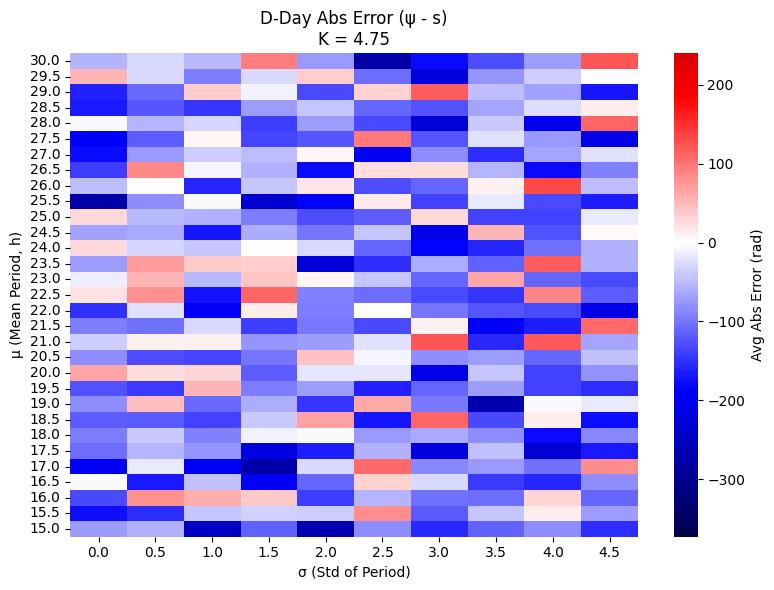

In [379]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Precompute global min/max for constant scaling ---
all_vals = []
for iK in range(len(K_values)):
    for iMu in range(len(mean_period_values)):
        for iSigma in range(len(std_period_values)):
            psi_traj = psi_all[iK, iMu, iSigma, :]
            abs_err_traj = np.unwrap(psi_traj) - np.unwrap(s)
            val = np.mean(abs_err_traj[-480:])   # steady-state half
            all_vals.append(val)

vmin = min(all_vals)
vmax = max(all_vals)

# --- Animate over K instead of σ ---
for iK, K in enumerate(K_values):

    alignment_grid = np.zeros((len(mean_period_values), len(std_period_values)))
    for iMu, mu in enumerate(mean_period_values):
        for iSigma, sigma in enumerate(std_period_values):
            psi_traj = psi_all[iK, iMu, iSigma, :]
            abs_err_traj = np.unwrap(psi_traj) - np.unwrap(s)
            alignment_grid[iMu, iSigma] = np.mean(abs_err_traj[-480:])

    plt.figure(figsize=(8,6))
    ax = sns.heatmap(alignment_grid,
                     xticklabels=np.round(std_period_values, 2),
                     yticklabels=np.round(mean_period_values, 2),
                     cmap="seismic",
                     center=0,
                     vmin=vmin, vmax=vmax,
                     cbar_kws={"label": "Avg Abs Error (rad)"})
    plt.gca().invert_yaxis()
    plt.xlabel("σ (Std of Period)")
    plt.ylabel("μ (Mean Period, h)")
    plt.title(f"D-Day Abs Error (ψ - s)\nK = {K:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)

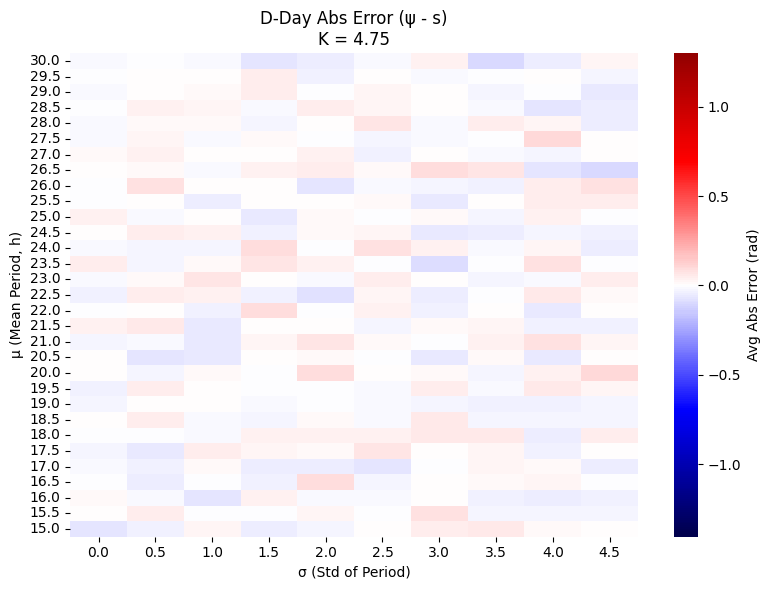

In [ ]:
from IPython.display import clear_output
import time
import seaborn as sns

# --- Precompute global min/max for constant scaling ---
all_vals = []
for iK in range(len(K_values)):
    for iMu in range(len(mean_period_values)):
        for iSigma in range(len(std_period_values)):
            psi_traj = psi_all[iK, iMu, iSigma, :]
            circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
            val = np.mean(circ_err_traj[480:])   # steady-state half
            all_vals.append(val)

vmin = min(all_vals)
vmax = max(all_vals)

# --- Animate over K instead of σ ---
for iK, K in enumerate(K_values):

    alignment_grid = np.zeros((len(mean_period_values), len(std_period_values)))
    for iMu, mu in enumerate(mean_period_values):
        for iSigma, sigma in enumerate(std_period_values):
            psi_traj = psi_all[iK, iMu, iSigma, :]
            circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
            alignment_grid[iMu, iSigma] = np.mean(circ_err_traj[480:])

    plt.figure(figsize=(8,6))
    ax = sns.heatmap(alignment_grid,
                     xticklabels=np.round(std_period_values, 2),
                     yticklabels=np.round(mean_period_values, 2),
                     cmap="seismic",
                     center=0,
                     vmin=vmin, vmax=vmax,
                     cbar_kws={"label": "Avg Abs Error (rad)"})
    plt.gca().invert_yaxis()
    plt.xlabel("σ (Std of Period)")
    plt.ylabel("μ (Mean Period, h)")
    plt.title(f"mean Cir Error (ψ - s)\nK = {K:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)

In [381]:
from IPython.display import clear_output
import time
import seaborn as sns
from tqdm import tqdm

# --- Precompute spike counts for all configs ---
spike_counts = np.zeros((len(K_values), len(mean_period_values), len(std_period_values)))

for iK, K in enumerate(tqdm(K_values, desc="K sweep")):
    for iMu, mu in enumerate(mean_period_values):
        for iSigma, sigma in enumerate(std_period_values):
            psi_traj = psi_all[iK, iMu, iSigma, :]
            circ_err_traj = np.angle(np.exp(1j * (psi_traj - s)))
            _, _, spikes = count_phase_jumps(timesteps, circ_err_traj)
            spike_counts[iK, iMu, iSigma] = len(spikes)

K sweep: 100%|██████████| 20/20 [03:55<00:00, 11.77s/it]


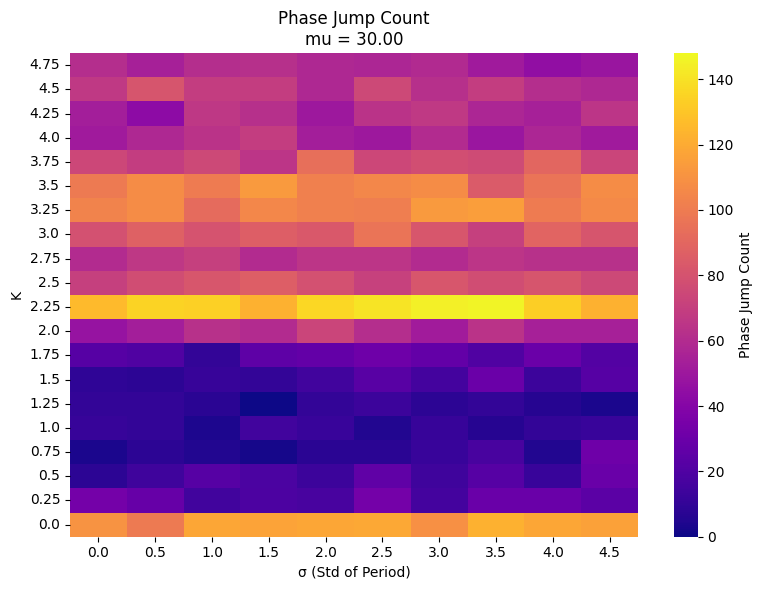

In [ ]:
# --- Fix color range globally ---
vmin = np.min(spike_counts)
vmax = np.max(spike_counts)

# --- Animate over K ---
for iMu, mu in enumerate(mean_period_values):

    plt.figure(figsize=(8,6))
    sns.heatmap(spike_counts[:,iMu,:],
                xticklabels=std_period_values,
                yticklabels=np.round(K_values,2),
                cmap="plasma",
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Phase Jump Count"})
    plt.gca().invert_yaxis()
    plt.xlabel("σ (Std of Period)")
    plt.ylabel("K")
    plt.title(f"Phase Jump Count\nmu = {mu :.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)

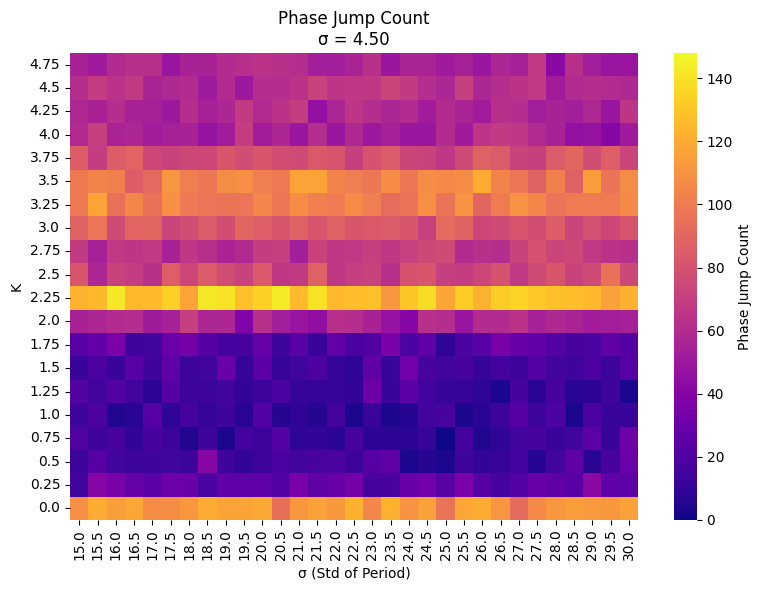

In [390]:
# --- Fix color range globally ---
vmin = np.min(spike_counts)
vmax = np.max(spike_counts)

# --- Animate over K ---
for iSigma, sigma in enumerate(std_period_values):

    plt.figure(figsize=(8,6))
    sns.heatmap(spike_counts[:,:,iSigma],
                xticklabels=mean_period_values,
                yticklabels=np.round(K_values,2),
                cmap="plasma",
                vmin=vmin, vmax=vmax,
                cbar_kws={"label": "Phase Jump Count"})
    plt.gca().invert_yaxis()
    plt.xlabel("σ (Std of Period)")
    plt.ylabel("K")
    plt.title(f"Phase Jump Count\nσ = {sigma:.2f}")
    plt.tight_layout()
    plt.show()

    time.sleep(1)
    clear_output(wait=True)